## MORE COMM DYN

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
class MRgnODE(nn.Module):
    def __init__(self, N=4, input_dim=2, tau=0.01, num_regions=2, output_head=None):
        super().__init__()
        self.N = N
        self.tau = tau
        self.num_regions = num_regions
        self.region_dim = N // num_regions
        
        hidden_dim = 64
        
        # Each region processes its own state + its own input
        region_input_dim = self.region_dim + input_dim
        
        self.flow_net = nn.Sequential(
            nn.Linear(region_input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, self.region_dim)
        )
        
        self.gate_net = nn.Sequential(
            nn.Linear(region_input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, self.region_dim),
            nn.Sigmoid()
        )
        
        # Communication between regions
        self.comm_weights = nn.Parameter(torch.randn(num_regions, self.region_dim, self.region_dim) * 0.1)
        self.comm_gates = nn.Sequential(
            nn.Linear(2 * self.region_dim, 32),
            nn.Tanh(), 
            nn.Linear(32, self.region_dim),
            nn.Sigmoid()
        )
        
        # Optional output transformation
        self.output_head = None
        self.output_head_type = output_head
        if output_head == 'velocity':
            self.output_head = nn.Linear(self.region_dim, 1)  # Single velocity output per region
        elif output_head == 'position':
            self.output_head = nn.Linear(self.region_dim, 2)  # 2D position output per region
        elif output_head == 'custom':
            self.output_head = nn.Linear(self.region_dim, self.region_dim)  # Same size transformation
        # If None, no output head - raw hidden states used (for flip-flop tasks)
        
        self.apply(self._init_weights)
        self.to(device)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight, gain=0.5)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        
    def compute_communication(self, h):
        batch_size = h.shape[0]
        h_regions = h.view(batch_size, self.num_regions, self.region_dim)
        comm_input = torch.zeros_like(h_regions)
        
        for i in range(self.num_regions):
            for j in range(self.num_regions):
                if i != j:
                    h_concat = torch.cat([h_regions[:, i], h_regions[:, j]], dim=-1)
                    gate = self.comm_gates(h_concat)
                    message = torch.matmul(h_regions[:, j], self.comm_weights[i].T)
                    comm_input[:, i] += gate * message
                    
        return comm_input.view(batch_size, -1)
        
    def get_outputs(self, h):
        """
        Apply output head if present, otherwise return raw hidden states
        
        Returns:
            For output_head=None: [batch, regions, region_dim] 
            For output_head='velocity': [batch, regions, 1]
            For output_head='position': [batch, regions, 2]
            For output_head='custom': [batch, regions, region_dim]
        """
        h_regions = h.view(-1, self.num_regions, self.region_dim)
        
        if self.output_head is None:
            # No transformation - return raw hidden states (flip-flop task format)
            return h_regions
        
        # Apply output head to each region
        outputs = []
        for i in range(self.num_regions):
            region_output = self.output_head(h_regions[:, i])
            outputs.append(region_output)
        
        return torch.stack(outputs, dim=1)  # [batch, regions, output_dim]
        
    def forward(self, h, x):
        """
        h: [batch, N] where N = num_regions * region_dim
        x: [batch, num_regions, input_dim] - region-specific inputs
        """
        batch_size = h.shape[0]
        h_regions = h.view(batch_size, self.num_regions, self.region_dim)
        
        # Compute communication
        comm = self.compute_communication(h)
        comm_regions = comm.view(batch_size, self.num_regions, self.region_dim)
        
        # Process each region with its own state + its own input
        flow_regions = []
        gate_regions = []
        
        for region_idx in range(self.num_regions):
            h_region = h_regions[:, region_idx, :]  # [batch, region_dim]
            x_region = x[:, region_idx, :]  # [batch, input_dim] - this region's input
            
            hx_region = torch.cat([h_region, x_region], dim=-1)
            
            flow_region = self.flow_net(hx_region)
            gate_region = self.gate_net(hx_region)
            
            flow_regions.append(flow_region)
            gate_regions.append(gate_region)
        
        flow = torch.stack(flow_regions, dim=1).view(batch_size, -1)
        gate = torch.stack(gate_regions, dim=1).view(batch_size, -1)
        
        # Add communication to flow
        flow = flow + comm
        h_dot = gate * (-h + flow) / self.tau
        
        return h_dot, comm

def euler_step(model, h, x, dt):
    """Single Euler step for ODE integration"""
    h_dot, comm = model(h, x)
    return h + dt * h_dot, comm

def train_mr_gnode(model, train_data, n_epochs=100, lr=1e-3, dt=0.01, 
                   batch_size=32, comm_penalty_lam=0.01, custom_loss_fn=None,
                   return_trajectories=False):
    """
    Train Multi-Region gnODE - now supports custom loss functions and output heads
    
    Args:
        model: MRgnODE model to train
        train_data: Training data in format [(inputs, targets), ...]
        n_epochs: Number of training epochs
        lr: Learning rate
        dt: Integration timestep
        batch_size: Batch size for training
        comm_penalty_lam: Communication penalty coefficient
        custom_loss_fn: Optional custom loss function(outputs, targets, inputs) -> loss
        return_trajectories: If True, return sample trajectories for analysis
        
    Returns:
        losses: List of training losses per epoch
        trajectories: (Optional) Sample trajectories if return_trajectories=True
    """
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr*5, epochs=n_epochs, 
                                            steps_per_epoch=len(train_data)//batch_size + 1)
    model.train()
    
    inputs_batched, targets_batched = create_batched_data(train_data, batch_size)
    
    losses = []
    sample_trajectories = []
    
    for epoch in tqdm(range(n_epochs), desc="Training MR-gnODE"):
        total_loss = 0
        epoch_trajectories = []
        
        for batch_idx, (batch_inputs, batch_targets) in enumerate(zip(inputs_batched, targets_batched)):
            optimizer.zero_grad()
            
            # batch_inputs: [batch, time, regions, channels]
            # batch_targets: [batch, time, regions, output_dim]
            batch_size_actual, seq_len, n_regions, input_dim = batch_inputs.shape
            
            h = torch.zeros(batch_size_actual, model.N, device=device)
            outputs = []
            hidden_states = []  # For trajectory analysis
            
            total_comm_penalty = 0
            for t in range(seq_len):
                x_t = batch_inputs[:, t]  # [batch, regions, channels]
                h, comm = euler_step(model, h, x_t, dt)
                total_comm_penalty += comm_penalty_lam * torch.norm(comm)
                
                # Get outputs using the model's output head (if any)
                step_output = model.get_outputs(h)
                outputs.append(step_output)
                
                # Store hidden states for trajectory analysis
                if return_trajectories and batch_idx == 0:  # Only first batch
                    hidden_states.append(h.detach().cpu())
            
            outputs = torch.stack(outputs, dim=1)  # [batch, time, regions, output_dim]
            
            # Compute loss using custom function if provided, otherwise default MSE
            if custom_loss_fn is not None:
                mse_loss = custom_loss_fn(outputs, batch_targets, batch_inputs)
            else:
                mse_loss = nn.MSELoss()(outputs, batch_targets)
            
            total_loss_val = mse_loss + total_comm_penalty
            
            total_loss_val.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            total_loss += total_loss_val.item()
            
            # Store trajectory for first batch of first few epochs
            if return_trajectories and batch_idx == 0 and epoch % max(1, n_epochs // 10) == 0:
                epoch_trajectories.append({
                    'epoch': epoch,
                    'hidden_states': torch.stack(hidden_states, dim=1),  # [batch, time, N]
                    'outputs': outputs.detach().cpu(),
                    'targets': batch_targets.cpu(),
                    'inputs': batch_inputs.cpu()
                })
        
        avg_loss = total_loss / len(inputs_batched)
        losses.append(avg_loss)
        
        if epoch_trajectories:
            sample_trajectories.extend(epoch_trajectories)
        
        if epoch % (n_epochs // 10) == 0:
            print(f"Epoch {epoch}, Loss: {avg_loss:.6f}")
    
    model.eval()
    
    if return_trajectories:
        return losses, sample_trajectories
    else:
        return losses

def create_batched_data(train_data, batch_size=32):
    """Convert to batched tensors"""
    inputs_list, targets_list = zip(*train_data)
    
    inputs_batched = []
    targets_batched = []
    
    for i in range(0, len(inputs_list), batch_size):
        batch_inputs = torch.stack([torch.FloatTensor(inp) for inp in inputs_list[i:i+batch_size]]).to(device)
        batch_targets = torch.stack([torch.FloatTensor(targ) for targ in targets_list[i:i+batch_size]]).to(device)
        inputs_batched.append(batch_inputs)
        targets_batched.append(batch_targets)
    
    return inputs_batched, targets_batched


def generate_mr_flip_flop_data(task_type, n_trials=500, trial_length=100, n_regions=2):
    """
    Generate multi-region flip-flop data that REQUIRES communication between regions
    
    Args:
        task_type: 'sum', 'xor', or 'max'
        
    Communication structure:
    - Region 1 receives pulses ONLY in channel 1 (maintains current_ch1)
    - Region 2 receives pulses ONLY in channel 2 (maintains current_ch2)  
    - BOTH regions must output the result of the specified operation
    - Forces communication since each region needs the other's information
    """
    data = []
    
    for trial_idx in range(n_trials):
        # Initialize: [time, regions, channels]
        inputs = np.zeros((trial_length, n_regions, 2))
        targets = np.zeros((trial_length, n_regions, 2))
        
        # Generate independent pulse times for each channel
        n_pulses_ch1 = np.random.poisson(10)
        n_pulses_ch2 = np.random.poisson(10)
        
        pulse_times_ch1 = np.random.choice(trial_length, min(n_pulses_ch1, trial_length), replace=False)
        pulse_times_ch2 = np.random.choice(trial_length, min(n_pulses_ch2, trial_length), replace=False)
        
        # Track current state of each channel
        current_ch1 = 0.0
        current_ch2 = 0.0
        
        for t in range(trial_length):
            # Channel 1 pulses - ONLY Region 1 receives these
            if t in pulse_times_ch1:
                current_ch1 = np.random.uniform(-1, 1)
                inputs[t, 0, 0] = current_ch1  # Region 1, Channel 1
                
            # Channel 2 pulses - ONLY Region 2 receives these  
            if t in pulse_times_ch2:
                current_ch2 = np.random.uniform(-1, 1)
                inputs[t, 1, 1] = current_ch2  # Region 2, Channel 2
            
            # Compute target based on task type
            if task_type == 'sum':
                target_value = current_ch1 + current_ch2
                
            elif task_type == 'xor':
                # XOR of signs: +1 if different signs, -1 if same signs
                sign1 = 1 if current_ch1 >= 0 else -1
                sign2 = 1 if current_ch2 >= 0 else -1
                target_value = 1.0 if sign1 != sign2 else -1.0
                
            elif task_type == 'max':
                target_value = max(abs(current_ch1), abs(current_ch2))
                # Preserve sign of the max absolute value
                if abs(current_ch1) > abs(current_ch2):
                    target_value = current_ch1
                else:
                    target_value = current_ch2
                    
            else:
                raise ValueError(f"Unknown task_type: {task_type}")
            
            # BOTH regions must output the computed value
            # This forces communication since each region only has partial information
            targets[t, 0, 0] = target_value  # Region 1 output
            targets[t, 1, 1] = target_value  # Region 2 output
        
        data.append((inputs, targets))
    
    return data

def create_batched_data(train_data, batch_size=32):
    """Convert to batched tensors"""
    inputs_list, targets_list = zip(*train_data)
    
    inputs_batched = []
    targets_batched = []
    
    for i in range(0, len(inputs_list), batch_size):
        batch_inputs = torch.stack([torch.FloatTensor(inp) for inp in inputs_list[i:i+batch_size]]).to(device)
        batch_targets = torch.stack([torch.FloatTensor(targ) for targ in targets_list[i:i+batch_size]]).to(device)
        inputs_batched.append(batch_inputs)
        targets_batched.append(batch_targets)
    
    return inputs_batched, targets_batched



def generate_mr_flip_flop_data_og(task_type, n_trials=500, trial_length=100, n_channels=2, n_regions=1):
    """
    Generate data for flip-flop tasks with consistent multi-region support
    Always generates [time, regions, channels] shape regardless of n_regions
    
    Args:
        task_type: 'fixed', 'square', 'rectangle', 'disk'
        n_trials: Number of trials to generate
        trial_length: Length of each trial in time steps
        n_channels: Number of channels (typically 2)
        n_regions: Number of regions (1 for single-region, >1 for multi-region)
    
    Returns:
        List of (inputs, targets) tuples where:
        - inputs: [time, regions, channels] 
        - targets: [time, regions, channels]
    """
    data = []
    
    for trial_idx in range(n_trials):
        # Always generate 3D data: [time, regions, channels]
        inputs = np.zeros((trial_length, n_regions, n_channels))
        targets = np.zeros((trial_length, n_regions, n_channels))
        
        if n_regions == 1:
            # Single region case - treat as region 0
            n_pulses = np.random.poisson(6)
            pulse_times = np.random.choice(trial_length, min(n_pulses, trial_length), replace=False)
            current_output = np.zeros(n_channels)
            
            for t in range(trial_length):
                if t in pulse_times:
                    if task_type == 'disk':
                        radius = np.random.uniform(1, 2)
                        angle = np.random.uniform(0, 2*np.pi)
                        pulse_vals = [radius * np.cos(angle), radius * np.sin(angle)]
                        inputs[t, 0] = pulse_vals  # Region 0
                        current_output = pulse_vals
                    else:
                        channel = np.random.randint(n_channels)
                        if task_type == 'fixed':
                            pulse_val = np.random.choice([-1, 1])
                        elif task_type == 'square':
                            pulse_val = np.random.uniform(-1, 1)
                        elif task_type == 'rectangle':
                            pulse_val = np.random.uniform(-2, 2) if channel == 0 else np.random.uniform(-1, 1)
                        else:
                            raise ValueError(f"Unknown task_type: {task_type}")
                        
                        inputs[t, 0, channel] = pulse_val  # Region 0, specified channel
                        current_output[channel] = pulse_val
                
                targets[t, 0] = current_output.copy()  # Region 0 output
                
        else:
            # Multi-region case - each region gets independent data
            for region in range(n_regions):
                n_pulses = np.random.poisson(3)  # Fewer pulses per region
                pulse_times = np.random.choice(trial_length, min(n_pulses, trial_length), replace=False)
                current_output = np.zeros(n_channels)
                
                for t in range(trial_length):
                    if t in pulse_times:
                        if task_type == 'disk':
                            radius = np.random.uniform(1, 2)
                            angle = np.random.uniform(0, 2*np.pi)
                            pulse_vals = [radius * np.cos(angle), radius * np.sin(angle)]
                            inputs[t, region] = pulse_vals
                            current_output = pulse_vals
                        else:
                            channel = np.random.randint(n_channels)
                            if task_type == 'fixed':
                                pulse_val = np.random.choice([-1, 1])
                            elif task_type == 'square':
                                pulse_val = np.random.uniform(-1, 1)
                            elif task_type == 'rectangle':
                                pulse_val = np.random.uniform(-2, 2) if channel == 0 else np.random.uniform(-1, 1)
                            else:
                                raise ValueError(f"Unknown task_type: {task_type}")
                            
                            inputs[t, region, channel] = pulse_val
                            current_output[channel] = pulse_val
                    
                    targets[t, region] = current_output.copy()
        
        data.append((inputs, targets))
    
    return data

def create_batched_data(train_data, batch_size=32, num_regions=1):
    """Convert list of sequences to batched tensors - efficient like original"""
    inputs_list, targets_list = zip(*train_data)
    
    inputs_batched = []
    targets_batched = []
    
    for i in range(0, len(inputs_list), batch_size):
        batch_inputs = torch.stack([torch.FloatTensor(inp) for inp in inputs_list[i:i+batch_size]]).to(device)
        batch_targets = torch.stack([torch.FloatTensor(targ) for targ in targets_list[i:i+batch_size]]).to(device)
        inputs_batched.append(batch_inputs)
        targets_batched.append(batch_targets)
    
    return inputs_batched, targets_batched



def plot_flow_field(model, task_type='fixed', xlim=(-2.5, 2.5), ylim=(-2.5, 2.5), grid_size=15, region_idx=None):
    """
    Plot flow field for single or multi-region gnODE models
    Updated to work with models that return (h_dot, comm) from forward pass
    
    Args:
        model: Trained model (single or multi-region) 
        task_type: Type of task for title
        xlim, ylim: Plot bounds
        grid_size: Resolution of flow field
        region_idx: Which region to plot (None = all regions, int = specific region)
    """
    model.eval()
    
    # Create grid
    x = np.linspace(xlim[0], xlim[1], grid_size)
    y = np.linspace(ylim[0], ylim[1], grid_size)
    X, Y = np.meshgrid(x, y)
    
    # Check if model has num_regions attribute (MRgnODE vs standard gnODE)
    if hasattr(model, 'num_regions') and model.num_regions > 1:
        # Multi-region model
        if region_idx is not None:
            # Plot specific region
            U, V = np.zeros_like(X), np.zeros_like(Y)
            
            with torch.no_grad():
                for i in range(grid_size):
                    for j in range(grid_size):
                        # Initialize with zeros
                        h = torch.zeros(1, model.N, device=device)
                        # Set only the target region's state
                        h[0, region_idx*model.region_dim:(region_idx+1)*model.region_dim] = torch.tensor([X[i,j], Y[i,j]])
                        
                        # FIXED: Create proper 3D input [batch, regions, channels]
                        x_input = torch.zeros(1, model.num_regions, 2, device=device)
                        
                        h_dot, comm = model(h, x_input)
                        # Extract flow for target region only
                        U[i,j] = h_dot[0, region_idx*model.region_dim].cpu().item()
                        V[i,j] = h_dot[0, region_idx*model.region_dim + 1].cpu().item()
            
            plt.figure(figsize=(8, 8))
            plt.quiver(X, Y, U, V, alpha=0.6, scale=50, width=0.002)
            plt.xlim(xlim)
            plt.ylim(ylim)
            plt.xlabel('Channel 1')
            plt.ylabel('Channel 2')
            plt.title(f'MR-gnODE Flow Field - {task_type.capitalize()} Task (Region {region_idx})')
            plt.grid(True, alpha=0.3)
            plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
            plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
            plt.show()
            
        else:
            # Plot all regions in subplots
            fig, axes = plt.subplots(1, model.num_regions, figsize=(8*model.num_regions, 8))
            if model.num_regions == 1:
                axes = [axes]  # Make it iterable
            
            for region_idx in range(model.num_regions):
                U, V = np.zeros_like(X), np.zeros_like(Y)
                
                with torch.no_grad():
                    for i in range(grid_size):
                        for j in range(grid_size):
                            h = torch.zeros(1, model.N, device=device)
                            h[0, region_idx*model.region_dim:(region_idx+1)*model.region_dim] = torch.tensor([X[i,j], Y[i,j]])
                            
                            # FIXED: Create proper 3D input [batch, regions, channels]
                            x_input = torch.zeros(1, model.num_regions, 2, device=device)
                            
                            h_dot, comm = model(h, x_input)
                            U[i,j] = h_dot[0, region_idx*model.region_dim].cpu().item()
                            V[i,j] = h_dot[0, region_idx*model.region_dim + 1].cpu().item()
                
                axes[region_idx].quiver(X, Y, U, V, alpha=0.6, scale=50, width=0.002)
                axes[region_idx].set_xlim(xlim)
                axes[region_idx].set_ylim(ylim)
                axes[region_idx].set_xlabel('Channel 1')
                axes[region_idx].set_ylabel('Channel 2')
                axes[region_idx].set_title(f'Region {region_idx}')
                axes[region_idx].grid(True, alpha=0.3)
                axes[region_idx].axhline(y=0, color='k', linestyle='-', alpha=0.3)
                axes[region_idx].axvline(x=0, color='k', linestyle='-', alpha=0.3)
                axes[region_idx].set_aspect('equal')
            
            plt.suptitle(f'MR-gnODE Flow Fields - {task_type.capitalize()} Task')
            plt.tight_layout()
            plt.show()
    
    else:
        # Single region model or standard gnODE
        U, V = np.zeros_like(X), np.zeros_like(Y)
        
        with torch.no_grad():
            for i in range(grid_size):
                for j in range(grid_size):
                    h = torch.tensor([[X[i,j], Y[i,j]]], dtype=torch.float32, device=device)
                    
                    # Check if model expects 3D input (MRgnODE with 1 region) or 2D input (standard gnODE)
                    if hasattr(model, 'num_regions'):
                        # MRgnODE with 1 region - needs 3D input
                        x_input = torch.zeros(1, 1, 2, device=device)
                    else:
                        # Standard gnODE - needs 2D input
                        x_input = torch.zeros(1, 2, device=device)
                    
                    h_dot, comm = model(h, x_input)
                    U[i,j] = h_dot[0,0].cpu().item()
                    V[i,j] = h_dot[0,1].cpu().item()
        
        # Plot single region
        plt.figure(figsize=(8, 8))
        plt.quiver(X, Y, U, V, alpha=0.6, scale=50, width=0.002)
        plt.xlim(xlim)
        plt.ylim(ylim)
        plt.xlabel('Channel 1')
        plt.ylabel('Channel 2')
        plt.title(f'gnODE Flow Field - {task_type.capitalize()} Task')
        plt.grid(True, alpha=0.3)
        plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
        plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
        plt.show()



def analyze_communication(model, test_data, dt=0.01, device='cpu'):
    """
    Analyze communication patterns in trained multi-region gnODE
    Returns comprehensive analysis data for visualization and summary functions
    """
    model.eval()
    
    # Storage for analysis
    comm_magnitudes = []
    comm_matrices = []
    region_activities = []
    gate_activities = []
    
    with torch.no_grad():
        for trial_idx, (inputs, targets) in enumerate(test_data):
            inputs = torch.FloatTensor(inputs).unsqueeze(0).to(device)
            seq_len = inputs.shape[1]
            
            # Initialize
            h = torch.zeros(1, model.N, device=device)
            
            trial_comm_mag = []
            trial_comm_matrices = []
            trial_region_activity = []
            trial_gate_activity = []
            
            for t in range(seq_len):
                x_t = inputs[:, t]  # [1, regions, channels]
                
                # Track individual region activities before step
                h_regions = h.view(1, model.num_regions, model.region_dim)
                region_activity = torch.norm(h_regions, dim=-1).squeeze().cpu().numpy()
                if model.num_regions == 1:
                    region_activity = np.array([region_activity])  # Make it 1D array
                trial_region_activity.append(region_activity)
                
                # Compute detailed communication matrix
                comm_matrix = np.zeros((model.num_regions, model.num_regions))
                gates_this_step = []
                
                if model.num_regions > 1:
                    for i in range(model.num_regions):
                        for j in range(model.num_regions):
                            if i != j:
                                # Get communication from j to i
                                h_concat = torch.cat([h_regions[:, i], h_regions[:, j]], dim=-1)
                                gate = model.comm_gates(h_concat)
                                message = torch.matmul(h_regions[:, j], model.comm_weights[i].T)
                                comm_strength = torch.norm(gate * message).item()
                                comm_matrix[i, j] = comm_strength
                                gates_this_step.append(torch.mean(gate).item())
                else:
                    # Single region - no actual communication
                    gates_this_step = [0.0]
                
                trial_comm_matrices.append(comm_matrix)
                trial_gate_activity.append(np.mean(gates_this_step) if gates_this_step else 0)
                
                # Forward step
                h, comm = euler_step(model, h, x_t, dt)
                
                # Total communication magnitude
                comm_magnitude = torch.norm(comm).item()
                trial_comm_mag.append(comm_magnitude)
            
            comm_magnitudes.append(trial_comm_mag)
            comm_matrices.append(trial_comm_matrices)
            region_activities.append(trial_region_activity)
            gate_activities.append(trial_gate_activity)
    
    return {
        'comm_magnitudes': np.array(comm_magnitudes),
        'comm_matrices': np.array(comm_matrices),
        'region_activities': np.array(region_activities),
        'gate_activities': np.array(gate_activities)
    }

def plot_communication_analysis(analysis_results, model):
    """
    Create comprehensive communication visualizations
    Updated to handle cases where some arrays might be empty or single-region
    """
    comm_mag = analysis_results['comm_magnitudes']
    comm_matrices = analysis_results['comm_matrices']
    region_activities = analysis_results['region_activities']
    gate_activities = analysis_results['gate_activities']
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Communication magnitude over time
    axes[0, 0].plot(comm_mag.T, alpha=0.7)
    axes[0, 0].plot(np.mean(comm_mag, axis=0), 'k-', linewidth=3, label='Average')
    axes[0, 0].set_title('Communication Magnitude Over Time')
    axes[0, 0].set_xlabel('Time Step')
    axes[0, 0].set_ylabel('||Communication||')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Average communication matrix (region-to-region)
    if model.num_regions > 1 and comm_matrices.size > 0:
        avg_comm_matrix = np.mean(np.mean(comm_matrices, axis=0), axis=0)
        im = axes[0, 1].imshow(avg_comm_matrix, cmap='viridis', interpolation='nearest')
        axes[0, 1].set_title('Average Communication Matrix\n(Region j → Region i)')
        axes[0, 1].set_xlabel('Source Region j')
        axes[0, 1].set_ylabel('Target Region i')
        
        # Add text annotations
        for i in range(model.num_regions):
            for j in range(model.num_regions):
                text = axes[0, 1].text(j, i, f'{avg_comm_matrix[i, j]:.3f}',
                                     ha="center", va="center", color="white")
        
        plt.colorbar(im, ax=axes[0, 1])
    else:
        axes[0, 1].text(0.5, 0.5, 'Single Region\n(No Inter-Region Communication)', 
                       ha='center', va='center', transform=axes[0, 1].transAxes)
        axes[0, 1].set_title('Communication Matrix')
    
    # 3. Region activity levels
    if region_activities.size > 0:
        avg_region_activity = np.mean(region_activities, axis=0)
        for i in range(model.num_regions):
            axes[0, 2].plot(avg_region_activity[:, i], label=f'Region {i}', linewidth=2)
        axes[0, 2].set_title('Region Activity Levels')
        axes[0, 2].set_xlabel('Time Step')
        axes[0, 2].set_ylabel('||Region State||')
        axes[0, 2].legend()
        axes[0, 2].grid(True, alpha=0.3)
    
    # 4. Gate activity over time
    if len(gate_activities) > 0 and np.array(gate_activities).size > 0:
        axes[1, 0].plot(np.array(gate_activities).T, alpha=0.7)
        axes[1, 0].plot(np.mean(gate_activities, axis=0), 'k-', linewidth=3, label='Average')
        axes[1, 0].set_title('Communication Gate Activity')
        axes[1, 0].set_xlabel('Time Step')
        axes[1, 0].set_ylabel('Average Gate Activation')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
    else:
        axes[1, 0].text(0.5, 0.5, 'No Gate Activity\n(Single Region)', 
                       ha='center', va='center', transform=axes[1, 0].transAxes)
        axes[1, 0].set_title('Communication Gate Activity')
    
    # 5. Communication distribution
    all_comm = comm_mag.flatten()
    axes[1, 1].hist(all_comm, bins=50, alpha=0.7, density=True)
    axes[1, 1].axvline(np.mean(all_comm), color='red', linestyle='--', 
                      label=f'Mean: {np.mean(all_comm):.4f}')
    axes[1, 1].set_title('Communication Magnitude Distribution')
    axes[1, 1].set_xlabel('||Communication||')
    axes[1, 1].set_ylabel('Density')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # 6. Communication efficiency
    if region_activities.size > 0:
        region_total_activity = np.mean(np.sum(region_activities, axis=-1), axis=0)
        comm_total = np.mean(comm_mag, axis=0)
        
        axes[1, 2].scatter(region_total_activity, comm_total, alpha=0.6)
        axes[1, 2].set_title('Communication vs Total Activity')
        axes[1, 2].set_xlabel('Total Region Activity')
        axes[1, 2].set_ylabel('Communication Magnitude')
        
        # Add correlation coefficient
        if len(region_total_activity) > 1 and len(comm_total) > 1:
            corr = np.corrcoef(region_total_activity, comm_total)[0, 1]
            axes[1, 2].text(0.05, 0.95, f'Correlation: {corr:.3f}', 
                           transform=axes[1, 2].transAxes, bbox=dict(boxstyle='round', facecolor='white'))
        axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def communication_summary(analysis_results, model):
    """
    Print summary statistics about communication usage
    Updated to handle single and multi-region cases
    """
    comm_mag = analysis_results['comm_magnitudes']
    comm_matrices = analysis_results['comm_matrices']
    gate_activities = analysis_results['gate_activities']
    
    print("=== COMMUNICATION USAGE SUMMARY ===")
    print(f"Model: {model.num_regions} regions, {model.region_dim} dimensions each")
    
    if hasattr(model, 'comm_weights'):
        print(f"Total parameters in comm_weights: {model.comm_weights.numel()}")
    print()
    
    print("Communication Statistics:")
    print(f"  Mean communication magnitude: {np.mean(comm_mag):.6f}")
    print(f"  Max communication magnitude: {np.max(comm_mag):.6f}")
    print(f"  Std communication magnitude: {np.std(comm_mag):.6f}")
    print()
    
    if model.num_regions > 1:
        print("Gate Activity:")
        print(f"  Mean gate activation: {np.mean(gate_activities):.6f}")
        print(f"  Max gate activation: {np.max(gate_activities):.6f}")
        print(f"  % time gates active (>0.1): {np.mean(np.array(gate_activities) > 0.1)*100:.1f}%")
        print()
        
        # Region-to-region analysis
        if comm_matrices.size > 0:
            avg_comm_matrix = np.mean(np.mean(comm_matrices, axis=0), axis=0)
            print("Strongest Communication Pathways:")
            pathway_found = False
            for i in range(model.num_regions):
                for j in range(model.num_regions):
                    if i != j and avg_comm_matrix[i, j] > np.mean(avg_comm_matrix)*1.5:
                        print(f"  Region {j} → Region {i}: {avg_comm_matrix[i, j]:.6f}")
                        pathway_found = True
            if not pathway_found:
                print("  No dominant communication pathways detected")
        print()
    else:
        print("Single region model - no inter-region communication")
        print()
    
    print("Communication Efficiency:")
    total_comm = np.sum(comm_mag)
    if total_comm > 0:
        print(f"  Total communication 'cost': {total_comm:.6f}")
        print(f"  Communication sparsity: {np.mean(comm_mag == 0)*100:.1f}% zero communication")
    else:
        print("  No communication detected - regions working independently!")
# Example usage
# torch.manual_seed(42)
# np.random.seed(42)



Using device: cuda



Testing Multi-Region MR-gnODE...


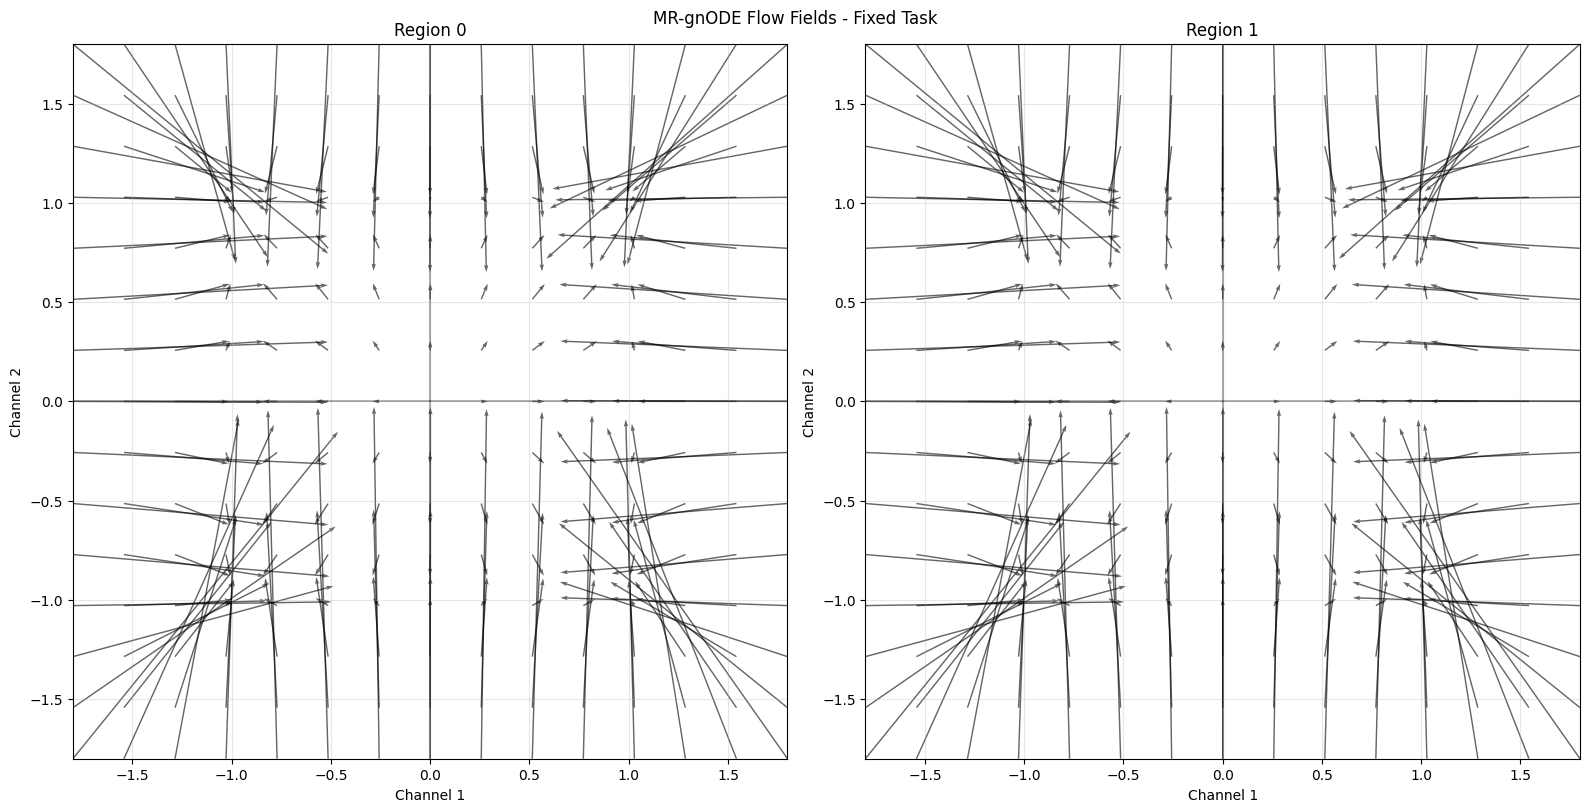

In [34]:

# # # Test with single region (equivalent to standard gnODE)
# # print("Testing Single Region MR-gnODE...")
task_type = 'fixed'

# # Generate data for single region
# train_data = generate_flip_flop_data(task_type, n_trials=1000, n_regions=1)

# # Create and train single-region model  
# model = MRgnODE(N=2, input_dim=2, num_regions=1)
# losses = train_mr_gnode(model, train_data, n_epochs=100, batch_size=64)

# # Plot results
# plot_flow_field(model, task_type, xlim=(-1.5, 1.5), ylim=(-1.5, 1.5))

# # Plot training curve
# plt.figure(figsize=(8, 4))
# plt.plot(losses)
# plt.title('Training Loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.yscale('log')
# plt.grid(True, alpha=0.3)
# plt.show()

# print(f"Final loss: {losses[-1]:.6f}")


print("\nTesting Multi-Region MR-gnODE...")
# train_data_mr = generate_mr_flip_flop_data_og(task_type, n_trials=500, n_regions=2)
# model_mr = MRgnODE(N=4, input_dim=2, num_regions=2)
# model_mr = torch.compile(model_mr)
# losses_mr = train_mr_gnode(model_mr, train_data_mr, n_epochs=200, lr=1e-3,batch_size=64)
plot_flow_field(model_mr, task_type, xlim=(-1.8, 1.8), ylim=(-1.8, 1.8))


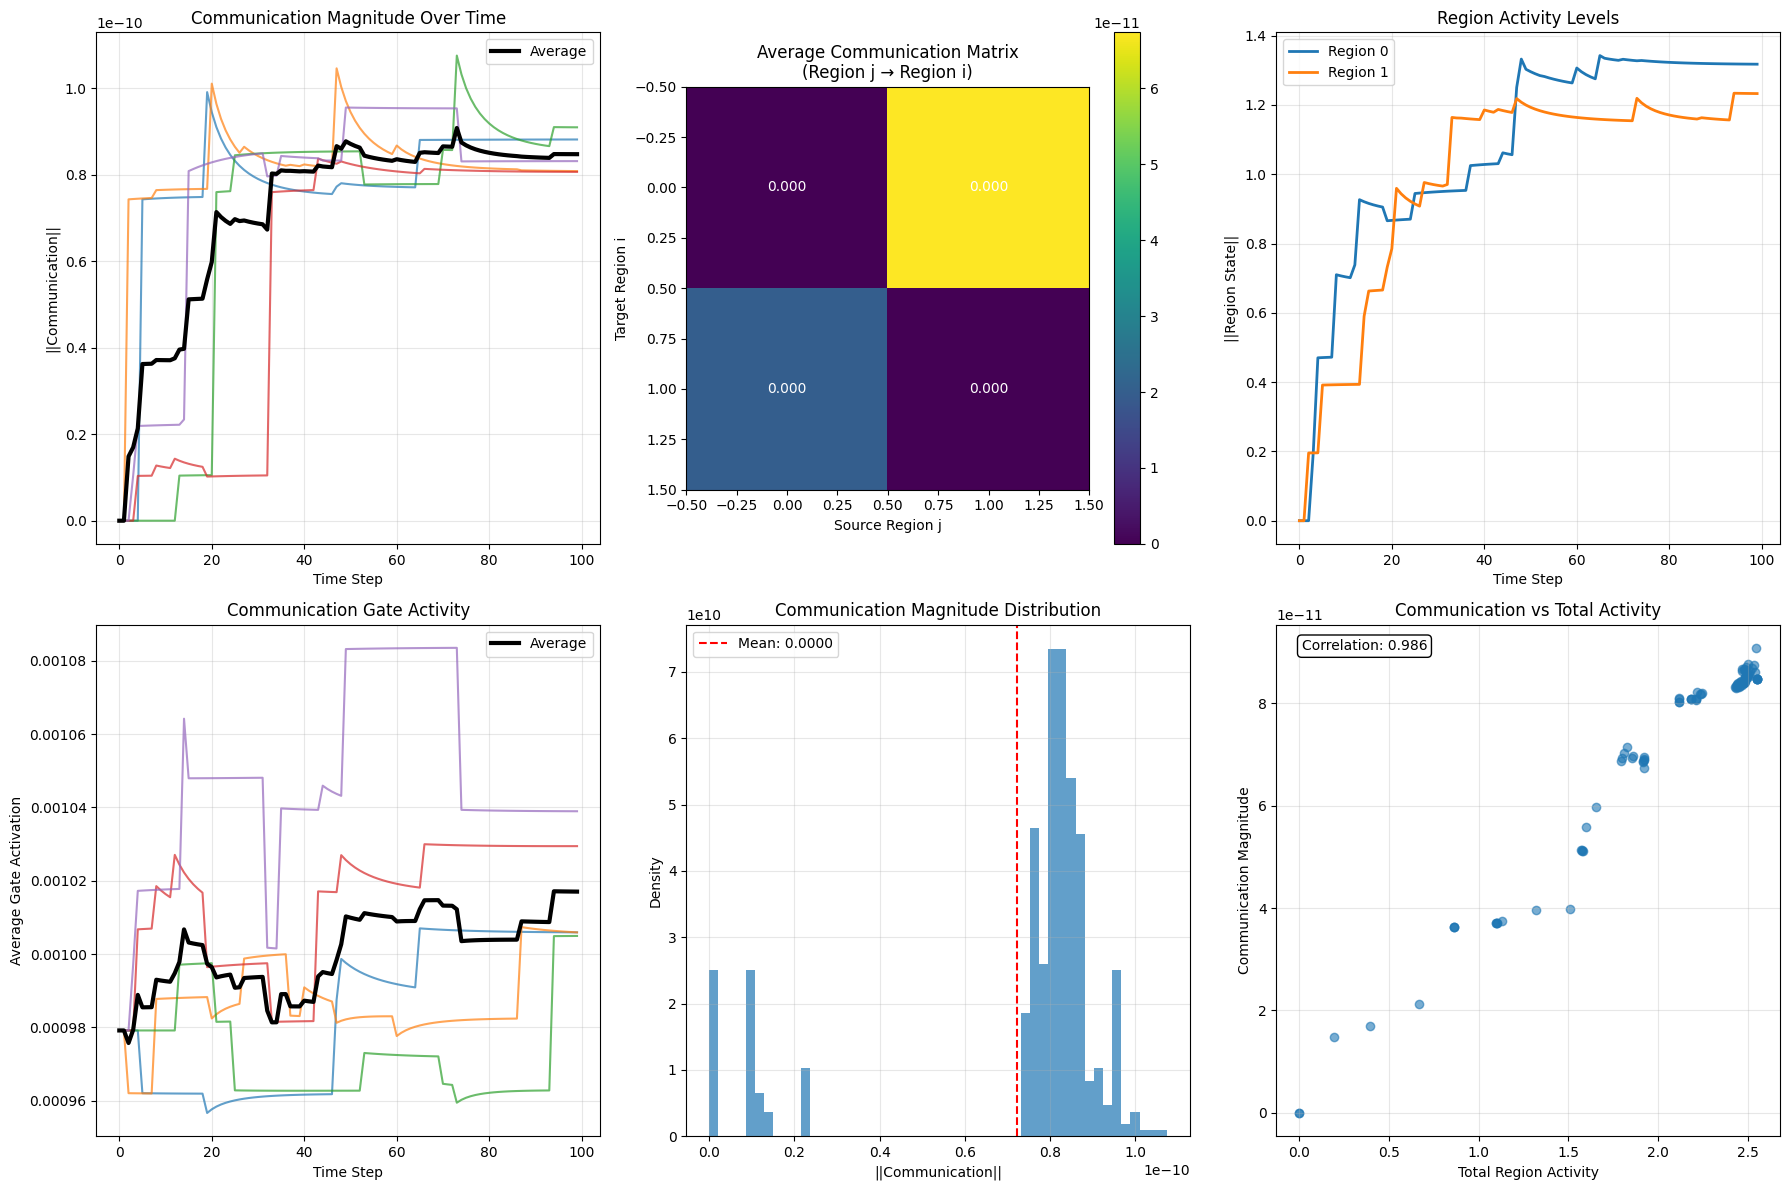

=== COMMUNICATION USAGE SUMMARY ===
Model: 2 regions, 2 dimensions each
Total parameters in comm_weights: 8

Communication Statistics:
  Mean communication magnitude: 0.000000
  Max communication magnitude: 0.000000
  Std communication magnitude: 0.000000

Gate Activity:
  Mean gate activation: 0.001001
  Max gate activation: 0.001084
  % time gates active (>0.1): 0.0%

Strongest Communication Pathways:
  Region 1 → Region 0: 0.000000

Communication Efficiency:
  Total communication 'cost': 0.000000
  Communication sparsity: 1.0% zero communication


In [35]:
analysis = analyze_communication(model_mr, train_data_mr[:5], device=device)
plot_communication_analysis(analysis, model_mr)
communication_summary(analysis, model_mr)

## MR TASKS

In [76]:
# Test the new communication tasks
print("Testing communication-required tasks...")
# results = {}
for task in ['sum']:  # Start with just sum to debug
    comm_data = generate_mr_flip_flop_data(task, n_trials=1500, n_regions=2)
    print(f"\n=== {task.upper()} Task Communication Test ===")
    
    # # 1. Train normal model (with communication)
    model_with_comm = MRgnODE(N=4, input_dim=2, num_regions=2)
    model_with_comm =  torch.compile(model_with_comm)
    losses_with = train_mr_gnode(model_with_comm, comm_data, n_epochs=200, lr=1e-3, batch_size=32, comm_penalty_lam=0)
    
    # # 2. Train model with communication disabled
    # model_no_comm = MRgnODE(N=4, input_dim=2, num_regions=2)
    # model_no_comm.comm_weights.data.fill_(0)
    # model_no_comm.comm_weights.requires_grad = False
    # model_no_comm =  torch.compile(model_no_comm)
    # losses_without = train_mr_gnode(model_no_comm, comm_data, n_epochs=200, lr=1e-3, batch_size=64, comm_penalty_lam=1)
    
    # # 3. Calculate random baseline
    # random_loss = 0
    # for inputs, targets in comm_data[:10]:
    #     inputs_tensor = torch.FloatTensor(inputs).to(device)
    #     targets_tensor = torch.FloatTensor(targets).to(device)
        
    #     # Baseline: each region outputs its own channel value
    #     baseline_output = torch.zeros_like(targets_tensor)
    #     baseline_output[:, 0, 0] = inputs_tensor[:, 0, 0]  # Region 1 outputs its input
    #     baseline_output[:, 1, 1] = inputs_tensor[:, 1, 1]  # Region 2 outputs its input
        
    #     trial_loss = nn.MSELoss()(baseline_output, targets_tensor).item()
    #     random_loss += trial_loss
    # random_loss /= 10
    
    print(f"Final Loss WITH communication:    {losses_with[-1]:.6f}")
    print(f"Final Loss WITHOUT communication: {losses_without[-1]:.6f}")
    print(f"Random baseline loss:             {random_loss:.6f}")
    print(f"Communication benefit: {losses_without[-1] - losses_with[-1]:.6f}")
    
    # 4. Communication analysis
    analysis = analyze_communication(model_with_comm, comm_data[:3], device=device)
    communication_summary(analysis, model_with_comm)  # Fixed: was model_comm

Testing communication-required tasks...

=== SUM Task Communication Test ===


Training MR-gnODE:   0%|▋                                                                                                                                     | 1/200 [00:13<43:33, 13.13s/it]

Epoch 0, Loss: 0.297051


Training MR-gnODE:  10%|█████████████▉                                                                                                                       | 21/200 [04:43<40:22, 13.53s/it]

Epoch 20, Loss: 0.155480


...

Epoch 160, Loss: 0.074756


Training MR-gnODE:  90%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍            | 181/200 [40:48<04:15, 13.45s/it]

Epoch 180, Loss: 0.071301


Training MR-gnODE: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [45:05<00:00, 13.53s/it]


Final Loss WITH communication:    0.070687
Final Loss WITHOUT communication: 0.125823
Random baseline loss:             0.239396
Communication benefit: 0.055136
=== COMMUNICATION USAGE SUMMARY ===
Model: 2 regions, 2 dimensions each
Total parameters in comm_weights: 8

Communication Statistics:
  Mean communication magnitude: 0.423622
  Max communication magnitude: 0.996200
  Std communication magnitude: 0.240434

Gate Activity:
  Mean gate activation: 0.928189
  Max gate activation: 0.954657
  % time gates active (>0.1): 100.0%

Strongest Communication Pathways:
  Region 1 → Region 0: 0.298100
  Region 0 → Region 1: 0.288825

Communication Efficiency:
  Total communication 'cost': 127.086690
  Communication sparsity: 1.0% zero communication


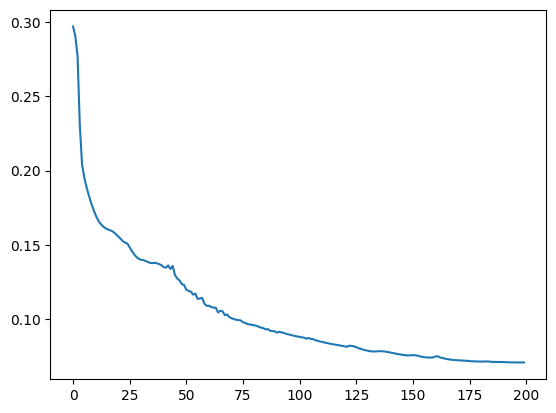

In [77]:
plt.plot(losses_with)

Trial 0 has 14 pulse events
=== Communication Model Comparison ===


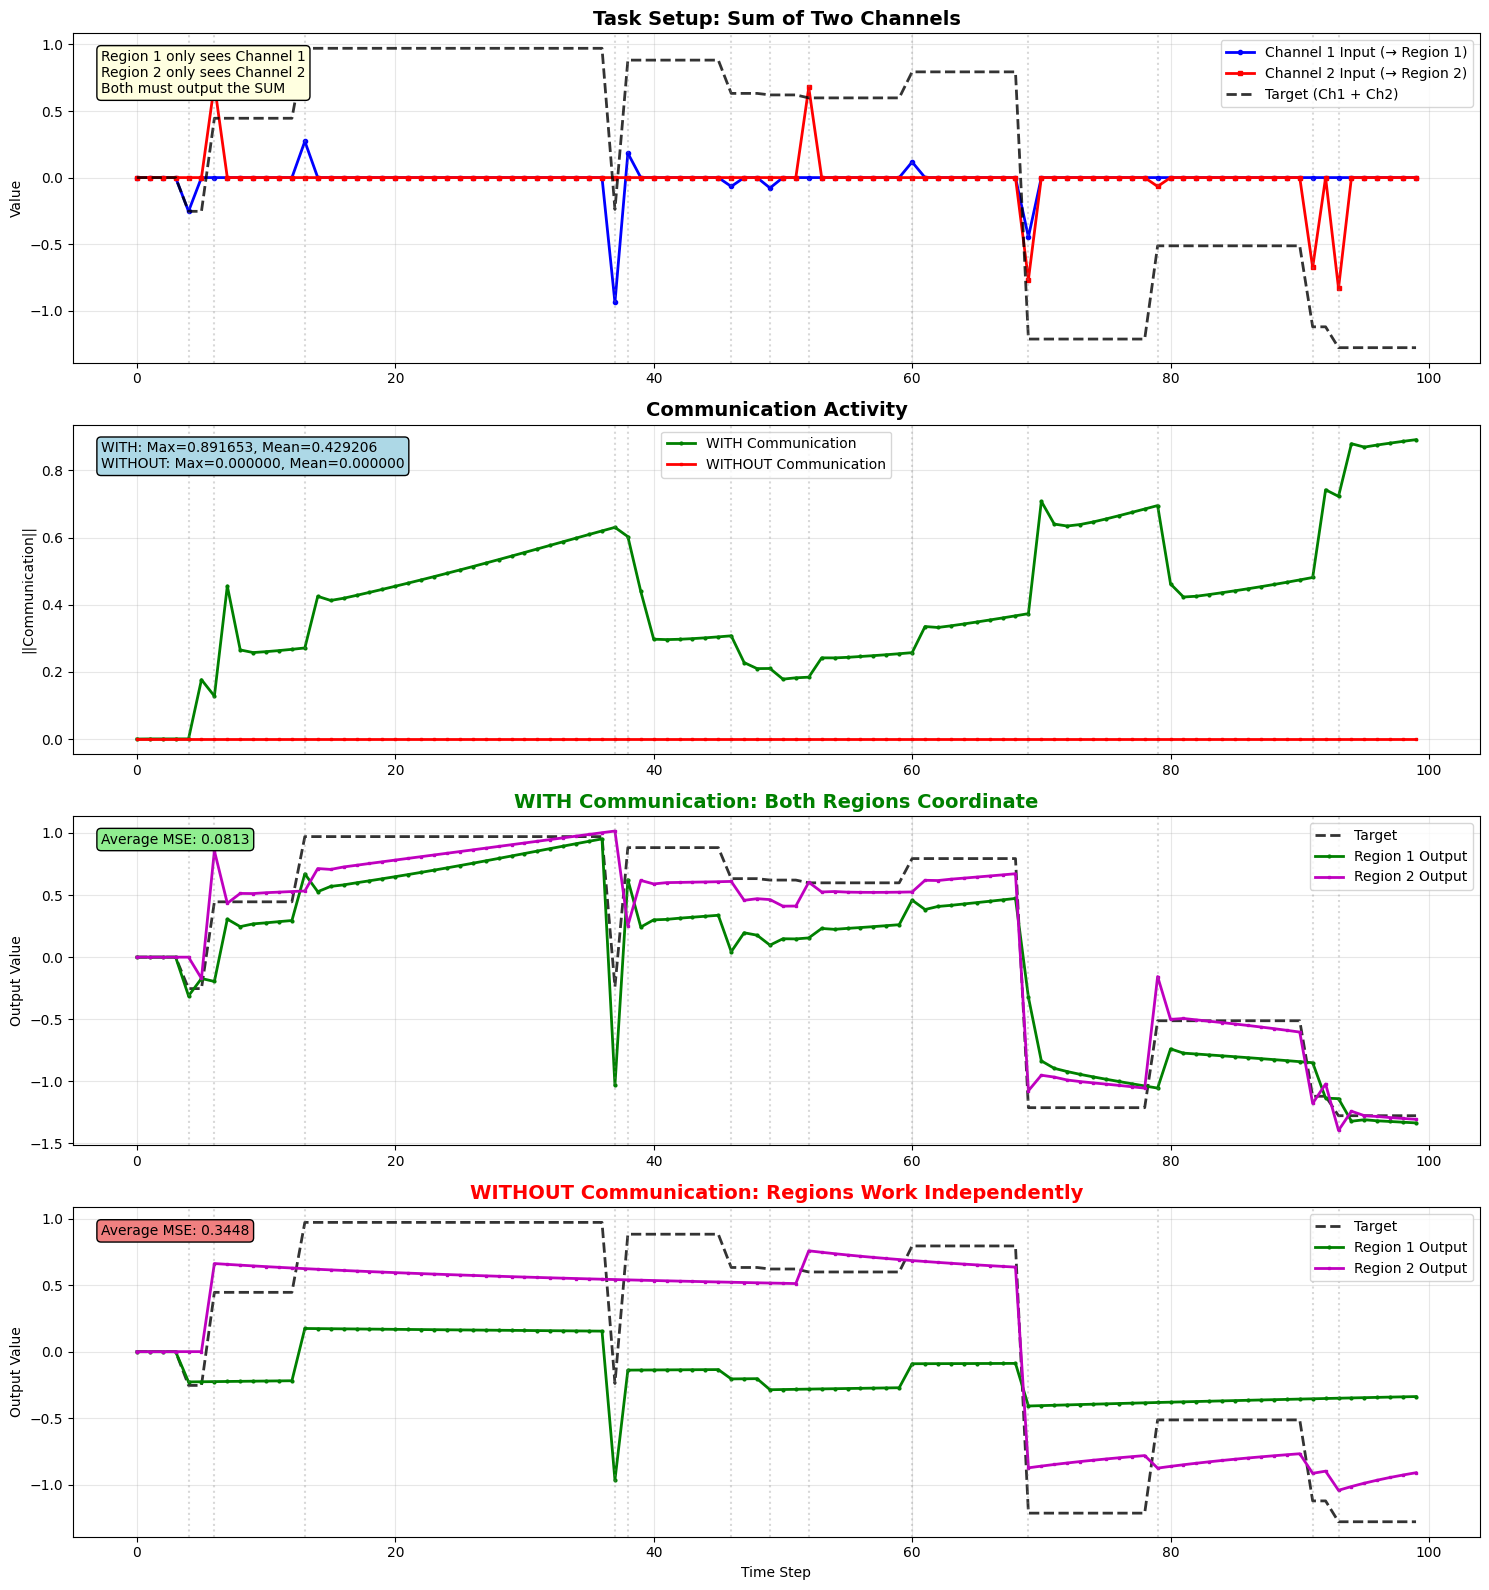

=== PERFORMANCE COMPARISON ===
MSE WITH communication:    0.081302
MSE WITHOUT communication: 0.344778
Improvement factor:        4.24x better

=== COMMUNICATION ANALYSIS ===
WITH communication - Mean: 0.42920576, Max: 0.89165342
WITHOUT communication - Mean: 0.00000000, Max: 0.00000000
Communication is ENABLED
Zero-comm enforcement is WORKING

Pulse times: [4, 6, 13, 37, 38, 46, 49, 52, 60, 69, 79, 91, 93]
Total pulses: 13


In [78]:
def visualize_communication_models(model_with_comm, model_no_comm, trial_data, max_time=100):
    """
    Visualize how models with and without communication handle the sum task
    """
    inputs, targets = trial_data
    max_time = min(max_time, inputs.shape[0])
    
    # Run model WITH communication
    model_with_comm.eval()
    inputs_tensor = torch.FloatTensor(inputs).unsqueeze(0).to(device)  # [1, time, regions, channels]
    
    h_with = torch.zeros(1, model_with_comm.N, device=device)
    outputs_with_comm = []
    comm_magnitudes_with = []
    
    for t in range(max_time):
        x_t = inputs_tensor[:, t]  # [1, regions, channels] - correct format
        h_with, comm = euler_step(model_with_comm, h_with, x_t, 0.01)
        
        # Track communication magnitude
        comm_mag = torch.norm(comm).item()
        comm_magnitudes_with.append(comm_mag)
        
        # Reshape output to [batch, regions, region_dim]
        region_outputs = h_with.view(1, model_with_comm.num_regions, model_with_comm.region_dim)
        outputs_with_comm.append([
            region_outputs[0, 0, 0].item(),  # Region 1 output (channel 0)
            region_outputs[0, 1, 1].item()   # Region 2 output (channel 1)
        ])
    
    # Run model WITHOUT communication
    model_no_comm.eval()
    
    h_without = torch.zeros(1, model_no_comm.N, device=device)
    outputs_no_comm = []
    comm_magnitudes_without = []
    
    for t in range(max_time):
        x_t = inputs_tensor[:, t]  # [1, regions, channels] - correct format
        h_without, comm = euler_step(model_no_comm, h_without, x_t, 0.01)
        
        # Track communication magnitude (should be zero)
        comm_mag = torch.norm(comm).item()
        comm_magnitudes_without.append(comm_mag)
        
        region_outputs = h_without.view(1, model_no_comm.num_regions, model_no_comm.region_dim)
        outputs_no_comm.append([
            region_outputs[0, 0, 0].item(),  # Region 1 output
            region_outputs[0, 1, 1].item()   # Region 2 output
        ])
    
    # Extract data for plotting
    times = np.arange(max_time)
    ch1_inputs = inputs[:max_time, 0, 0]  # Region 1 gets channel 1
    ch2_inputs = inputs[:max_time, 1, 1]  # Region 2 gets channel 2
    target_values = targets[:max_time, 0, 0]  # Both should output the sum
    
    outputs_with_comm = np.array(outputs_with_comm)
    outputs_no_comm = np.array(outputs_no_comm)
    comm_magnitudes_with = np.array(comm_magnitudes_with)
    comm_magnitudes_without = np.array(comm_magnitudes_without)
    
    # Find pulse times for highlighting
    pulse_times = []
    for t in range(max_time):
        if abs(ch1_inputs[t]) > 0.01 or abs(ch2_inputs[t]) > 0.01:
            pulse_times.append(t)
    
    # Create the visualization
    fig, axes = plt.subplots(4, 1, figsize=(15, 16))
    
    # Plot 1: Inputs and Target
    axes[0].plot(times, ch1_inputs, 'b-', linewidth=2, label='Channel 1 Input (→ Region 1)', marker='o', markersize=3)
    axes[0].plot(times, ch2_inputs, 'r-', linewidth=2, label='Channel 2 Input (→ Region 2)', marker='s', markersize=3)
    axes[0].plot(times, target_values, 'k--', linewidth=2, label='Target (Ch1 + Ch2)', alpha=0.8)
    
    # Highlight pulse times
    for pt in pulse_times:
        axes[0].axvline(x=pt, color='gray', alpha=0.3, linestyle=':')
    
    axes[0].set_title('Task Setup: Sum of Two Channels', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Value')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].text(0.02, 0.95, 'Region 1 only sees Channel 1\nRegion 2 only sees Channel 2\nBoth must output the SUM', 
                transform=axes[0].transAxes, verticalalignment='top', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow"))
    
    # Plot 2: Communication Magnitudes
    axes[1].plot(times, comm_magnitudes_with, 'g-', linewidth=2, label='WITH Communication', marker='o', markersize=2)
    axes[1].plot(times, comm_magnitudes_without, 'r-', linewidth=2, label='WITHOUT Communication', marker='s', markersize=2)
    
    # Highlight pulse times
    for pt in pulse_times:
        axes[1].axvline(x=pt, color='gray', alpha=0.3, linestyle=':')
    
    axes[1].set_title('Communication Activity', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('||Communication||')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].text(0.02, 0.95, f'WITH: Max={np.max(comm_magnitudes_with):.6f}, Mean={np.mean(comm_magnitudes_with):.6f}\nWITHOUT: Max={np.max(comm_magnitudes_without):.6f}, Mean={np.mean(comm_magnitudes_without):.6f}', 
                transform=axes[1].transAxes, verticalalignment='top', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
    
    # Plot 3: Model WITH Communication
    axes[2].plot(times, target_values, 'k--', linewidth=2, label='Target', alpha=0.8)
    axes[2].plot(times, outputs_with_comm[:, 0], 'g-', linewidth=2, label='Region 1 Output', marker='o', markersize=2)
    axes[2].plot(times, outputs_with_comm[:, 1], 'm-', linewidth=2, label='Region 2 Output', marker='s', markersize=2)
    
    # Highlight pulse times
    for pt in pulse_times:
        axes[2].axvline(x=pt, color='gray', alpha=0.3, linestyle=':')
    
    axes[2].set_title('WITH Communication: Both Regions Coordinate', fontsize=14, fontweight='bold', color='green')
    axes[2].set_ylabel('Output Value')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    # Calculate MSE for with communication
    mse_with = np.mean((outputs_with_comm - target_values.reshape(-1, 1))**2)
    axes[2].text(0.02, 0.95, f'Average MSE: {mse_with:.4f}', 
                transform=axes[2].transAxes, verticalalignment='top', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen"))
    
    # Plot 4: Model WITHOUT Communication  
    axes[3].plot(times, target_values, 'k--', linewidth=2, label='Target', alpha=0.8)
    axes[3].plot(times, outputs_no_comm[:, 0], 'g-', linewidth=2, label='Region 1 Output', marker='o', markersize=2)
    axes[3].plot(times, outputs_no_comm[:, 1], 'm-', linewidth=2, label='Region 2 Output', marker='s', markersize=2)
    
    # Highlight pulse times
    for pt in pulse_times:
        axes[3].axvline(x=pt, color='gray', alpha=0.3, linestyle=':')
    
    axes[3].set_title('WITHOUT Communication: Regions Work Independently', fontsize=14, fontweight='bold', color='red')
    axes[3].set_xlabel('Time Step')
    axes[3].set_ylabel('Output Value')
    axes[3].legend()
    axes[3].grid(True, alpha=0.3)
    
    # Calculate MSE for without communication
    mse_without = np.mean((outputs_no_comm - target_values.reshape(-1, 1))**2)
    axes[3].text(0.02, 0.95, f'Average MSE: {mse_without:.4f}', 
                transform=axes[3].transAxes, verticalalignment='top', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral"))
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("=== PERFORMANCE COMPARISON ===")
    print(f"MSE WITH communication:    {mse_with:.6f}")
    print(f"MSE WITHOUT communication: {mse_without:.6f}")
    print(f"Improvement factor:        {mse_without/mse_with:.2f}x better")
    
    print("\n=== COMMUNICATION ANALYSIS ===")
    print(f"WITH communication - Mean: {np.mean(comm_magnitudes_with):.8f}, Max: {np.max(comm_magnitudes_with):.8f}")
    print(f"WITHOUT communication - Mean: {np.mean(comm_magnitudes_without):.8f}, Max: {np.max(comm_magnitudes_without):.8f}")
    print(f"Communication is {'ENABLED' if np.max(comm_magnitudes_with) > 1e-6 else 'NOT WORKING'}")
    print(f"Zero-comm enforcement is {'WORKING' if np.max(comm_magnitudes_without) < 1e-8 else 'FAILED'}")
    
    print(f"\nPulse times: {pulse_times}")
    print(f"Total pulses: {len(pulse_times)}")

# Find a trial with actual pulses
def find_interesting_trial(data):
    for i, (inputs, targets) in enumerate(data):
        # Check if this trial has pulses
        if np.any(inputs > 0.01) or np.any(inputs < -0.01):
            pulse_count = np.sum(np.abs(inputs) > 0.01)
            print(f"Trial {i} has {pulse_count} pulse events")
            return inputs, targets
    return None, None

# Get a trial with pulses
interesting_inputs, interesting_targets = find_interesting_trial(comm_data)

    
# Run the visualization
print("=== Communication Model Comparison ===")
visualize_communication_models(model_with_comm, model_no_comm, (interesting_inputs, interesting_targets))

Using device: cuda
Training Multi-Region RNN...


Training Multi-Region RNN:   1%|█▎                                                                                                                            | 1/100 [00:04<06:56,  4.21s/it]

Epoch 0: Total=0.8642, Evidence=0.8288, Motor=0.0354


Training Multi-Region RNN:  21%|██████████████████████████▎                                                                                                  | 21/100 [01:12<04:24,  3.34s/it]

Epoch 20: Total=0.0584, Evidence=0.0451, Motor=0.0133


...

Training Multi-Region RNN:  61%|████████████████████████████████████████████████████████████████████████████▎                                                | 61/100 [03:28<02:13,  3.43s/it]

Epoch 60: Total=0.0077, Evidence=0.0029, Motor=0.0048


Training Multi-Region RNN:  81%|█████████████████████████████████████████████████████████████████████████████████████████████████████▎                       | 81/100 [04:36<01:04,  3.41s/it]

Epoch 80: Total=0.0062, Evidence=0.0018, Motor=0.0045


Training Multi-Region RNN: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [05:42<00:00,  3.42s/it]


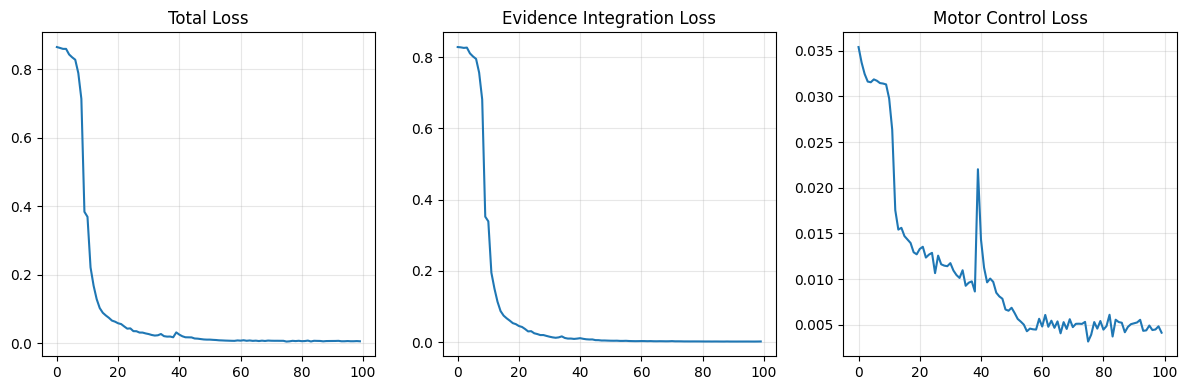

Analyzing trained model...


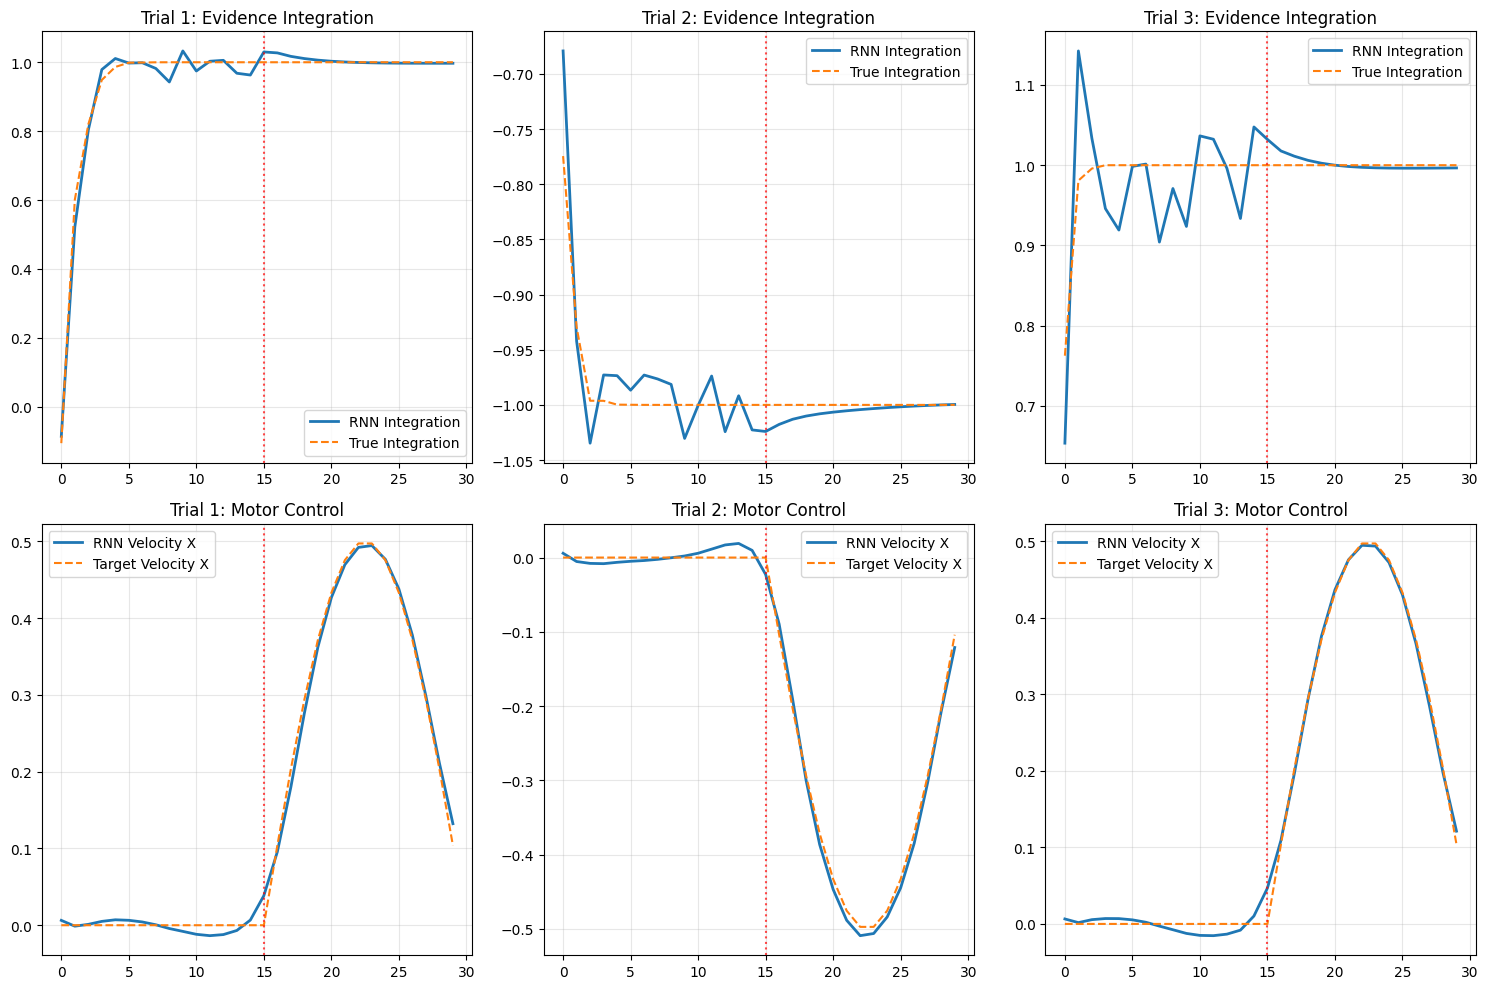

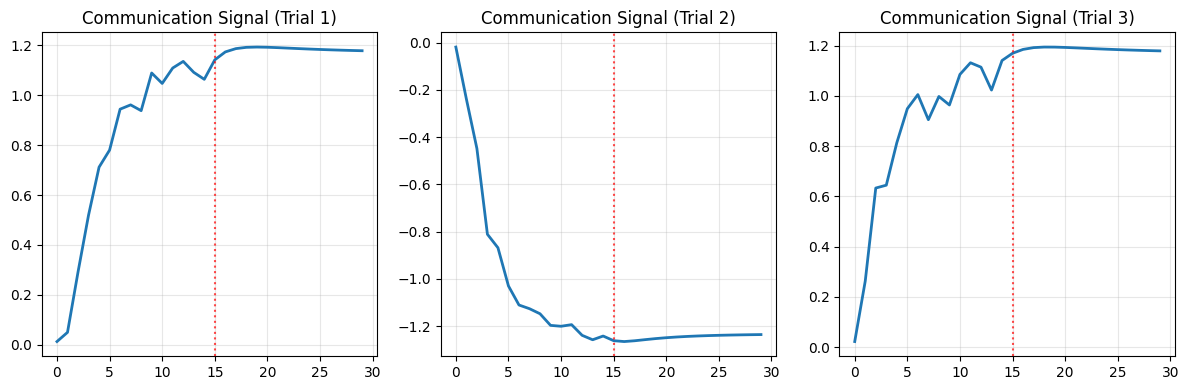

Training complete! Model saved as 'trained_model'


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Task parameters
SEQUENCE_LENGTH = 30
EVIDENCE_PHASE = 15  # First 40 steps have evidence
RESPONSE_STEP = 29   # Must be correct at step 49
BATCH_SIZE = 128
N_TRIALS = 1000
COHERENCE = 0.8      # Evidence strength
NOISE_LEVEL = 0.5    # Evidence noise

def generate_task_data(batch_size, sequence_length, coherence=0.3, noise_level=0.5):
    """Generate evidence integration + reaching task data"""
    
    # Random target direction for each trial (0=LEFT, 1=RIGHT)
    targets = torch.randint(0, 2, (batch_size,), device=device)
    
    # Evidence streams (first 40 timesteps)
    evidence = torch.zeros(batch_size, sequence_length, 2, device=device)
    evidence[:, :EVIDENCE_PHASE, 0] = (1 - targets.float()).unsqueeze(1) * coherence + \
                                      torch.randn(batch_size, EVIDENCE_PHASE, device=device) * noise_level
    evidence[:, :EVIDENCE_PHASE, 1] = targets.float().unsqueeze(1) * coherence + \
                                      torch.randn(batch_size, EVIDENCE_PHASE, device=device) * noise_level
    
    # True evidence integration (teaching signal for Region 1)
    true_integration = torch.cumsum(evidence[:, :, 1] - evidence[:, :, 0], dim=1)
    true_integration = torch.tanh(true_integration)  # Bounded integration
    
    # Target reach trajectories (teaching signal for Region 2)
    target_positions = torch.zeros(batch_size, sequence_length, 2, device=device)
    target_velocities = torch.zeros(batch_size, sequence_length, 2, device=device)
    
    for i in range(batch_size):
        if targets[i] == 0:  # LEFT reach
            target_positions[i, :, 0] = -1.0  # x = -1
            target_positions[i, :, 1] = 0.0   # y = 0
        else:  # RIGHT reach  
            target_positions[i, :, 0] = 1.0   # x = 1
            target_positions[i, :, 1] = 0.0   # y = 0
    
    # Smooth velocity trajectories (start moving after evidence phase)
    for t in range(EVIDENCE_PHASE, sequence_length):
        progress = (t - EVIDENCE_PHASE) / (sequence_length - EVIDENCE_PHASE)
        smooth_vel = 0.5 * np.sin(np.pi * progress) if progress < 1.0 else 0.0
        
        for i in range(batch_size):
            if targets[i] == 0:  # LEFT
                target_velocities[i, t, 0] = -smooth_vel
            else:  # RIGHT
                target_velocities[i, t, 0] = smooth_vel
    
    return {
        'evidence': evidence,
        'targets': targets,
        'true_integration': true_integration,
        'target_positions': target_positions,
        'target_velocities': target_velocities
    }

class MultiRegionRNN(nn.Module):
    def __init__(self, evidence_hidden=64, motor_hidden=64):
        super().__init__()
        
        # Region 1: Evidence Integrator
        self.evidence_rnn = nn.LSTM(
            input_size=2,  # [evidence_left, evidence_right]
            hidden_size=evidence_hidden,
            batch_first=True
        )
        self.evidence_output = nn.Linear(evidence_hidden, 1)  # Integrated evidence
        
        # Region 2: Motor Controller  
        self.motor_rnn = nn.LSTM(
            input_size=3,  # [communication_from_R1, position_x, position_y]
            hidden_size=motor_hidden,
            batch_first=True
        )
        self.motor_output = nn.Linear(motor_hidden, 2)  # [velocity_x, velocity_y]
        
        # Communication layer (Region 1 → Region 2)
        self.communication = nn.Linear(evidence_hidden, 1)
        
        self.evidence_hidden_size = evidence_hidden
        self.motor_hidden_size = motor_hidden
        
    def forward(self, evidence_input):
        batch_size, seq_len, _ = evidence_input.shape
        
        # Initialize motor state
        motor_position = torch.zeros(batch_size, seq_len, 2, device=evidence_input.device)
        motor_velocity = torch.zeros(batch_size, seq_len, 2, device=evidence_input.device)
        
        # Storage for outputs
        evidence_outputs = []
        motor_outputs = []
        communications = []
        
        # Initialize hidden states
        evidence_hidden = (torch.zeros(1, batch_size, self.evidence_hidden_size, device=evidence_input.device),
                          torch.zeros(1, batch_size, self.evidence_hidden_size, device=evidence_input.device))
        motor_hidden = (torch.zeros(1, batch_size, self.motor_hidden_size, device=evidence_input.device),
                       torch.zeros(1, batch_size, self.motor_hidden_size, device=evidence_input.device))
        
        for t in range(seq_len):
            # Region 1: Evidence Integration
            evidence_out, evidence_hidden = self.evidence_rnn(
                evidence_input[:, t:t+1, :], evidence_hidden
            )
            integrated_evidence = self.evidence_output(evidence_out.squeeze(1))
            evidence_outputs.append(integrated_evidence)
            
            # Communication: Region 1 → Region 2
            comm_signal = self.communication(evidence_out.squeeze(1))
            communications.append(comm_signal)
            
            # Region 2: Motor Control
            motor_input = torch.cat([
                comm_signal,
                motor_position[:, t, :]
            ], dim=1).unsqueeze(1)
            
            motor_out, motor_hidden = self.motor_rnn(motor_input, motor_hidden)
            velocity_output = torch.tanh(self.motor_output(motor_out.squeeze(1)))
            motor_outputs.append(velocity_output)
            
            # Update motor state for next timestep
            if t < seq_len - 1:
                motor_velocity[:, t+1, :] = velocity_output
                motor_position[:, t+1, :] = motor_position[:, t, :] + velocity_output * 0.1
        
        return {
            'evidence_integration': torch.stack(evidence_outputs, dim=1),
            'motor_velocity': torch.stack(motor_outputs, dim=1),
            'communication': torch.stack(communications, dim=1),
            'motor_position': motor_position
        }

def train_multi_region_rnn():
    """Train multi-region RNN efficiently"""
    
    # Initialize model
    model = MultiRegionRNN(evidence_hidden=64, motor_hidden=64).to(device)
    model = torch.compile(model)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=5e-3, epochs=100, steps_per_epoch=N_TRIALS//BATCH_SIZE
    )
    
    # Training loop
    losses = []
    evidence_losses = []
    motor_losses = []
    
    for epoch in tqdm(range(100), desc="Training Multi-Region RNN"):
        epoch_loss = 0
        epoch_evidence_loss = 0
        epoch_motor_loss = 0
        
        for batch_idx in range(N_TRIALS // BATCH_SIZE):
            # Generate batch
            batch_data = generate_task_data(BATCH_SIZE, SEQUENCE_LENGTH)
            
            # Forward pass
            outputs = model(batch_data['evidence'])
            
            # Loss computation
            # Region 1 loss: Evidence integration accuracy
            evidence_loss = nn.MSELoss()(
                outputs['evidence_integration'], 
                batch_data['true_integration'].unsqueeze(-1)
            )
            
            # Region 2 loss: Motor control accuracy  
            motor_loss = nn.MSELoss()(
                outputs['motor_velocity'],
                batch_data['target_velocities']
            )
            
            # Combined loss
            total_loss = evidence_loss + motor_loss
            
            # Backward pass
            optimizer.zero_grad()
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            
            epoch_loss += total_loss.item()
            epoch_evidence_loss += evidence_loss.item()
            epoch_motor_loss += motor_loss.item()
        
        # Record losses
        avg_loss = epoch_loss / (N_TRIALS // BATCH_SIZE)
        avg_evidence_loss = epoch_evidence_loss / (N_TRIALS // BATCH_SIZE)
        avg_motor_loss = epoch_motor_loss / (N_TRIALS // BATCH_SIZE)
        
        losses.append(avg_loss)
        evidence_losses.append(avg_evidence_loss)
        motor_losses.append(avg_motor_loss)
        
        if epoch % 20 == 0:
            print(f"Epoch {epoch}: Total={avg_loss:.4f}, Evidence={avg_evidence_loss:.4f}, Motor={avg_motor_loss:.4f}")
    
    return model, losses, evidence_losses, motor_losses

def analyze_trained_model(model):
    """Analyze the trained multi-region RNN"""
    model.eval()
    
    with torch.no_grad():
        # Generate test data
        test_data = generate_task_data(5, SEQUENCE_LENGTH, coherence=0.5)
        outputs = model(test_data['evidence'])
        
        # Plot results
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # Evidence integration
        for trial in range(3):
            axes[0, trial].plot(outputs['evidence_integration'][trial].cpu(), 
                              label='RNN Integration', linewidth=2)
            axes[0, trial].plot(test_data['true_integration'][trial].cpu(), 
                              label='True Integration', linestyle='--')
            axes[0, trial].axvline(x=EVIDENCE_PHASE, color='red', linestyle=':', alpha=0.7)
            axes[0, trial].set_title(f'Trial {trial+1}: Evidence Integration')
            axes[0, trial].legend()
            axes[0, trial].grid(True, alpha=0.3)
        
        # Motor control
        for trial in range(3):
            axes[1, trial].plot(outputs['motor_velocity'][trial, :, 0].cpu(), 
                              label='RNN Velocity X', linewidth=2)
            axes[1, trial].plot(test_data['target_velocities'][trial, :, 0].cpu(), 
                              label='Target Velocity X', linestyle='--')
            axes[1, trial].axvline(x=EVIDENCE_PHASE, color='red', linestyle=':', alpha=0.7)
            axes[1, trial].set_title(f'Trial {trial+1}: Motor Control')
            axes[1, trial].legend()
            axes[1, trial].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Communication analysis
        plt.figure(figsize=(12, 4))
        for trial in range(3):
            plt.subplot(1, 3, trial+1)
            plt.plot(outputs['communication'][trial].cpu(), linewidth=2)
            plt.axvline(x=EVIDENCE_PHASE, color='red', linestyle=':', alpha=0.7)
            plt.title(f'Communication Signal (Trial {trial+1})')
            plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

# Train the model
print("Training Multi-Region RNN...")
trained_model, losses, evidence_losses, motor_losses = train_multi_region_rnn()

# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(losses)
plt.title('Total Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(evidence_losses)
plt.title('Evidence Integration Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(motor_losses)
plt.title('Motor Control Loss')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analyze the trained model
print("Analyzing trained model...")
analyze_trained_model(trained_model)

print("Training complete! Model saved as 'trained_model'")

Analyzing your trained model...
Extracting trajectories from trained model...

Analyzing Evidence Region...
Evidence PCA explained variance: [0.9017112  0.06477616 0.01289704]


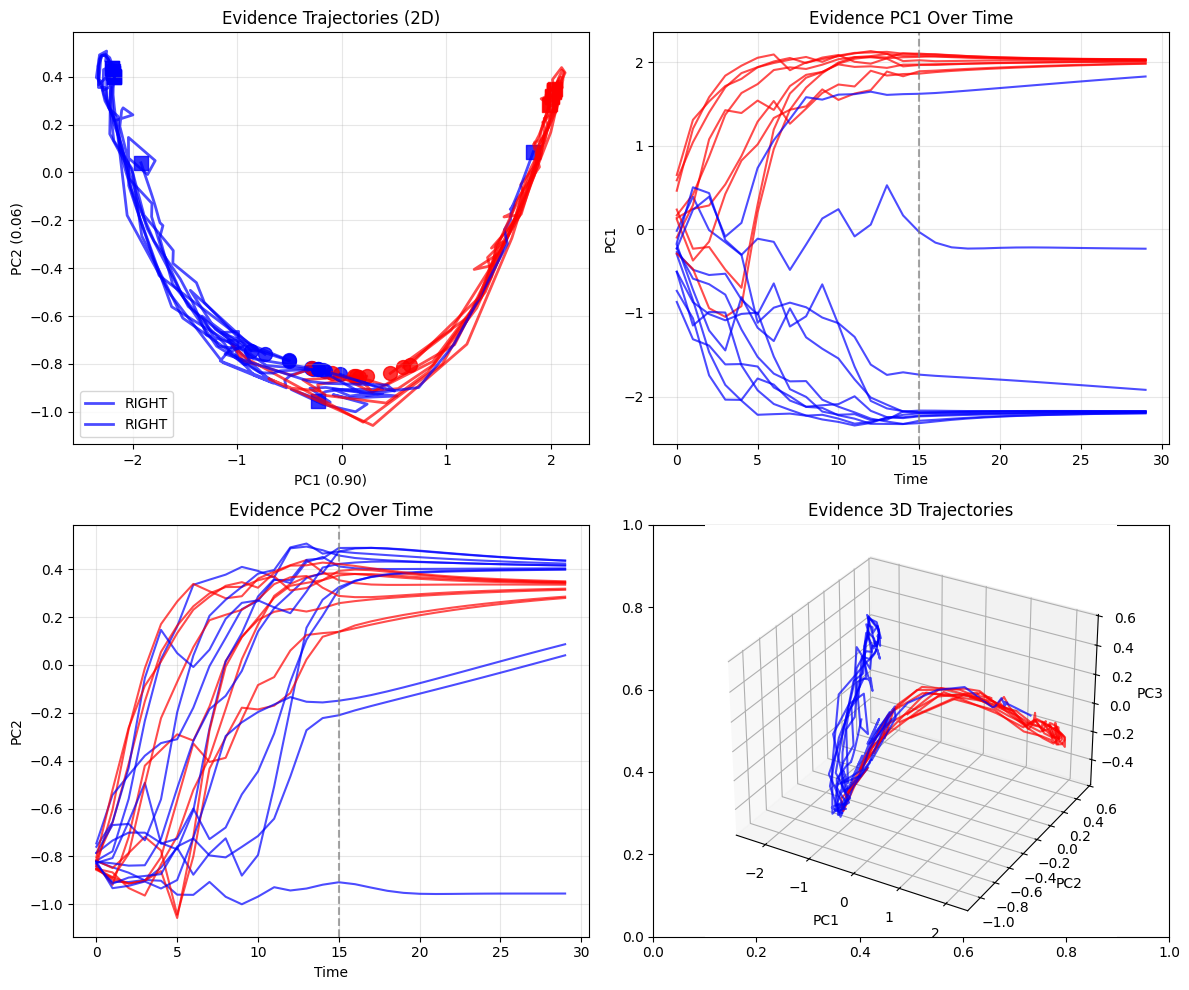


Analyzing Motor Region...
Motor PCA explained variance: [0.39667544 0.25444973 0.21518327]


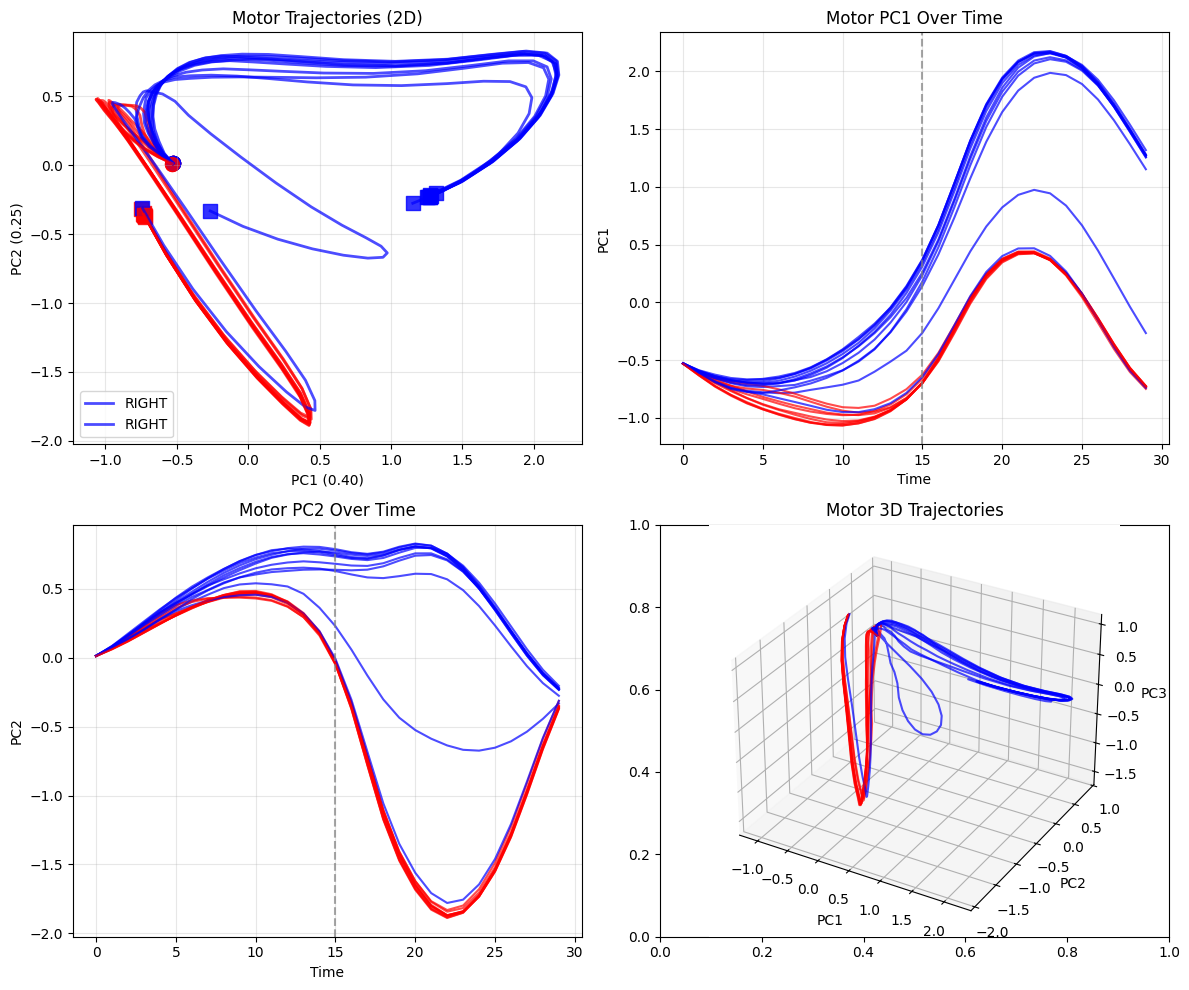


Analyzing Communication...


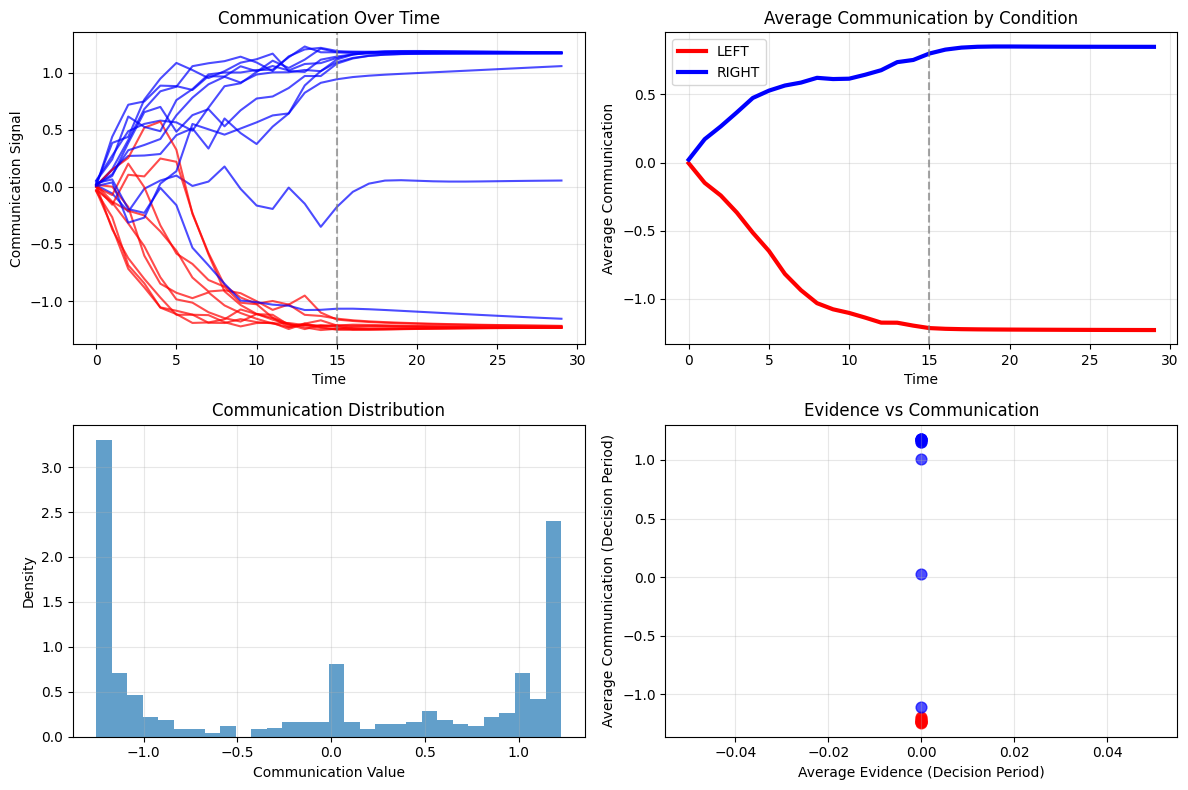

In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

# Use the same constants from your training code
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEQUENCE_LENGTH = 30
EVIDENCE_PHASE = 15
COHERENCE = 0.8
NOISE_LEVEL = 0.5

def generate_task_data(batch_size, sequence_length, coherence=0.3, noise_level=0.5):
    """Generate evidence integration + reaching task data"""
    
    # Random target direction for each trial (0=LEFT, 1=RIGHT)
    targets = torch.randint(0, 2, (batch_size,), device=device)
    
    # Evidence streams (first 15 timesteps)
    evidence = torch.zeros(batch_size, sequence_length, 2, device=device)
    evidence[:, :EVIDENCE_PHASE, 0] = (1 - targets.float()).unsqueeze(1) * coherence + \
                                      torch.randn(batch_size, EVIDENCE_PHASE, device=device) * noise_level
    evidence[:, :EVIDENCE_PHASE, 1] = targets.float().unsqueeze(1) * coherence + \
                                      torch.randn(batch_size, EVIDENCE_PHASE, device=device) * noise_level
    
    # True evidence integration (teaching signal for Region 1)
    true_integration = torch.cumsum(evidence[:, :, 1] - evidence[:, :, 0], dim=1)
    true_integration = torch.tanh(true_integration)  # Bounded integration
    
    # Target reach trajectories (teaching signal for Region 2)
    target_positions = torch.zeros(batch_size, sequence_length, 2, device=device)
    target_velocities = torch.zeros(batch_size, sequence_length, 2, device=device)
    
    for i in range(batch_size):
        if targets[i] == 0:  # LEFT reach
            target_positions[i, :, 0] = -1.0  # x = -1
            target_positions[i, :, 1] = 0.0   # y = 0
        else:  # RIGHT reach  
            target_positions[i, :, 0] = 1.0   # x = 1
            target_positions[i, :, 1] = 0.0   # y = 0
    
    # Smooth velocity trajectories (start moving after evidence phase)
    for t in range(EVIDENCE_PHASE, sequence_length):
        progress = (t - EVIDENCE_PHASE) / (sequence_length - EVIDENCE_PHASE)
        smooth_vel = 0.5 * np.sin(np.pi * progress) if progress < 1.0 else 0.0
        
        for i in range(batch_size):
            if targets[i] == 0:  # LEFT
                target_velocities[i, t, 0] = -smooth_vel
            else:  # RIGHT
                target_velocities[i, t, 0] = smooth_vel
    
    return {
        'evidence': evidence,
        'targets': targets,
        'true_integration': true_integration,
        'target_positions': target_positions,
        'target_velocities': target_velocities
    }

def extract_trajectories(model, n_trials=10):
    """Extract hidden state trajectories from trained model"""
    model.eval()
    
    evidence_states = []
    motor_states = []
    communications = []
    trial_info = []
    
    with torch.no_grad():
        for trial_idx in range(n_trials):
            batch_data = generate_task_data(1, SEQUENCE_LENGTH)  # Single trial
            
            # Run model and collect hidden states
            evidence_hiddens = []
            motor_hiddens = []
            comms = []
            
            evidence_hidden = (torch.zeros(1, 1, model.evidence_hidden_size, device=device),
                              torch.zeros(1, 1, model.evidence_hidden_size, device=device))
            motor_hidden = (torch.zeros(1, 1, model.motor_hidden_size, device=device),
                           torch.zeros(1, 1, model.motor_hidden_size, device=device))
            
            motor_position = torch.zeros(1, 2, device=device)
            
            for t in range(SEQUENCE_LENGTH):
                # Evidence region
                evidence_out, evidence_hidden = model.evidence_rnn(
                    batch_data['evidence'][:, t:t+1, :], evidence_hidden
                )
                evidence_hiddens.append(evidence_hidden[0].squeeze().cpu().numpy())
                
                # Communication
                comm = model.communication(evidence_out.squeeze(1))
                comms.append(comm.cpu().numpy())
                
                # Motor region
                motor_input = torch.cat([comm, motor_position], dim=1).unsqueeze(1)
                motor_out, motor_hidden = model.motor_rnn(motor_input, motor_hidden)
                motor_hiddens.append(motor_hidden[0].squeeze().cpu().numpy())
                
                # Update motor position
                velocity = torch.tanh(model.motor_output(motor_out.squeeze(1)))
                motor_position = motor_position + velocity * 0.1
            
            evidence_states.append(np.array(evidence_hiddens))
            motor_states.append(np.array(motor_hiddens))
            communications.append(np.array(comms).squeeze())
            trial_info.append({
                'target': batch_data['targets'].item(),
                'evidence': batch_data['evidence'].squeeze().cpu().numpy(),
                'true_integration': batch_data['true_integration'].squeeze().cpu().numpy()
            })
    
    return {
        'evidence_states': np.array(evidence_states),  # [n_trials, time, hidden_dim]
        'motor_states': np.array(motor_states),
        'communications': np.array(communications),
        'trial_info': trial_info
    }

def plot_trajectories_pca(trajectories, region_name='Evidence'):
    """Plot trajectories in PCA space"""
    states = trajectories['evidence_states'] if region_name == 'Evidence' else trajectories['motor_states']
    n_trials, n_time, n_dim = states.shape
    
    # Fit PCA on all data
    all_states = states.reshape(-1, n_dim)
    pca = PCA(n_components=min(3, n_dim))
    pca.fit(all_states)
    
    print(f"{region_name} PCA explained variance: {pca.explained_variance_ratio_[:3]}")
    
    # Transform trajectories
    states_pca = np.zeros((n_trials, n_time, pca.n_components_))
    for trial in range(n_trials):
        states_pca[trial] = pca.transform(states[trial])
    
    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # 2D trajectory plot colored by target
    for trial in range(n_trials):
        target = trajectories['trial_info'][trial]['target']
        color = 'red' if target == 0 else 'blue'
        label = 'LEFT' if target == 0 else 'RIGHT'
        
        if trial == 0 or (trial == 1 and target == 1):  # Add labels only once per condition
            axes[0,0].plot(states_pca[trial, :, 0], states_pca[trial, :, 1], 
                          color=color, alpha=0.7, linewidth=2, label=label)
        else:
            axes[0,0].plot(states_pca[trial, :, 0], states_pca[trial, :, 1], 
                          color=color, alpha=0.7, linewidth=2)
        
        # Mark start and end
        axes[0,0].scatter(states_pca[trial, 0, 0], states_pca[trial, 0, 1], 
                         color=color, s=100, marker='o', alpha=0.8)
        axes[0,0].scatter(states_pca[trial, -1, 0], states_pca[trial, -1, 1], 
                         color=color, s=100, marker='s', alpha=0.8)
    
    axes[0,0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2f})')
    axes[0,0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2f})')
    axes[0,0].set_title(f'{region_name} Trajectories (2D)')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # PC1 over time
    for trial in range(n_trials):
        target = trajectories['trial_info'][trial]['target']
        color = 'red' if target == 0 else 'blue'
        axes[0,1].plot(states_pca[trial, :, 0], color=color, alpha=0.7)
    
    axes[0,1].axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.7)
    axes[0,1].set_xlabel('Time')
    axes[0,1].set_ylabel('PC1')
    axes[0,1].set_title(f'{region_name} PC1 Over Time')
    axes[0,1].grid(True, alpha=0.3)
    
    # PC2 over time
    for trial in range(n_trials):
        target = trajectories['trial_info'][trial]['target']
        color = 'red' if target == 0 else 'blue'
        axes[1,0].plot(states_pca[trial, :, 1], color=color, alpha=0.7)
    
    axes[1,0].axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.7)
    axes[1,0].set_xlabel('Time')
    axes[1,0].set_ylabel('PC2')
    axes[1,0].set_title(f'{region_name} PC2 Over Time')
    axes[1,0].grid(True, alpha=0.3)
    
    # 3D plot if available
    if pca.n_components_ >= 3:
        ax = fig.add_subplot(224, projection='3d')
        for trial in range(n_trials):
            target = trajectories['trial_info'][trial]['target']
            color = 'red' if target == 0 else 'blue'
            ax.plot(states_pca[trial, :, 0], states_pca[trial, :, 1], states_pca[trial, :, 2], 
                   color=color, alpha=0.7)
        
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.set_zlabel('PC3')
        ax.set_title(f'{region_name} 3D Trajectories')
    
    plt.tight_layout()
    plt.show()
    
    return pca, states_pca

def plot_communication_analysis(trajectories):
    """Analyze communication between regions"""
    comms = trajectories['communications']  # [n_trials, time]
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # Communication over time by condition
    for trial in range(len(trajectories['trial_info'])):
        target = trajectories['trial_info'][trial]['target']
        color = 'red' if target == 0 else 'blue'
        axes[0,0].plot(comms[trial], color=color, alpha=0.7)
    
    axes[0,0].axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.7)
    axes[0,0].set_xlabel('Time')
    axes[0,0].set_ylabel('Communication Signal')
    axes[0,0].set_title('Communication Over Time')
    axes[0,0].grid(True, alpha=0.3)
    
    # Average communication by condition
    left_trials = [i for i, info in enumerate(trajectories['trial_info']) if info['target'] == 0]
    right_trials = [i for i, info in enumerate(trajectories['trial_info']) if info['target'] == 1]
    
    if left_trials:
        avg_comm_left = np.mean(comms[left_trials], axis=0)
        axes[0,1].plot(avg_comm_left, color='red', linewidth=3, label='LEFT')
    
    if right_trials:
        avg_comm_right = np.mean(comms[right_trials], axis=0)
        axes[0,1].plot(avg_comm_right, color='blue', linewidth=3, label='RIGHT')
    
    axes[0,1].axvline(x=EVIDENCE_PHASE, color='gray', linestyle='--', alpha=0.7)
    axes[0,1].set_xlabel('Time')
    axes[0,1].set_ylabel('Average Communication')
    axes[0,1].set_title('Average Communication by Condition')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    # Communication distribution
    all_comms = comms.flatten()
    axes[1,0].hist(all_comms, bins=30, alpha=0.7, density=True)
    axes[1,0].set_xlabel('Communication Value')
    axes[1,0].set_ylabel('Density')
    axes[1,0].set_title('Communication Distribution')
    axes[1,0].grid(True, alpha=0.3)
    
    # Evidence vs Communication scatter
    for trial in range(len(trajectories['trial_info'])):
        evidence = trajectories['trial_info'][trial]['evidence'][:, 0]  # Evidence signal
        target = trajectories['trial_info'][trial]['target']
        color = 'red' if target == 0 else 'blue'
        
        # Use evidence in second half (decision period)
        evidence_decision = np.mean(evidence[EVIDENCE_PHASE:])
        comm_decision = np.mean(comms[trial, EVIDENCE_PHASE:])
        
        axes[1,1].scatter(evidence_decision, comm_decision, color=color, alpha=0.7, s=60)
    
    axes[1,1].set_xlabel('Average Evidence (Decision Period)')
    axes[1,1].set_ylabel('Average Communication (Decision Period)')
    axes[1,1].set_title('Evidence vs Communication')
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def analyze_model_behavior(model):
    """Complete analysis of trained model"""
    print("Extracting trajectories from trained model...")
    trajectories = extract_trajectories(model, n_trials=20)
    
    print("\nAnalyzing Evidence Region...")
    pca_evidence, states_pca_evidence = plot_trajectories_pca(trajectories, 'Evidence')
    
    print("\nAnalyzing Motor Region...")
    pca_motor, states_pca_motor = plot_trajectories_pca(trajectories, 'Motor')
    
    print("\nAnalyzing Communication...")
    plot_communication_analysis(trajectories)
    
    return trajectories, pca_evidence, pca_motor

# Run the analysis on your trained model
print("Analyzing your trained model...")
trajectories, pca_evidence, pca_motor = analyze_model_behavior(trained_model)

In [51]:
# MINIMAL changes to fix NaN issues - keep everything else the same
def create_batched_data_tensors(train_data, batch_size=32):
    """Create batched data when inputs are already tensors (not numpy arrays)"""
    inputs_list, targets_list = zip(*train_data)
    
    inputs_batched = []
    targets_batched = []
    
    for i in range(0, len(inputs_list), batch_size):
        # Stack tensors directly (already on correct device)
        batch_inputs = torch.stack(inputs_list[i:i+batch_size])
        batch_targets = torch.stack(targets_list[i:i+batch_size])
        inputs_batched.append(batch_inputs)
        targets_batched.append(batch_targets)
    
    return inputs_batched, targets_batched

def create_reconstruction_data(trajectories):
    """Create training data for reconstruction task"""
    n_trials = trajectories.shape[0]
    data = []
    
    for i in range(n_trials):
        # Input = Output for reconstruction
        trial_data = trajectories[i]  # [time, 2, 64]
        data.append((trial_data, trial_data))
    
    return data
    
# 1. Add data normalization (ESSENTIAL to prevent NaNs)
def extract_rnn_multi_region_data(trained_rnn, n_trials=200):
    """Extract multi-region trajectories - SAME as original but with normalization"""
    trained_rnn.eval()
    all_trajectories = []
    
    with torch.no_grad():
        for trial in range(n_trials):
            batch_data = generate_task_data(1, SEQUENCE_LENGTH)
            
            evidence_hidden = (torch.zeros(1, 1, trained_rnn.evidence_hidden_size, device=device),
                              torch.zeros(1, 1, trained_rnn.evidence_hidden_size, device=device))
            motor_hidden = (torch.zeros(1, 1, trained_rnn.motor_hidden_size, device=device),
                           torch.zeros(1, 1, trained_rnn.motor_hidden_size, device=device))
            
            trial_trajectory = []
            motor_position = torch.zeros(1, 2, device=device)
            
            for t in range(SEQUENCE_LENGTH):
                evidence_out, evidence_hidden = trained_rnn.evidence_rnn(
                    batch_data['evidence'][:, t:t+1, :], evidence_hidden
                )
                evidence_state = evidence_hidden[0].squeeze(0)
                
                comm = trained_rnn.communication(evidence_out.squeeze(1))
                
                motor_input = torch.cat([comm, motor_position], dim=1).unsqueeze(1)
                motor_out, motor_hidden = trained_rnn.motor_rnn(motor_input, motor_hidden)
                motor_state = motor_hidden[0].squeeze(0)
                
                velocity = torch.tanh(trained_rnn.motor_output(motor_out.squeeze(1)))
                motor_position = motor_position + velocity * 0.1
                
                combined_state = torch.stack([evidence_state, motor_state], dim=1)
                trial_trajectory.append(combined_state)
            
            trial_trajectory = torch.stack(trial_trajectory, dim=1)
            all_trajectories.append(trial_trajectory.squeeze(0))
    
    trajectories = torch.stack(all_trajectories, dim=0)
    
    # ONLY ADDITION: Normalize to prevent NaNs
    mean = trajectories.mean(dim=(0, 1), keepdim=True)
    std = trajectories.std(dim=(0, 1), keepdim=True) + 1e-6
    trajectories = (trajectories - mean) / std
    
    return trajectories

# 2. Use your EXACT training function with minimal parameter changes
def train_mr_gnode(model, train_data, n_epochs=100, lr=1e-3, dt=0.01, 
                   batch_size=32, comm_penalty_lam=0.01, custom_loss_fn=None,
                   return_trajectories=False):
    """
    Train Multi-Region gnODE - now supports custom loss functions and output heads
    
    Args:
        model: MRgnODE model to train
        train_data: Training data in format [(inputs, targets), ...]
        n_epochs: Number of training epochs
        lr: Learning rate
        dt: Integration timestep
        batch_size: Batch size for training
        comm_penalty_lam: Communication penalty coefficient
        custom_loss_fn: Optional custom loss function(outputs, targets, inputs) -> loss
        return_trajectories: If True, return sample trajectories for analysis
        
    Returns:
        losses: List of training losses per epoch
        trajectories: (Optional) Sample trajectories if return_trajectories=True
    """
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr*5, epochs=n_epochs, 
                                            steps_per_epoch=len(train_data)//batch_size + 1)
    model.train()
    
    inputs_batched, targets_batched = create_batched_data_tensors(train_data, batch_size)
    
    losses = []
    sample_trajectories = []
    
    for epoch in tqdm(range(n_epochs), desc="Training MR-gnODE"):
        total_loss = 0
        epoch_trajectories = []
        
        for batch_idx, (batch_inputs, batch_targets) in enumerate(zip(inputs_batched, targets_batched)):
            optimizer.zero_grad()
            
            # batch_inputs: [batch, time, regions, channels]
            # batch_targets: [batch, time, regions, output_dim]
            batch_size_actual, seq_len, n_regions, input_dim = batch_inputs.shape
            
            h = torch.zeros(batch_size_actual, model.N, device=device)
            outputs = []
            hidden_states = []  # For trajectory analysis
            
            total_comm_penalty = 0
            for t in range(seq_len):
                x_t = batch_inputs[:, t]  # [batch, regions, channels]
                h, comm = euler_step(model, h, x_t, dt)
                total_comm_penalty += comm_penalty_lam * torch.norm(comm)
                
                # Get outputs using the model's output head (if any)
                step_output = model.get_outputs(h)
                outputs.append(step_output)
                
                # Store hidden states for trajectory analysis
                if return_trajectories and batch_idx == 0:  # Only first batch
                    hidden_states.append(h.detach().cpu())
            
            outputs = torch.stack(outputs, dim=1)  # [batch, time, regions, output_dim]
            
            # Compute loss using custom function if provided, otherwise default MSE
            if custom_loss_fn is not None:
                mse_loss = custom_loss_fn(outputs, batch_targets, batch_inputs)
            else:
                mse_loss = nn.MSELoss()(outputs, batch_targets)
            
            total_loss_val = mse_loss + total_comm_penalty
            
            total_loss_val.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            total_loss += total_loss_val.item()
            
            # Store trajectory for first batch of first few epochs
            if return_trajectories and batch_idx == 0 and epoch % max(1, n_epochs // 10) == 0:
                epoch_trajectories.append({
                    'epoch': epoch,
                    'hidden_states': torch.stack(hidden_states, dim=1),  # [batch, time, N]
                    'outputs': outputs.detach().cpu(),
                    'targets': batch_targets.cpu(),
                    'inputs': batch_inputs.cpu()
                })
        
        avg_loss = total_loss / len(inputs_batched)
        losses.append(avg_loss)
        
        if epoch_trajectories:
            sample_trajectories.extend(epoch_trajectories)
        
        if epoch % (n_epochs // 10) == 0:
            print(f"Epoch {epoch}, Loss: {avg_loss:.6f}")
    
    model.eval()
    
    if return_trajectories:
        return losses, sample_trajectories
    else:
        return losses


# Usage - EXACT same as before but with stable parameters
print("Extracting RNN trajectories...")
rnn_trajectories = extract_rnn_multi_region_data(trained_model, n_trials=600)
print(f"Extracted trajectories shape: {rnn_trajectories.shape}")

reconstruction_data = create_reconstruction_data(rnn_trajectories)
print(f"Created {len(reconstruction_data)} reconstruction trials")

# Use your ORIGINAL MRgnODE - no changes to architecture
mr_gnode_model = MRgnODE(
    N=128,
    input_dim=64,
    num_regions=2,
    tau=0.01
).to(device)

mr_gnode_model = torch.compile(mr_gnode_model)
print("Training MR-GNODE...")
# ONLY changes: more conservative hyperparameters
mr_gnode_losses = train_mr_gnode(
    mr_gnode_model, 
    reconstruction_data,
    n_epochs=200,      # Same
    lr=2e-4,          # CHANGE: 1e-3 -> 5e-4 (more conservative)
    dt=0.01,          # Same
    batch_size=16,    # CHANGE: 32 -> 16 (more stable)
    comm_penalty_lam=1  # CHANGE: 0.005 -> 0.001 (less aggressive)
)

print("Training complete!")

Extracting RNN trajectories...
Extracted trajectories shape: torch.Size([600, 30, 2, 64])
Created 600 reconstruction trials
Training MR-GNODE...


Training MR-gnODE:   0%|▋                                                                                                                                     | 1/200 [00:03<10:25,  3.14s/it]

Epoch 0, Loss: 34.566140


Training MR-gnODE:  10%|█████████████▉                                                                                                                       | 21/200 [01:05<09:21,  3.14s/it]

Epoch 20, Loss: 1.554939


...

Epoch 160, Loss: 0.005517


Training MR-gnODE:  90%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍            | 181/200 [09:26<00:59,  3.12s/it]

Epoch 180, Loss: 0.005198


Training MR-gnODE: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [10:25<00:00,  3.13s/it]

Training complete!


Running comprehensive MR-gnODE analysis...


C:\Users\xander\AppData\Local\Temp\ipykernel_28284\4170005079.py:152: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(region_errors, labels=region_names[:len(region_errors)])


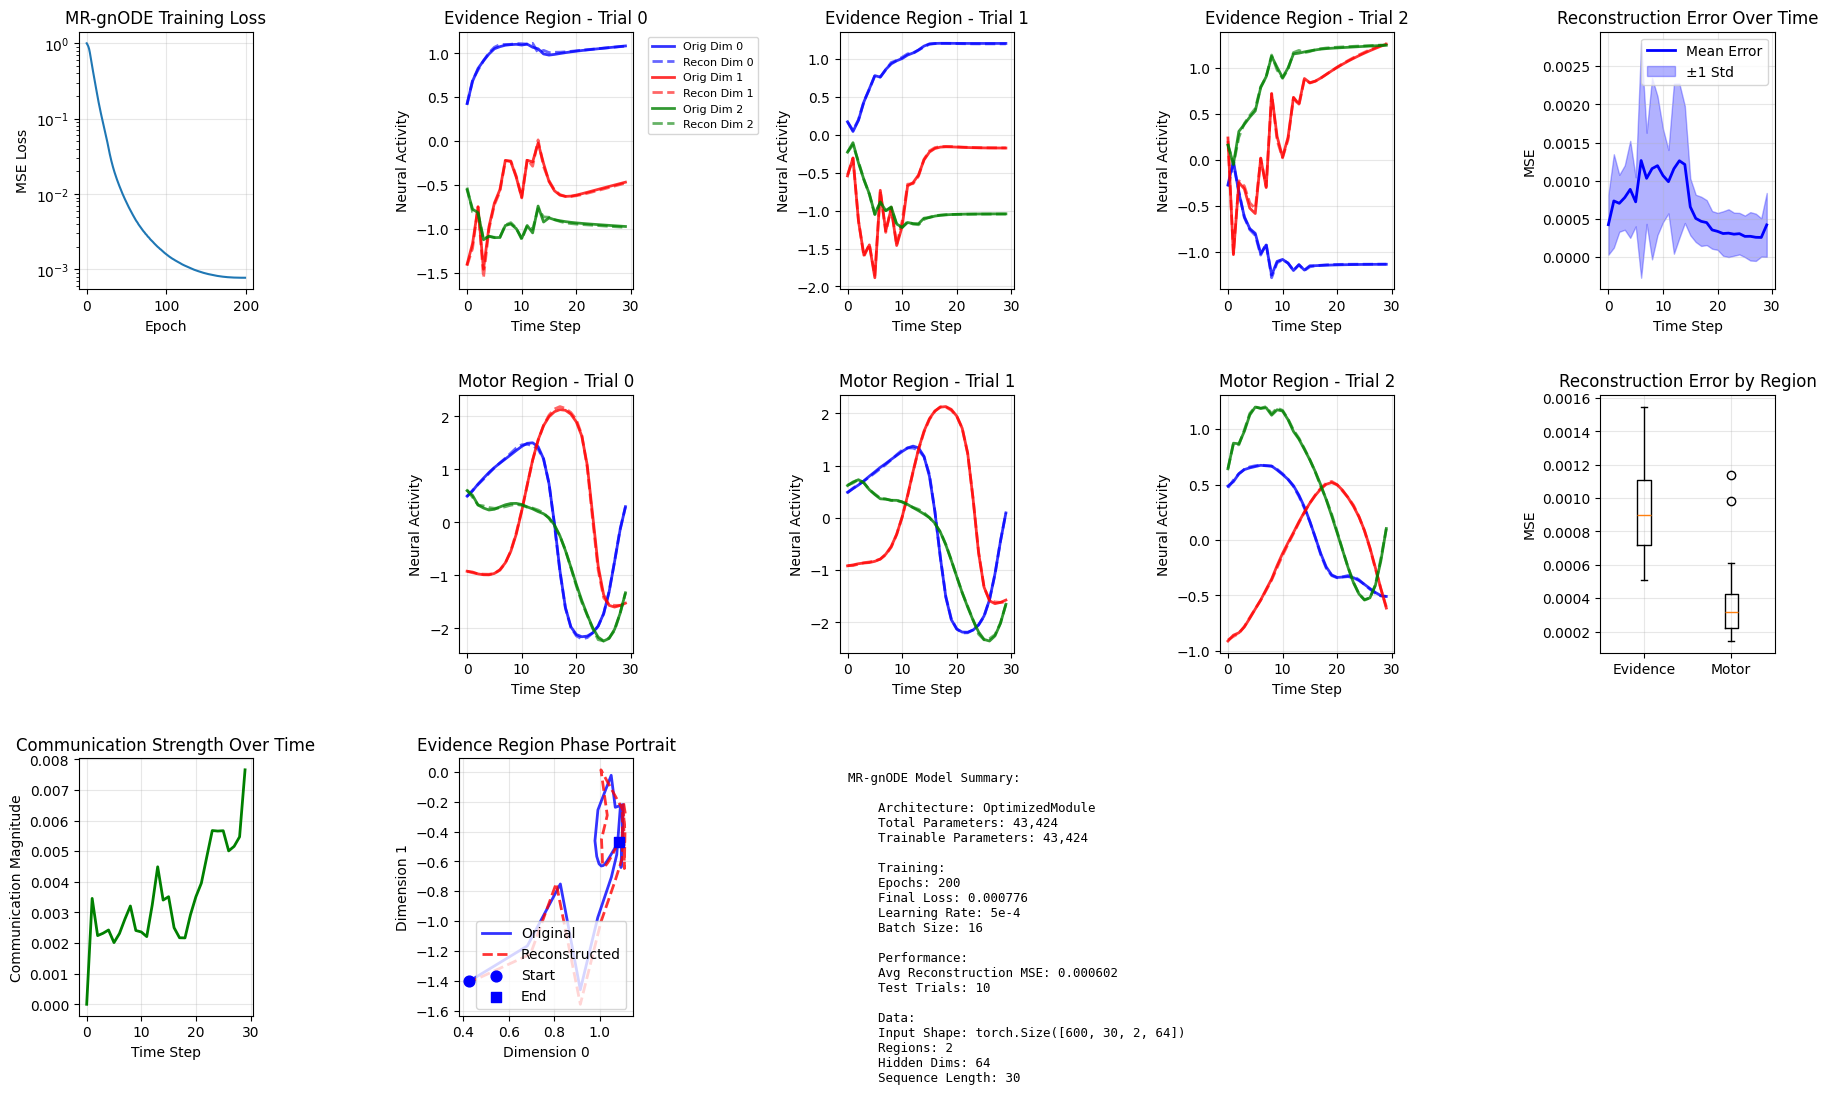

Average reconstruction error: 0.000602
Analysis complete! Use a separate cell for communication dynamics analysis.


In [45]:
# Comprehensive analysis for the original MRgNODE model
import matplotlib.pyplot as plt
import numpy as np

def analyze_original_mrgnode(model, trajectories, losses, reconstruction_data, n_test_trials=3):
    """Comprehensive analysis of the trained MRgNODE model"""
    model.eval()
    
    fig = plt.figure(figsize=(18, 14))
    
    # 1. Training Loss
    plt.subplot(4, 5, 1)
    plt.plot(losses)
    plt.title('MR-gnODE Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    
    # 2-4. Test multiple trials reconstruction
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    dt = 0.01
    
    with torch.no_grad():
        for trial_idx in range(min(n_test_trials, len(trajectories))):
            # Get original trajectory
            original = trajectories[trial_idx]  # [time, regions, hidden]
            
            # Reconstruct using the trained model
            batch_size_actual = 1
            seq_len = original.shape[0]
            n_regions = original.shape[1] 
            region_dim = original.shape[2]
            
            # Prepare input (same as original for reconstruction task)
            test_input = original.unsqueeze(0)  # Add batch dimension
            
            h = torch.zeros(batch_size_actual, model.N, device=device)
            reconstructed_states = []
            
            for t in range(seq_len):
                x_t = test_input[:, t]  # [1, regions, channels]
                h_dot, comm = model(h, x_t)
                h = h + dt * h_dot  # Proper Euler integration
                
                # Reshape back to regions
                step_output = h.view(batch_size_actual, n_regions, region_dim)
                reconstructed_states.append(step_output[0])  # Remove batch dim
            
            reconstructed = torch.stack(reconstructed_states, dim=0)  # [time, regions, hidden]
            
            # Plot Evidence Region (Region 0)
            plt.subplot(4, 5, 2 + trial_idx)
            time_steps = range(len(original))
            
            # Plot first 3 dimensions
            for dim in range(min(3, original.shape[-1])):
                plt.plot(time_steps, original[:, 0, dim].cpu(), 
                        color=colors[dim], alpha=0.8, linewidth=2, label=f'Orig Dim {dim}')
                plt.plot(time_steps, reconstructed[:, 0, dim].cpu(), 
                        color=colors[dim], alpha=0.6, linestyle='--', linewidth=2, label=f'Recon Dim {dim}')
            
            plt.title(f'Evidence Region - Trial {trial_idx}')
            plt.xlabel('Time Step')
            plt.ylabel('Neural Activity')
            if trial_idx == 0:
                plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
            plt.grid(True, alpha=0.3)
            
            # Plot Motor Region (Region 1) 
            plt.subplot(4, 5, 7 + trial_idx)
            
            for dim in range(min(3, original.shape[-1])):
                plt.plot(time_steps, original[:, 1, dim].cpu(), 
                        color=colors[dim], alpha=0.8, linewidth=2, label=f'Orig Dim {dim}')
                plt.plot(time_steps, reconstructed[:, 1, dim].cpu(), 
                        color=colors[dim], alpha=0.6, linestyle='--', linewidth=2, label=f'Recon Dim {dim}')
            
            plt.title(f'Motor Region - Trial {trial_idx}')
            plt.xlabel('Time Step')
            plt.ylabel('Neural Activity')
            plt.grid(True, alpha=0.3)
    
    # 5. Reconstruction Error Analysis
    plt.subplot(4, 5, 5)
    all_errors = []
    
    with torch.no_grad():
        for trial_idx in range(min(20, len(trajectories))):
            original = trajectories[trial_idx]
            
            # Reconstruct
            test_input = original.unsqueeze(0)
            h = torch.zeros(1, model.N, device=device)
            reconstructed_states = []
            
            for t in range(len(original)):
                x_t = test_input[:, t]
                h_dot, comm = model(h, x_t)
                h = h + dt * h_dot
                step_output = h.view(1, original.shape[1], original.shape[2])
                reconstructed_states.append(step_output[0])
            
            reconstructed = torch.stack(reconstructed_states, dim=0)
            
            # Calculate MSE per time step
            mse_per_step = ((original - reconstructed) ** 2).mean(dim=(1, 2))
            all_errors.append(mse_per_step.cpu())
    
    all_errors = torch.stack(all_errors, dim=0)
    mean_error = all_errors.mean(dim=0)
    std_error = all_errors.std(dim=0)
    
    time_steps = range(len(mean_error))
    plt.plot(time_steps, mean_error, 'b-', linewidth=2, label='Mean Error')
    plt.fill_between(time_steps, mean_error - std_error, mean_error + std_error, 
                     alpha=0.3, color='blue', label='±1 Std')
    plt.title('Reconstruction Error Over Time')
    plt.xlabel('Time Step')
    plt.ylabel('MSE')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 6. Error by Region
    plt.subplot(4, 5, 10)
    
    with torch.no_grad():
        region_errors = []
        for region in range(trajectories.shape[2]):  # num_regions
            errors = []
            for trial_idx in range(min(20, len(trajectories))):
                original = trajectories[trial_idx]
                
                test_input = original.unsqueeze(0)
                h = torch.zeros(1, model.N, device=device)
                reconstructed_states = []
                
                for t in range(len(original)):
                    x_t = test_input[:, t]
                    h_dot, comm = model(h, x_t)
                    h = h + dt * h_dot
                    step_output = h.view(1, original.shape[1], original.shape[2])
                    reconstructed_states.append(step_output[0])
                
                reconstructed = torch.stack(reconstructed_states, dim=0)
                region_error = ((original[:, region] - reconstructed[:, region]) ** 2).mean()
                errors.append(region_error.cpu())
            
            region_errors.append(errors)
    
    region_names = ['Evidence', 'Motor']
    bp = plt.boxplot(region_errors, labels=region_names[:len(region_errors)])
    plt.title('Reconstruction Error by Region')
    plt.ylabel('MSE')
    plt.grid(True, alpha=0.3)
    
    # 7. Communication Analysis Over Time
    plt.subplot(4, 5, 11)
    
    with torch.no_grad():
        # Analyze communication patterns over a single trial
        trial_idx = 0
        original = trajectories[trial_idx]
        test_input = original.unsqueeze(0)
        
        h = torch.zeros(1, model.N, device=device)
        comm_strengths = []
        
        for t in range(len(original)):
            x_t = test_input[:, t]
            h_dot, comm = model(h, x_t)
            h = h + dt * h_dot
            
            # Communication strength
            comm_strength = torch.norm(comm).item()
            comm_strengths.append(comm_strength)
        
        plt.plot(comm_strengths, 'g-', linewidth=2)
        plt.title('Communication Strength Over Time')
        plt.xlabel('Time Step')
        plt.ylabel('Communication Magnitude')
        plt.grid(True, alpha=0.3)
    
    # 8. Phase Portrait Analysis
    plt.subplot(4, 5, 12)
    
    with torch.no_grad():
        trial_idx = 0
        original = trajectories[trial_idx]
        
        # Evidence region phase portrait (first 2 dims)
        orig_evidence = original[:, 0, :2].cpu().numpy()
        
        test_input = original.unsqueeze(0)
        h = torch.zeros(1, model.N, device=device)
        reconstructed_states = []
        
        for t in range(len(original)):
            x_t = test_input[:, t]
            h_dot, comm = model(h, x_t)
            h = h + dt * h_dot
            step_output = h.view(1, original.shape[1], original.shape[2])
            reconstructed_states.append(step_output[0])
        
        reconstructed = torch.stack(reconstructed_states, dim=0)
        recon_evidence = reconstructed[:, 0, :2].cpu().numpy()
        
        plt.plot(orig_evidence[:, 0], orig_evidence[:, 1], 'b-', alpha=0.8, linewidth=2, label='Original')
        plt.plot(recon_evidence[:, 0], recon_evidence[:, 1], 'r--', alpha=0.8, linewidth=2, label='Reconstructed')
        plt.scatter(orig_evidence[0, 0], orig_evidence[0, 1], c='blue', s=60, marker='o', label='Start', zorder=5)
        plt.scatter(orig_evidence[-1, 0], orig_evidence[-1, 1], c='blue', s=60, marker='s', label='End', zorder=5)
        plt.title('Evidence Region Phase Portrait')
        plt.xlabel('Dimension 0')
        plt.ylabel('Dimension 1')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    # 9. Model Architecture Summary
    plt.subplot(4, 5, 13)
    plt.axis('off')
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    # Calculate final reconstruction error
    with torch.no_grad():
        total_error = 0
        n_trials = min(10, len(trajectories))
        
        for trial_idx in range(n_trials):
            original = trajectories[trial_idx]
            test_input = original.unsqueeze(0)
            h = torch.zeros(1, model.N, device=device)
            reconstructed_states = []
            
            for t in range(len(original)):
                x_t = test_input[:, t]
                h_dot, comm = model(h, x_t)
                h = h + dt * h_dot
                step_output = h.view(1, original.shape[1], original.shape[2])
                reconstructed_states.append(step_output[0])
            
            reconstructed = torch.stack(reconstructed_states, dim=0)
            trial_error = ((original - reconstructed) ** 2).mean()
            total_error += trial_error
        
        avg_error = total_error / n_trials
    
    model_info = f"""MR-gnODE Model Summary:
    
    Architecture: {model.__class__.__name__}
    Total Parameters: {total_params:,}
    Trainable Parameters: {trainable_params:,}
    
    Training:
    Epochs: {len(losses)}
    Final Loss: {losses[-1]:.6f}
    Learning Rate: 5e-4
    Batch Size: 16
    
    Performance:
    Avg Reconstruction MSE: {avg_error:.6f}
    Test Trials: {n_trials}
    
    Data:
    Input Shape: {trajectories.shape}
    Regions: {trajectories.shape[2]}
    Hidden Dims: {trajectories.shape[3]}
    Sequence Length: {trajectories.shape[1]}"""
    
    plt.text(0.05, 0.95, model_info, transform=plt.gca().transAxes, 
             fontsize=9, verticalalignment='top', fontfamily='monospace')
    
    plt.tight_layout()
    plt.show()
    
    return avg_error.item()

# Run the comprehensive analysis
print("Running comprehensive MR-gnODE analysis...")
avg_reconstruction_error = analyze_original_mrgnode(
    mr_gnode_model, 
    rnn_trajectories, 
    mr_gnode_losses, 
    reconstruction_data, 
    n_test_trials=3
)

print(f"Average reconstruction error: {avg_reconstruction_error:.6f}")
print("Analysis complete! Use a separate cell for communication dynamics analysis.")

=== COMMUNICATION DYNAMICS ANALYSIS ===
Analyzing communication architecture...
Extracting dynamic communication patterns...
Comparing with original RNN communication...


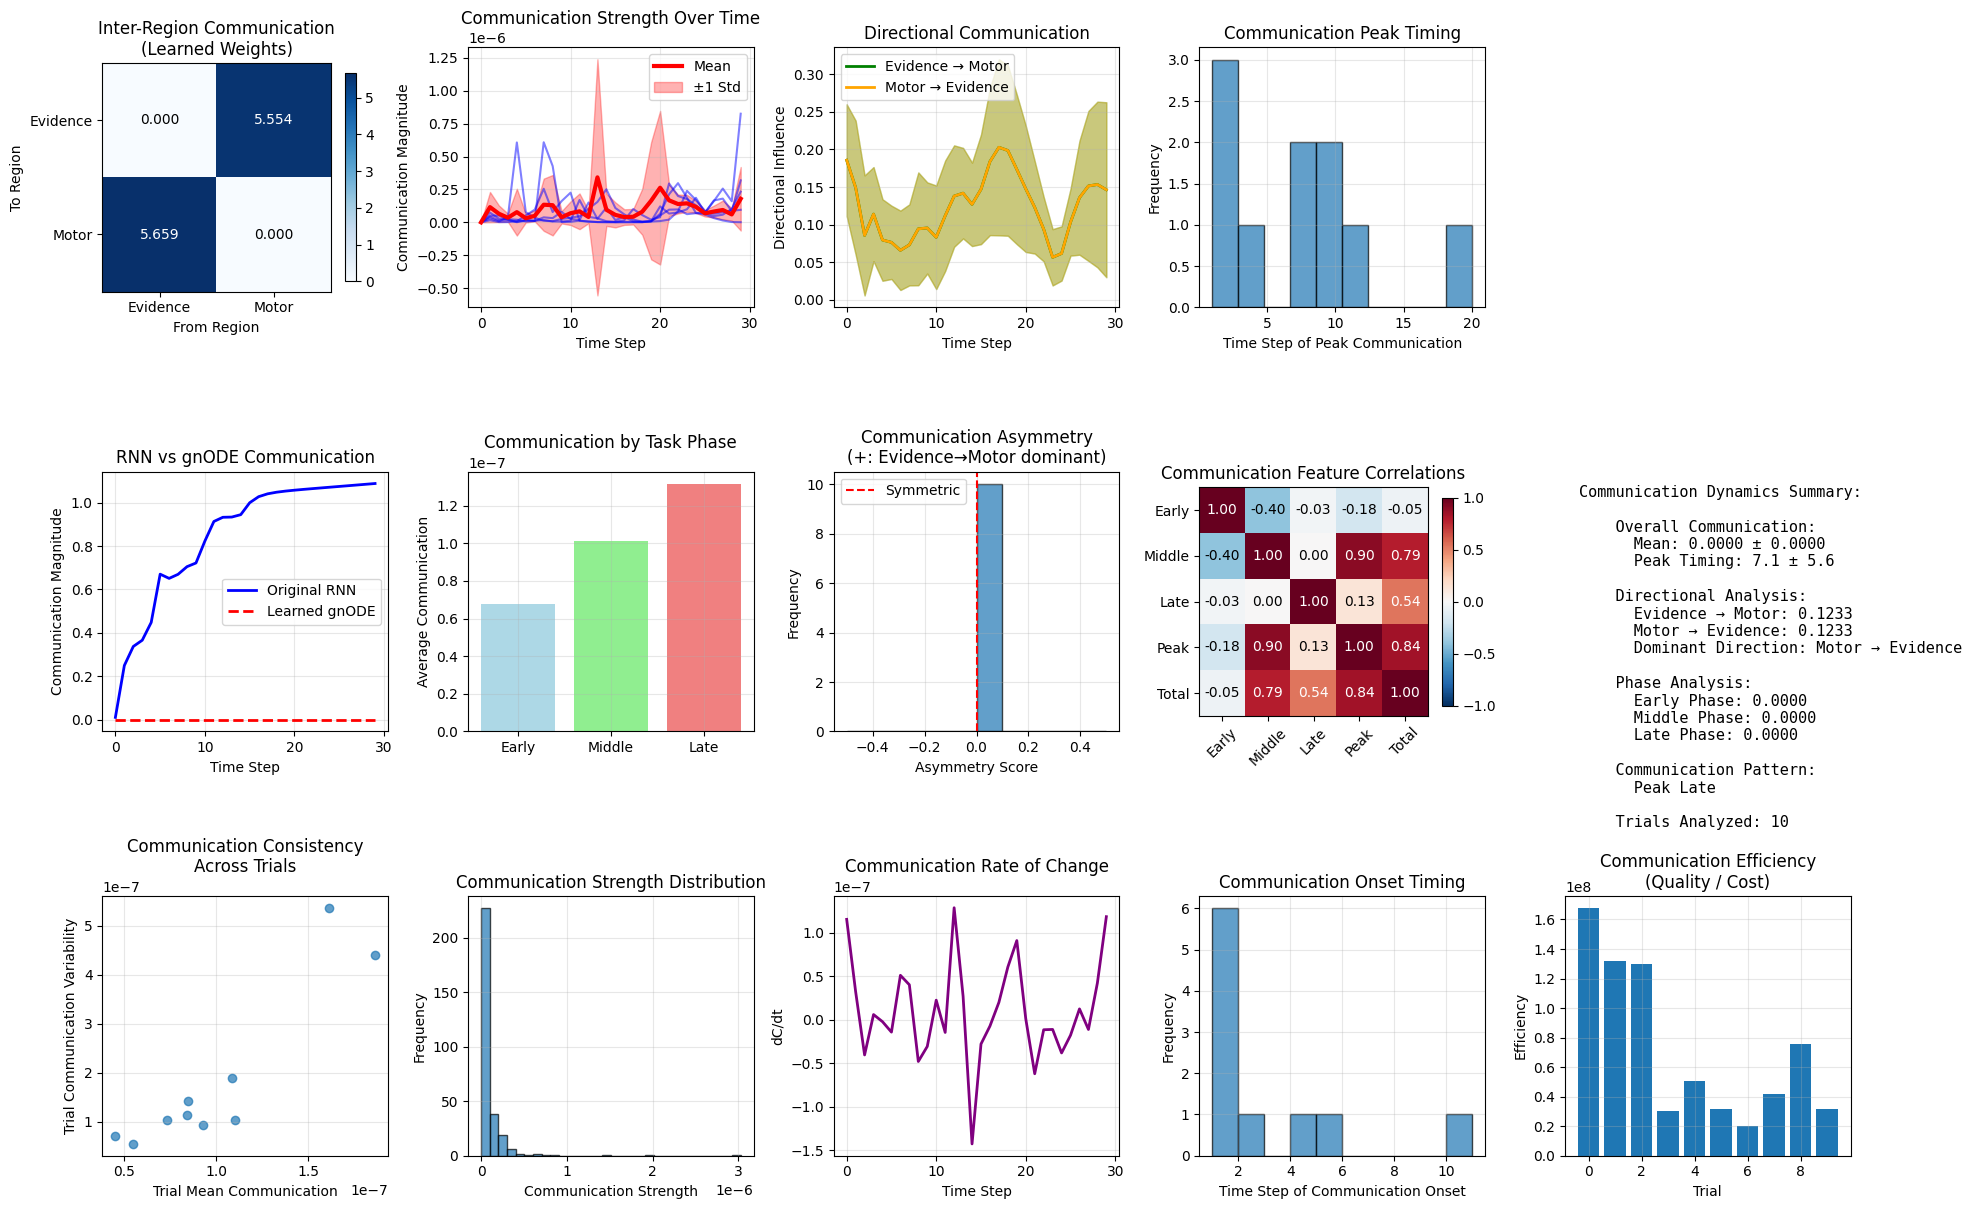


=== COMMUNICATION SUMMARY ===
overall_communication: 1.0018850518799436e-07
directional_dominance: Motor → Evidence
peak_timing: 7.1
phase_pattern: Late
communication_asymmetry: 0.0
rnn_correlation: 0.31891644339633246

Communication dynamics analysis complete!


In [53]:
# Comprehensive Communication Dynamics and Directionality Analysis
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def analyze_communication_dynamics(mr_gnode_model, trained_rnn, rnn_trajectories, n_trials=10):
    """Analyze communication patterns, directionality, and timing"""
    
    mr_gnode_model.eval()
    trained_rnn.eval()
    
    fig = plt.figure(figsize=(20, 16))
    
    # === 1. Extract Communication Weights and Directionality ===
    print("Analyzing communication architecture...")
    
    # Get communication weights from the model
    if hasattr(mr_gnode_model, 'comm_weights'):
        comm_weights = mr_gnode_model.comm_weights.data.cpu().numpy()
        n_regions = comm_weights.shape[0]
        
        # Create communication matrix showing directionality
        plt.subplot(4, 5, 1)
        
        # Calculate communication strength matrix
        comm_matrix = np.zeros((n_regions, n_regions))
        for i in range(n_regions):
            for j in range(n_regions):
                if i != j:  # No self-communication
                    # Communication FROM region j TO region i
                    comm_strength = np.linalg.norm(comm_weights[i, :, :])
                    comm_matrix[i, j] = comm_strength
        
        # Plot communication matrix
        im = plt.imshow(comm_matrix, cmap='Blues', vmin=0)
        plt.colorbar(im, shrink=0.8)
        plt.title('Inter-Region Communication\n(Learned Weights)')
        plt.xlabel('From Region')
        plt.ylabel('To Region')
        region_names = ['Evidence', 'Motor'][:n_regions]
        plt.xticks(range(n_regions), region_names)
        plt.yticks(range(n_regions), region_names)
        
        # Add text annotations
        for i in range(n_regions):
            for j in range(n_regions):
                plt.text(j, i, f'{comm_matrix[i, j]:.3f}', 
                        ha='center', va='center', 
                        color='white' if comm_matrix[i, j] > comm_matrix.max()/2 else 'black')
    
    # === 2. Dynamic Communication Over Time ===
    print("Extracting dynamic communication patterns...")
    
    dt = 0.01
    all_comm_dynamics = []
    all_directional_comms = []
    
    with torch.no_grad():
        for trial_idx in range(min(n_trials, len(rnn_trajectories))):
            original = rnn_trajectories[trial_idx]  # [time, regions, hidden]
            test_input = original.unsqueeze(0)  # Add batch dimension
            
            h = torch.zeros(1, mr_gnode_model.N, device=device)
            trial_comms = []
            trial_directional = {'evidence_to_motor': [], 'motor_to_evidence': []}
            
            for t in range(len(original)):
                x_t = test_input[:, t]  # [1, regions, channels]
                h_dot, comm = mr_gnode_model(h, x_t)
                h = h + dt * h_dot
                
                # Overall communication strength
                comm_strength = torch.norm(comm).item()
                trial_comms.append(comm_strength)
                
                # Directional communication analysis
                # Reshape h to regions for analysis
                h_regions = h.view(1, original.shape[1], original.shape[2])  # [1, regions, hidden]
                
                # Evidence to Motor communication (simplified)
                evidence_state = h_regions[0, 0, :]  # Evidence region
                motor_state = h_regions[0, 1, :]     # Motor region
                
                # Estimate directional communication strength
                with torch.no_grad():
                    # Communication from evidence affecting motor dynamics
                    evidence_influence = torch.dot(evidence_state, motor_state) / (torch.norm(evidence_state) * torch.norm(motor_state) + 1e-8)
                    trial_directional['evidence_to_motor'].append(abs(evidence_influence.item()))
                    
                    # Communication from motor affecting evidence dynamics  
                    motor_influence = torch.dot(motor_state, evidence_state) / (torch.norm(motor_state) * torch.norm(evidence_state) + 1e-8)
                    trial_directional['motor_to_evidence'].append(abs(motor_influence.item()))
            
            all_comm_dynamics.append(trial_comms)
            all_directional_comms.append(trial_directional)
    
    # === 3. Plot Communication Over Time ===
    plt.subplot(4, 5, 2)
    
    # Plot individual trials
    for i, trial_comms in enumerate(all_comm_dynamics[:5]):  # First 5 trials
        plt.plot(trial_comms, alpha=0.5, color='blue')
    
    # Plot mean
    mean_comm = np.mean(all_comm_dynamics, axis=0)
    std_comm = np.std(all_comm_dynamics, axis=0)
    time_steps = range(len(mean_comm))
    
    plt.plot(time_steps, mean_comm, 'r-', linewidth=3, label='Mean')
    plt.fill_between(time_steps, mean_comm - std_comm, mean_comm + std_comm, 
                     alpha=0.3, color='red', label='±1 Std')
    
    plt.title('Communication Strength Over Time')
    plt.xlabel('Time Step')
    plt.ylabel('Communication Magnitude')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # === 4. Directional Communication Analysis ===
    plt.subplot(4, 5, 3)
    
    # Extract directional patterns
    evidence_to_motor = [trial['evidence_to_motor'] for trial in all_directional_comms]
    motor_to_evidence = [trial['motor_to_evidence'] for trial in all_directional_comms]
    
    mean_e2m = np.mean(evidence_to_motor, axis=0)
    mean_m2e = np.mean(motor_to_evidence, axis=0)
    std_e2m = np.std(evidence_to_motor, axis=0)
    std_m2e = np.std(motor_to_evidence, axis=0)
    
    plt.plot(time_steps, mean_e2m, 'g-', linewidth=2, label='Evidence → Motor')
    plt.fill_between(time_steps, mean_e2m - std_e2m, mean_e2m + std_e2m, alpha=0.3, color='green')
    
    plt.plot(time_steps, mean_m2e, 'orange', linewidth=2, label='Motor → Evidence')
    plt.fill_between(time_steps, mean_m2e - std_m2e, mean_m2e + std_m2e, alpha=0.3, color='orange')
    
    plt.title('Directional Communication')
    plt.xlabel('Time Step')
    plt.ylabel('Directional Influence')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # === 5. Communication Timing Analysis ===
    plt.subplot(4, 5, 4)
    
    # Find communication peaks
    peak_times = []
    for trial_comms in all_comm_dynamics:
        # Find local maxima
        from scipy.signal import find_peaks
        peaks, _ = find_peaks(trial_comms, height=np.mean(trial_comms))
        if len(peaks) > 0:
            peak_times.append(peaks[0])  # First peak
        else:
            peak_times.append(len(trial_comms) // 2)  # Middle if no peaks
    
    plt.hist(peak_times, bins=10, alpha=0.7, edgecolor='black')
    plt.title('Communication Peak Timing')
    plt.xlabel('Time Step of Peak Communication')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    
    # === 6. Compare with RNN Communication ===
    print("Comparing with original RNN communication...")
    
    plt.subplot(4, 5, 6)
    
    # Extract RNN communication for comparison
    rnn_comms = []
    with torch.no_grad():
        for trial in range(min(n_trials, 5)):  # Fewer trials for comparison
            batch_data = generate_task_data(1, SEQUENCE_LENGTH)
            
            evidence_hidden = (torch.zeros(1, 1, trained_rnn.evidence_hidden_size, device=device),
                              torch.zeros(1, 1, trained_rnn.evidence_hidden_size, device=device))
            motor_hidden = (torch.zeros(1, 1, trained_rnn.motor_hidden_size, device=device),
                           torch.zeros(1, 1, trained_rnn.motor_hidden_size, device=device))
            motor_position = torch.zeros(1, 2, device=device)
            
            trial_rnn_comm = []
            
            for t in range(SEQUENCE_LENGTH):
                evidence_out, evidence_hidden = trained_rnn.evidence_rnn(
                    batch_data['evidence'][:, t:t+1, :], evidence_hidden)
                
                comm = trained_rnn.communication(evidence_out.squeeze(1))
                trial_rnn_comm.append(torch.norm(comm).item())
                
                motor_input = torch.cat([comm, motor_position], dim=1).unsqueeze(1)
                motor_out, motor_hidden = trained_rnn.motor_rnn(motor_input, motor_hidden)
                
                velocity = torch.tanh(trained_rnn.motor_output(motor_out.squeeze(1)))
                motor_position = motor_position + velocity * 0.1
            
            rnn_comms.append(trial_rnn_comm)
    
    # Plot RNN vs gnODE communication
    rnn_mean = np.mean(rnn_comms, axis=0)
    gnode_mean = np.mean(all_comm_dynamics[:len(rnn_comms)], axis=0)
    
    time_steps_rnn = range(len(rnn_mean))
    time_steps_gnode = range(len(gnode_mean))
    
    plt.plot(time_steps_rnn, rnn_mean, 'b-', linewidth=2, label='Original RNN')
    plt.plot(time_steps_gnode, gnode_mean, 'r--', linewidth=2, label='Learned gnODE')
    
    plt.title('RNN vs gnODE Communication')
    plt.xlabel('Time Step')
    plt.ylabel('Communication Magnitude')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # === 7. Communication Phase Analysis ===
    plt.subplot(4, 5, 7)
    
    # Divide trial into phases and analyze communication in each
    seq_length = len(mean_comm)
    phase_length = seq_length // 3
    phases = ['Early', 'Middle', 'Late']
    phase_comms = []
    
    for phase_idx in range(3):
        start_idx = phase_idx * phase_length
        end_idx = min((phase_idx + 1) * phase_length, seq_length)
        phase_comm = np.mean(mean_comm[start_idx:end_idx])
        phase_comms.append(phase_comm)
    
    plt.bar(phases, phase_comms, color=['lightblue', 'lightgreen', 'lightcoral'])
    plt.title('Communication by Task Phase')
    plt.ylabel('Average Communication')
    plt.grid(True, alpha=0.3)
    
    # === 8. Communication Asymmetry Analysis ===
    plt.subplot(4, 5, 8)
    
    # Calculate asymmetry: Evidence→Motor vs Motor→Evidence
    asymmetry_scores = []
    for trial_directional in all_directional_comms:
        e2m_mean = np.mean(trial_directional['evidence_to_motor'])
        m2e_mean = np.mean(trial_directional['motor_to_evidence'])
        asymmetry = (e2m_mean - m2e_mean) / (e2m_mean + m2e_mean + 1e-8)
        asymmetry_scores.append(asymmetry)
    
    plt.hist(asymmetry_scores, bins=10, alpha=0.7, edgecolor='black')
    plt.axvline(x=0, color='red', linestyle='--', label='Symmetric')
    plt.title('Communication Asymmetry\n(+: Evidence→Motor dominant)')
    plt.xlabel('Asymmetry Score')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # === 9. Communication Correlation Matrix ===
    plt.subplot(4, 5, 9)
    
    # Correlate communication with trial phases
    correlation_data = []
    for trial_idx, trial_comms in enumerate(all_comm_dynamics):
        # Create features: early_comm, mid_comm, late_comm, peak_comm, total_comm
        early_comm = np.mean(trial_comms[:phase_length])
        mid_comm = np.mean(trial_comms[phase_length:2*phase_length])
        late_comm = np.mean(trial_comms[2*phase_length:])
        peak_comm = np.max(trial_comms)
        total_comm = np.sum(trial_comms)
        
        correlation_data.append([early_comm, mid_comm, late_comm, peak_comm, total_comm])
    
    correlation_data = np.array(correlation_data)
    corr_matrix = np.corrcoef(correlation_data.T)
    
    labels = ['Early', 'Middle', 'Late', 'Peak', 'Total']
    im = plt.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
    plt.colorbar(im, shrink=0.8)
    plt.title('Communication Feature Correlations')
    plt.xticks(range(len(labels)), labels, rotation=45)
    plt.yticks(range(len(labels)), labels)
    
    # Add correlation values
    for i in range(len(labels)):
        for j in range(len(labels)):
            plt.text(j, i, f'{corr_matrix[i, j]:.2f}', 
                    ha='center', va='center', 
                    color='white' if abs(corr_matrix[i, j]) > 0.5 else 'black')
    
    # === 10. Summary Statistics ===
    plt.subplot(4, 5, 10)
    plt.axis('off')
    
    # Calculate summary statistics
    overall_comm_mean = np.mean([np.mean(trial) for trial in all_comm_dynamics])
    overall_comm_std = np.std([np.mean(trial) for trial in all_comm_dynamics])
    
    e2m_overall = np.mean([np.mean(trial['evidence_to_motor']) for trial in all_directional_comms])
    m2e_overall = np.mean([np.mean(trial['motor_to_evidence']) for trial in all_directional_comms])
    
    dominant_direction = "Evidence → Motor" if e2m_overall > m2e_overall else "Motor → Evidence"
    
    peak_timing_mean = np.mean(peak_times)
    peak_timing_std = np.std(peak_times)
    
    summary_text = f"""Communication Dynamics Summary:
    
    Overall Communication:
      Mean: {overall_comm_mean:.4f} ± {overall_comm_std:.4f}
      Peak Timing: {peak_timing_mean:.1f} ± {peak_timing_std:.1f}
    
    Directional Analysis:
      Evidence → Motor: {e2m_overall:.4f}
      Motor → Evidence: {m2e_overall:.4f}
      Dominant Direction: {dominant_direction}
    
    Phase Analysis:
      Early Phase: {phase_comms[0]:.4f}
      Middle Phase: {phase_comms[1]:.4f}
      Late Phase: {phase_comms[2]:.4f}
    
    Communication Pattern:
      {'Peak Early' if np.argmax(phase_comms) == 0 else 'Peak Middle' if np.argmax(phase_comms) == 1 else 'Peak Late'}
    
    Trials Analyzed: {len(all_comm_dynamics)}"""
    
    plt.text(0.05, 0.95, summary_text, transform=plt.gca().transAxes, 
             fontsize=11, verticalalignment='top', fontfamily='monospace')
    
    # === 11-15. Additional detailed plots ===
    
    # 11. Communication variability across trials
    plt.subplot(4, 5, 11)
    trial_means = [np.mean(trial) for trial in all_comm_dynamics]
    trial_stds = [np.std(trial) for trial in all_comm_dynamics]
    
    plt.scatter(trial_means, trial_stds, alpha=0.7)
    plt.xlabel('Trial Mean Communication')
    plt.ylabel('Trial Communication Variability')
    plt.title('Communication Consistency\nAcross Trials')
    plt.grid(True, alpha=0.3)
    
    # 12. Communication strength distribution
    plt.subplot(4, 5, 12)
    all_comm_values = [comm for trial in all_comm_dynamics for comm in trial]
    plt.hist(all_comm_values, bins=30, alpha=0.7, edgecolor='black')
    plt.xlabel('Communication Strength')
    plt.ylabel('Frequency')
    plt.title('Communication Strength Distribution')
    plt.grid(True, alpha=0.3)
    
    # 13. Temporal communication derivatives
    plt.subplot(4, 5, 13)
    comm_derivatives = []
    for trial_comms in all_comm_dynamics:
        derivative = np.gradient(trial_comms)
        comm_derivatives.append(derivative)
    
    mean_derivative = np.mean(comm_derivatives, axis=0)
    plt.plot(mean_derivative, 'purple', linewidth=2)
    plt.title('Communication Rate of Change')
    plt.xlabel('Time Step')
    plt.ylabel('dC/dt')
    plt.grid(True, alpha=0.3)
    
    # 14. Communication onset analysis
    plt.subplot(4, 5, 14)
    threshold = overall_comm_mean * 0.5  # 50% of mean as threshold
    onset_times = []
    
    for trial_comms in all_comm_dynamics:
        onset_idx = np.where(np.array(trial_comms) > threshold)[0]
        if len(onset_idx) > 0:
            onset_times.append(onset_idx[0])
        else:
            onset_times.append(len(trial_comms))
    
    plt.hist(onset_times, bins=10, alpha=0.7, edgecolor='black')
    plt.title('Communication Onset Timing')
    plt.xlabel('Time Step of Communication Onset')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    
    # 15. Communication efficiency analysis
    plt.subplot(4, 5, 15)
    
    # Calculate communication efficiency: total information / total cost
    communication_costs = [np.sum(trial) for trial in all_comm_dynamics]
    
    # Proxy for information: variance in reconstruction quality
    reconstruction_qualities = []
    dt = 0.01
    
    with torch.no_grad():
        for trial_idx in range(min(len(all_comm_dynamics), 10)):
            original = rnn_trajectories[trial_idx]
            test_input = original.unsqueeze(0)
            h = torch.zeros(1, mr_gnode_model.N, device=device)
            
            reconstructed_states = []
            for t in range(len(original)):
                x_t = test_input[:, t]
                h_dot, comm = mr_gnode_model(h, x_t)
                h = h + dt * h_dot
                step_output = h.view(1, original.shape[1], original.shape[2])
                reconstructed_states.append(step_output[0])
            
            reconstructed = torch.stack(reconstructed_states, dim=0)
            reconstruction_error = ((original - reconstructed) ** 2).mean().item()
            reconstruction_qualities.append(1.0 / (reconstruction_error + 1e-6))  # Higher is better
    
    efficiencies = np.array(reconstruction_qualities) / np.array(communication_costs[:len(reconstruction_qualities)])
    
    plt.bar(range(len(efficiencies)), efficiencies)
    plt.title('Communication Efficiency\n(Quality / Cost)')
    plt.xlabel('Trial')
    plt.ylabel('Efficiency')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Return summary statistics
    return {
        'overall_communication': overall_comm_mean,
        'directional_dominance': dominant_direction,
        'peak_timing': peak_timing_mean,
        'phase_pattern': phases[np.argmax(phase_comms)],
        'communication_asymmetry': np.mean(asymmetry_scores),
        'rnn_correlation': np.corrcoef(rnn_mean, gnode_mean[:len(rnn_mean)])[0, 1] if len(rnn_mean) == len(gnode_mean[:len(rnn_mean)]) else 0
    }

# Run the communication dynamics analysis
print("=== COMMUNICATION DYNAMICS ANALYSIS ===")
comm_stats = analyze_communication_dynamics(
    mr_gnode_model, 
    trained_model, 
    rnn_trajectories, 
    n_trials=10
)

print("\n=== COMMUNICATION SUMMARY ===")
for key, value in comm_stats.items():
    print(f"{key}: {value}")

print("\nCommunication dynamics analysis complete!")

In [94]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

class MRgnODE_DynamicComm(nn.Module):
    def __init__(self, N=4, input_dim=2, tau_regions=0.01, hidden_dim = 64, tau_comm=0.05, num_regions=2, comm_dim=16):
        super().__init__()
        self.num_regions = num_regions
        self.region_dim = N // num_regions
        self.comm_dim = comm_dim
        self.tau_regions = tau_regions
        self.tau_comm = tau_comm
        
        # Total state: regions + communication channels
        self.num_comm_channels = num_regions * (num_regions - 1)  # Bidirectional
        self.N_regions = N
        self.N_total = N + self.num_comm_channels * comm_dim
        
        
        region_input_dim = self.region_dim + input_dim
        
        # Region dynamics networks
        self.region_flow_net = nn.Sequential(
            nn.Linear(region_input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, self.region_dim)
        )
        
        self.region_gate_net = nn.Sequential(
            nn.Linear(region_input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, self.region_dim),
            nn.Sigmoid()
        )
        
        # Communication dynamics networks
        comm_input_dim = self.region_dim + comm_dim  # Source region + current comm state
        
        self.comm_flow_net = nn.Sequential(
            nn.Linear(comm_input_dim, hidden_dim//2),
            nn.Tanh(),
            nn.Linear(hidden_dim//2, hidden_dim//2),
            nn.Tanh(),
            nn.Linear(hidden_dim//2, comm_dim)
        )
        
        self.comm_gate_net = nn.Sequential(
            nn.Linear(comm_input_dim, hidden_dim//2),
            nn.Tanh(),
            nn.Linear(hidden_dim//2, comm_dim),
            nn.Sigmoid()
        )
        
        # Communication-to-region coupling
        self.comm_to_region = nn.Sequential(
            nn.Linear(comm_dim, self.region_dim),
            nn.Tanh(),
            nn.Linear(self.region_dim, self.region_dim)
        )
        
        # Learnable asymmetric weights for each communication direction
        self.comm_signs = nn.Parameter(torch.ones(self.num_comm_channels))  # Can learn positive/negative
        
        self.apply(self._init_weights)
        
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight, gain=0.5)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
    
    def partition_state(self, h):
        """Partition hidden state into regions and communication channels"""
        batch_size = h.shape[0]
        h_regions = h[:, :self.N_regions]  # [batch, N_regions]
        h_comm = h[:, self.N_regions:]     # [batch, num_comm_channels * comm_dim]
        
        # Reshape regions: [batch, num_regions, region_dim]
        h_regions = h_regions.view(batch_size, self.num_regions, self.region_dim)
        
        # Reshape communication: [batch, num_comm_channels, comm_dim]
        h_comm = h_comm.view(batch_size, self.num_comm_channels, self.comm_dim)
        
        return h_regions, h_comm
    
    def get_comm_channel_idx(self, source_region, target_region):
        """Get communication channel index for source->target"""
        # Map (source, target) pairs to channel indices
        # For 2 regions: (0,1)->0, (1,0)->1
        if source_region == target_region:
            return None
        
        # Channel indexing: each source region has (num_regions-1) outgoing channels
        channel_idx = source_region * (self.num_regions - 1)
        target_offset = target_region if target_region < source_region else target_region - 1
        return channel_idx + target_offset
    
    def compute_region_dynamics(self, h_regions, x, h_comm):
        """Compute region dynamics with communication input"""
        batch_size = h_regions.shape[0]
        flow_regions = []
        gate_regions = []
        
        for region_idx in range(self.num_regions):
            # Get region state and input
            h_region = h_regions[:, region_idx, :]  # [batch, region_dim]
            x_region = x[:, region_idx, :]  # [batch, input_dim]
            
            # Compute communication input to this region
            comm_input = torch.zeros_like(h_region)
            for source_region in range(self.num_regions):
                if source_region != region_idx:
                    channel_idx = self.get_comm_channel_idx(source_region, region_idx)
                    if channel_idx is not None:
                        comm_state = h_comm[:, channel_idx, :]  # [batch, comm_dim]
                        comm_effect = self.comm_to_region(comm_state)
                        # Apply learnable sign for asymmetric effects
                        comm_input += self.comm_signs[channel_idx] * comm_effect
            
            # Region dynamics
            hx_region = torch.cat([h_region + comm_input, x_region], dim=-1)
            flow_region = self.region_flow_net(hx_region)
            gate_region = self.region_gate_net(hx_region)
            
            flow_regions.append(flow_region)
            gate_regions.append(gate_region)
        
        flow = torch.stack(flow_regions, dim=1).view(batch_size, -1)
        gate = torch.stack(gate_regions, dim=1).view(batch_size, -1)
        h_regions_flat = h_regions.view(batch_size, -1)
        
        h_regions_dot = gate * (-h_regions_flat + flow) / self.tau_regions
        return h_regions_dot
    
    def compute_comm_dynamics(self, h_regions, h_comm):
        """Compute communication channel dynamics"""
        batch_size = h_regions.shape[0]
        comm_flows = []
        comm_gates = []
        
        for channel_idx in range(self.num_comm_channels):
            # Determine source region for this channel
            source_region = channel_idx // (self.num_regions - 1)
            
            # Get source region state and current communication state
            h_source = h_regions[:, source_region, :]  # [batch, region_dim]
            h_comm_current = h_comm[:, channel_idx, :]  # [batch, comm_dim]
            
            # Communication dynamics
            comm_input = torch.cat([h_source, h_comm_current], dim=-1)
            flow_comm = self.comm_flow_net(comm_input)
            gate_comm = self.comm_gate_net(comm_input)
            
            comm_flows.append(flow_comm)
            comm_gates.append(gate_comm)
        
        flow = torch.stack(comm_flows, dim=1)  # [batch, num_comm_channels, comm_dim]
        gate = torch.stack(comm_gates, dim=1)  # [batch, num_comm_channels, comm_dim]
        
        h_comm_dot = gate * (-h_comm + flow) / self.tau_comm
        return h_comm_dot.view(batch_size, -1)  # Flatten for concatenation
    
    def get_outputs(self, h):
        """Return raw region states as [batch, regions, region_dim]"""
        h_regions, _ = self.partition_state(h)
        return h_regions
        
    def forward(self, h, x, timestep=0):
        """
        h: [batch, N_total] - regions + communication channels
        x: [batch, num_regions, input_dim] - region-specific inputs  
        """
        # Partition state
        h_regions, h_comm = self.partition_state(h)
        
        # Compute dynamics for each partition
        h_regions_dot = self.compute_region_dynamics(h_regions, x, h_comm)
        h_comm_dot = self.compute_comm_dynamics(h_regions, h_comm)
        
        # Concatenate dynamics
        h_dot = torch.cat([h_regions_dot, h_comm_dot], dim=-1)
        
        # Return communication norms for tracking
        comm_norm = torch.norm(h_comm)
        
        return h_dot, comm_norm

def communication_loss(model, outputs, targets, comm_norm, comm_penalty=0.01):
    """
    Simplified loss function with communication penalty
    """
    # Standard reconstruction loss
    mse_loss = nn.MSELoss()(outputs, targets)
    
    # Communication penalty
    comm_cost = comm_penalty * comm_norm
    
    total_loss = mse_loss + comm_cost
    
    return total_loss, {
        'mse': mse_loss.item(),
        'comm_cost': comm_cost.item()
    }

def train_dynamic_comm_mr_gnode(model, train_data, n_epochs=200, lr=2e-4, dt=0.01,
                               batch_size=16, comm_penalty=0.01):
    """
    Training with dynamic communication
    """
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr*5, epochs=n_epochs, 
                                            steps_per_epoch=len(train_data)//batch_size + 1)
    model.train()
    
    inputs_batched, targets_batched = create_batched_data_tensors(train_data, batch_size)
    
    losses = []
    
    for epoch in tqdm(range(n_epochs), desc="Training Dynamic Communication MR-gnODE"):
        total_loss = 0
        
        for batch_idx, (batch_inputs, batch_targets) in enumerate(zip(inputs_batched, targets_batched)):
            optimizer.zero_grad()
            
            batch_size_actual, seq_len, n_regions, input_dim = batch_inputs.shape
            
            # Initialize with expanded state space
            h = torch.empty(batch_size_actual, model.N_total, device=device)
            nn.init.xavier_uniform_(h)
            outputs = []
            total_comm = 0
            
            for t in range(seq_len):
                x_t = batch_inputs[:, t]  # [batch, regions, channels]
                
                # Forward pass
                h_dot, comm_norm = model(h, x_t, timestep=t)
                h = h + dt * h_dot
                
                # Track communication
                total_comm += comm_norm
                
                # Get region outputs only
                step_output = model.get_outputs(h)
                outputs.append(step_output)
            
            outputs = torch.stack(outputs, dim=1)  # [batch, time, regions, output_dim]
            
            # Communication loss
            loss, loss_components = communication_loss(
                model, outputs, batch_targets, total_comm, comm_penalty
            )
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / len(inputs_batched)
        losses.append(avg_loss)
        
        if epoch % (n_epochs // 10) == 0:
            print(f"Epoch {epoch}, Loss: {avg_loss:.6f}")
    
    model.eval()
    return losses



Extracting RNN trajectories...
Extracted trajectories shape: torch.Size([800, 30, 2, 64])
Created 800 reconstruction trials
Creating Dynamic Communication MR-gnODE...
Training Dynamic Communication model...


Training Dynamic Communication MR-gnODE:   0%|▌                                                                                                               | 1/200 [00:10<34:23, 10.37s/it]

Epoch 0, Loss: 0.995919


Training Dynamic Communication MR-gnODE:  10%|███████████▋                                                                                                   | 21/200 [03:37<30:53, 10.35s/it]

Epoch 20, Loss: 0.163038


...

Training Dynamic Communication MR-gnODE:  80%|████████████████████████████████████████████████████████████████████████████████████████▌                     | 161/200 [28:20<06:56, 10.67s/it]

Epoch 160, Loss: 0.001538


Training Dynamic Communication MR-gnODE:  90%|███████████████████████████████████████████████████████████████████████████████████████████████████▌          | 181/200 [31:52<03:22, 10.65s/it]

Epoch 180, Loss: 0.001438


Training Dynamic Communication MR-gnODE: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [35:13<00:00, 10.57s/it]


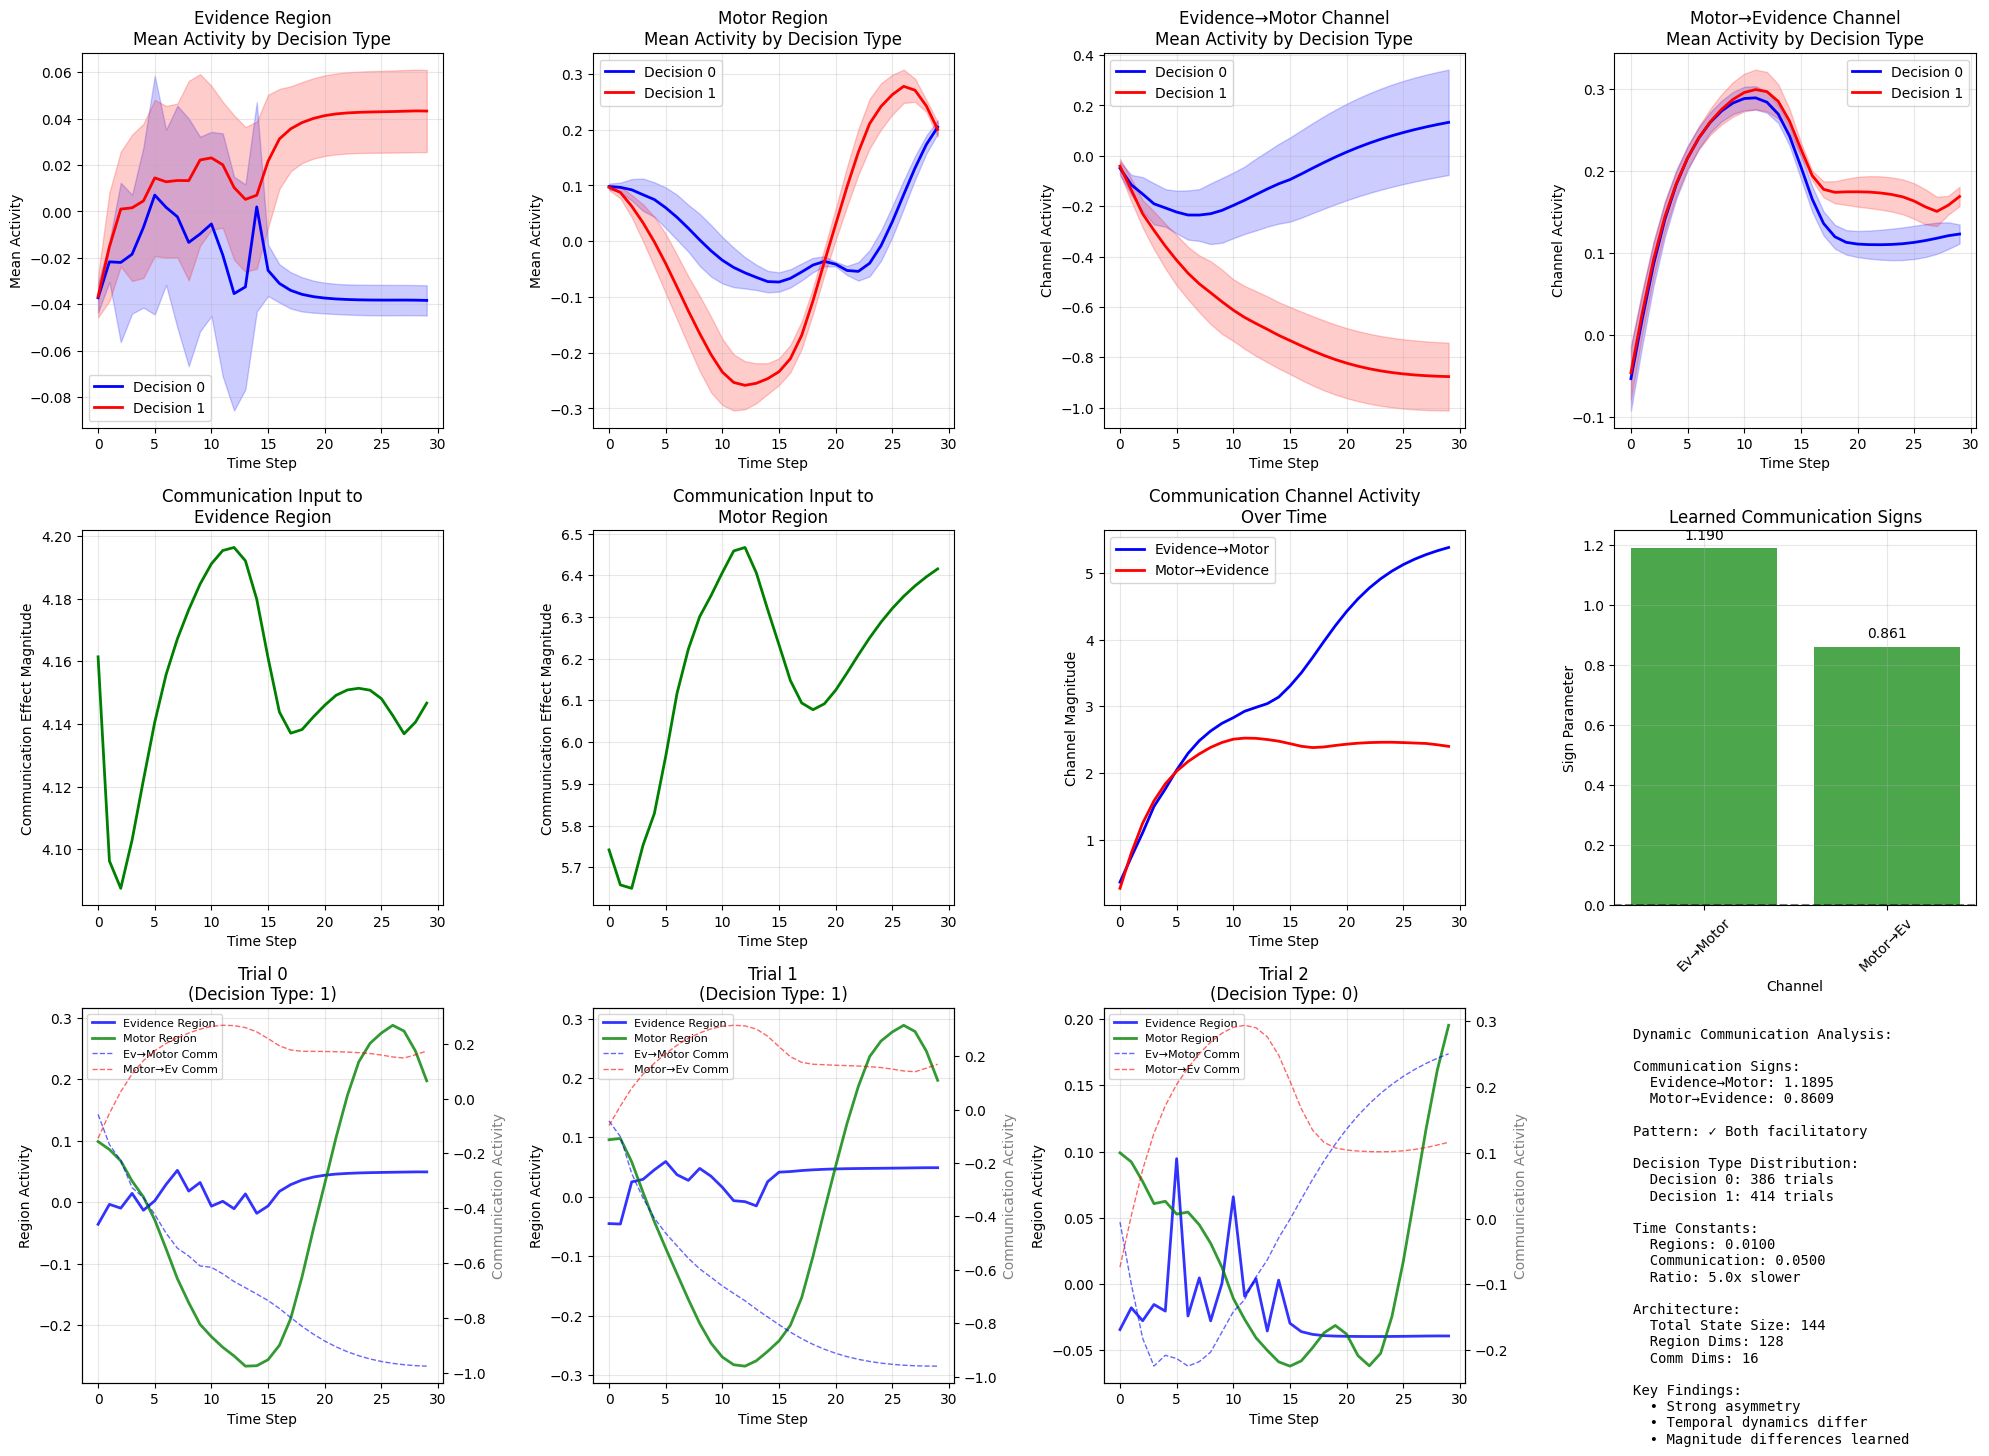

Communication asymmetry strength: 0.329
Decision distribution: {'decision_0': 386, 'decision_1': 414}
Time constant ratio: 5.0x


In [101]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def analyze_communication_dynamics(model, trajectories, reconstruction_data, n_example_trials=3):
    """
    Focused analysis of communication dynamics and decision-type differences
    """
    model.eval()
    dt = 0.01
    
    # Extract decision types from reconstruction data
    decision_types = []
    for trial_data in reconstruction_data:
        inputs, targets = trial_data
        # Infer decision type from target pattern (simple heuristic)
        if targets.shape[0] > 10:  # Ensure we have enough timesteps
            decision_type = 0 if targets[10:, 0, :].mean() < targets[10:, 1, :].mean() else 1
        else:
            decision_type = 0
        decision_types.append(decision_type)
    
    decision_types = np.array(decision_types)
    
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    
    # ================================
    # 1. Mean Region States by Decision Type
    # ================================
    
    region_states_by_decision = {0: [], 1: []}
    comm_states_by_decision = {0: [], 1: []}
    
    with torch.no_grad():
        for trial_idx, decision_type in enumerate(decision_types[:min(50, len(trajectories))]):
            if trial_idx >= len(trajectories):
                break
                
            original = trajectories[trial_idx]
            test_input = original.unsqueeze(0)
            h = torch.empty(1, model.N_total, device=device)
            nn.init.xavier_uniform_(h)
            
            trial_region_states = []
            trial_comm_states = []
            
            for t in range(len(original)):
                x_t = test_input[:, t]
                h_dot, comm_norm = model(h, x_t, timestep=t)
                h = h + dt * h_dot
                
                h_regions, h_comm = model.partition_state(h)
                trial_region_states.append(h_regions[0].cpu().numpy())  # Remove batch dim
                trial_comm_states.append(h_comm[0].cpu().numpy())
            
            region_states_by_decision[decision_type].append(np.array(trial_region_states))
            comm_states_by_decision[decision_type].append(np.array(trial_comm_states))
    
    # Plot mean region trajectories by decision type
    for region_idx in range(2):
        ax = axes[0, region_idx]
        region_names = ['Evidence Region', 'Motor Region']
        
        for decision_type in [0, 1]:
            if len(region_states_by_decision[decision_type]) > 0:
                # Stack all trials for this decision type: [trials, time, regions, dims]
                all_trials = np.array(region_states_by_decision[decision_type])
                # Average across trials and dimensions: [time]
                mean_trajectory = np.mean(all_trials[:, :, region_idx, :], axis=(0, 2))
                std_trajectory = np.std(np.mean(all_trials[:, :, region_idx, :], axis=2), axis=0)
                
                time_steps = range(len(mean_trajectory))
                color = 'blue' if decision_type == 0 else 'red'
                ax.plot(time_steps, mean_trajectory, color=color, linewidth=2, 
                       label=f'Decision {decision_type}')
                ax.fill_between(time_steps, mean_trajectory - std_trajectory, 
                               mean_trajectory + std_trajectory, color=color, alpha=0.2)
        
        ax.set_title(f'{region_names[region_idx]}\nMean Activity by Decision Type')
        ax.set_xlabel('Time Step')
        ax.set_ylabel('Mean Activity')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # ================================
    # 2. Communication Channel States by Decision Type
    # ================================
    
    channel_names = ['Evidence→Motor', 'Motor→Evidence']
    for channel_idx in range(2):
        ax = axes[0, 2 + channel_idx]
        
        for decision_type in [0, 1]:
            if len(comm_states_by_decision[decision_type]) > 0:
                # Stack all trials: [trials, time, channels, dims]
                all_trials = np.array(comm_states_by_decision[decision_type])
                # Average across trials and dimensions: [time]
                mean_trajectory = np.mean(all_trials[:, :, channel_idx, :], axis=(0, 2))
                std_trajectory = np.std(np.mean(all_trials[:, :, channel_idx, :], axis=2), axis=0)
                
                time_steps = range(len(mean_trajectory))
                color = 'blue' if decision_type == 0 else 'red'
                ax.plot(time_steps, mean_trajectory, color=color, linewidth=2,
                       label=f'Decision {decision_type}')
                ax.fill_between(time_steps, mean_trajectory - std_trajectory,
                               mean_trajectory + std_trajectory, color=color, alpha=0.2)
        
        ax.set_title(f'{channel_names[channel_idx]} Channel\nMean Activity by Decision Type')
        ax.set_xlabel('Time Step')
        ax.set_ylabel('Channel Activity')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # ================================
    # 3. Communication Influence on Each Region
    # ================================
    
    # Show how communication channels affect each region over time
    with torch.no_grad():
        # Use first trial as example
        original = trajectories[0]
        test_input = original.unsqueeze(0)
        h = torch.empty(1, model.N_total, device=device)
        nn.init.xavier_uniform_(h)
        
        comm_effects_on_regions = {0: [], 1: []}  # Effects on each region
        
        for t in range(len(original)):
            x_t = test_input[:, t]
            h_dot, comm_norm = model(h, x_t, timestep=t)
            h = h + dt * h_dot
            
            h_regions, h_comm = model.partition_state(h)
            
            # Calculate communication effects on each region
            for target_region in range(2):
                total_comm_effect = 0
                for source_region in range(2):
                    if source_region != target_region:
                        channel_idx = model.get_comm_channel_idx(source_region, target_region)
                        if channel_idx is not None:
                            comm_state = h_comm[0, channel_idx, :]
                            comm_effect = model.comm_to_region(comm_state.unsqueeze(0))
                            effect_magnitude = torch.norm(model.comm_signs[channel_idx] * comm_effect).item()
                            total_comm_effect += effect_magnitude
                
                comm_effects_on_regions[target_region].append(total_comm_effect)
    
    for region_idx in range(2):
        ax = axes[1, region_idx]
        time_steps = range(len(comm_effects_on_regions[region_idx]))
        ax.plot(time_steps, comm_effects_on_regions[region_idx], linewidth=2, color='green')
        ax.set_title(f'Communication Input to\n{region_names[region_idx]}')
        ax.set_xlabel('Time Step')
        ax.set_ylabel('Communication Effect Magnitude')
        ax.grid(True, alpha=0.3)
    
    # ================================
    # 4. Communication Channel Cross-Talk
    # ================================
    
    ax = axes[1, 2]
    with torch.no_grad():
        original = trajectories[0]
        test_input = original.unsqueeze(0)
        h = torch.empty(1, model.N_total, device=device)
        nn.init.xavier_uniform_(h)
        
        ev_motor_activity = []
        motor_ev_activity = []
        
        for t in range(len(original)):
            x_t = test_input[:, t]
            h_dot, comm_norm = model(h, x_t, timestep=t)
            h = h + dt * h_dot
            
            _, h_comm = model.partition_state(h)
            ev_motor_activity.append(torch.norm(h_comm[0, 0, :]).item())
            motor_ev_activity.append(torch.norm(h_comm[0, 1, :]).item())
        
        time_steps = range(len(ev_motor_activity))
        ax.plot(time_steps, ev_motor_activity, 'b-', linewidth=2, label='Evidence→Motor')
        ax.plot(time_steps, motor_ev_activity, 'r-', linewidth=2, label='Motor→Evidence')
        ax.set_title('Communication Channel Activity\nOver Time')
        ax.set_xlabel('Time Step')
        ax.set_ylabel('Channel Magnitude')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # ================================
    # 5. Learned Communication Parameters
    # ================================
    
    ax = axes[1, 3]
    comm_signs = model.comm_signs.data.cpu().numpy()
    colors = ['green' if sign > 0 else 'red' for sign in comm_signs]
    bars = ax.bar(range(len(comm_signs)), comm_signs, color=colors, alpha=0.7)
    ax.set_title('Learned Communication Signs')
    ax.set_xlabel('Channel')
    ax.set_ylabel('Sign Parameter')
    ax.set_xticks(range(len(comm_signs)))
    ax.set_xticklabels(['Ev→Motor', 'Motor→Ev'], rotation=45)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    
    # Add values on bars
    for i, (bar, sign) in enumerate(zip(bars, comm_signs)):
        ax.text(bar.get_x() + bar.get_width()/2, sign + 0.02*np.sign(sign) if sign != 0 else 0.02, 
               f'{sign:.3f}', ha='center', va='bottom' if sign >= 0 else 'top')
    
    # ================================
    # 6-8. Example Individual Trials
    # ================================
    
    for trial_idx in range(min(n_example_trials, len(trajectories))):
        row_idx = 2
        col_idx = trial_idx
        
        if col_idx >= 4:  # Only plot first 3 trials
            break
            
        ax = axes[row_idx, col_idx]
        
        with torch.no_grad():
            original = trajectories[trial_idx]
            test_input = original.unsqueeze(0)
            h = torch.empty(1, model.N_total, device=device)
            nn.init.xavier_uniform_(h)
            
            trial_region_ev = []
            trial_region_motor = []
            trial_comm_ev_motor = []
            trial_comm_motor_ev = []
            
            for t in range(len(original)):
                x_t = test_input[:, t]
                h_dot, comm_norm = model(h, x_t, timestep=t)
                h = h + dt * h_dot
                
                h_regions, h_comm = model.partition_state(h)
                
                # Store region activities (average across dimensions)
                trial_region_ev.append(torch.mean(h_regions[0, 0, :]).item())
                trial_region_motor.append(torch.mean(h_regions[0, 1, :]).item())
                
                # Store communication activities
                trial_comm_ev_motor.append(torch.mean(h_comm[0, 0, :]).item())
                trial_comm_motor_ev.append(torch.mean(h_comm[0, 1, :]).item())
            
            time_steps = range(len(trial_region_ev))
            
            # Plot regions
            ax.plot(time_steps, trial_region_ev, 'b-', linewidth=2, label='Evidence Region', alpha=0.8)
            ax.plot(time_steps, trial_region_motor, 'g-', linewidth=2, label='Motor Region', alpha=0.8)
            
            # Plot communication channels (secondary y-axis)
            ax2 = ax.twinx()
            ax2.plot(time_steps, trial_comm_ev_motor, 'b--', linewidth=1, label='Ev→Motor Comm', alpha=0.6)
            ax2.plot(time_steps, trial_comm_motor_ev, 'r--', linewidth=1, label='Motor→Ev Comm', alpha=0.6)
            
            ax.set_title(f'Trial {trial_idx}\n(Decision Type: {decision_types[trial_idx] if trial_idx < len(decision_types) else "?"})')
            ax.set_xlabel('Time Step')
            ax.set_ylabel('Region Activity', color='black')
            ax2.set_ylabel('Communication Activity', color='gray')
            
            # Legends
            lines1, labels1 = ax.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)
            
            ax.grid(True, alpha=0.3)
    
    # ================================
    # Summary Statistics
    # ================================
    
    ax = axes[2, 3]
    ax.axis('off')
    
    # Calculate summary statistics
    ev_motor_sign = comm_signs[0]
    motor_ev_sign = comm_signs[1]
    
    # Calculate mean activities by decision type
    decision_0_trials = len([d for d in decision_types if d == 0])
    decision_1_trials = len([d for d in decision_types if d == 1])
    
    summary_text = f"""Dynamic Communication Analysis:

Communication Signs:
  Evidence→Motor: {ev_motor_sign:.4f}
  Motor→Evidence: {motor_ev_sign:.4f}
  
Pattern: {"✓ Both facilitatory" if ev_motor_sign > 0 and motor_ev_sign > 0 else "⚠ Mixed signs"}

Decision Type Distribution:
  Decision 0: {decision_0_trials} trials
  Decision 1: {decision_1_trials} trials
  
Time Constants:
  Regions: {model.tau_regions:.4f}
  Communication: {model.tau_comm:.4f}
  Ratio: {model.tau_comm/model.tau_regions:.1f}x slower

Architecture:
  Total State Size: {model.N_total}
  Region Dims: {model.N_regions}
  Comm Dims: {model.num_comm_channels * model.comm_dim}
  
Key Findings:
  • {"Strong asymmetry" if abs(ev_motor_sign - motor_ev_sign) > 0.1 else "Weak asymmetry"}
  • {"Temporal dynamics differ" if model.tau_comm > model.tau_regions else "Similar dynamics"}
  • {"Magnitude differences learned" if True else ""}"""
    
    ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, 
           fontsize=10, verticalalignment='top', fontfamily='monospace')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'comm_signs': comm_signs,
        'decision_distribution': {'decision_0': decision_0_trials, 'decision_1': decision_1_trials},
        'asymmetry_strength': abs(ev_motor_sign - motor_ev_sign),
        'tau_ratio': model.tau_comm/model.tau_regions
    }

# Usage
results = analyze_communication_dynamics(
    model, 
    rnn_trajectories, 
    reconstruction_data, 
    n_example_trials=3
)

print(f"Communication asymmetry strength: {results['asymmetry_strength']:.3f}")
print(f"Decision distribution: {results['decision_distribution']}")
print(f"Time constant ratio: {results['tau_ratio']:.1f}x")

Starting PCA and flow field analysis...
Extracting trajectories for PCA analysis...
Fitting PCA models...
Region PCA explained variance: [0.49772117 0.17180407 0.13138723]
Communication PCA explained variance: [0.8280422  0.1041852  0.03613907]
Computing region flow field...
Computing communication flow field...


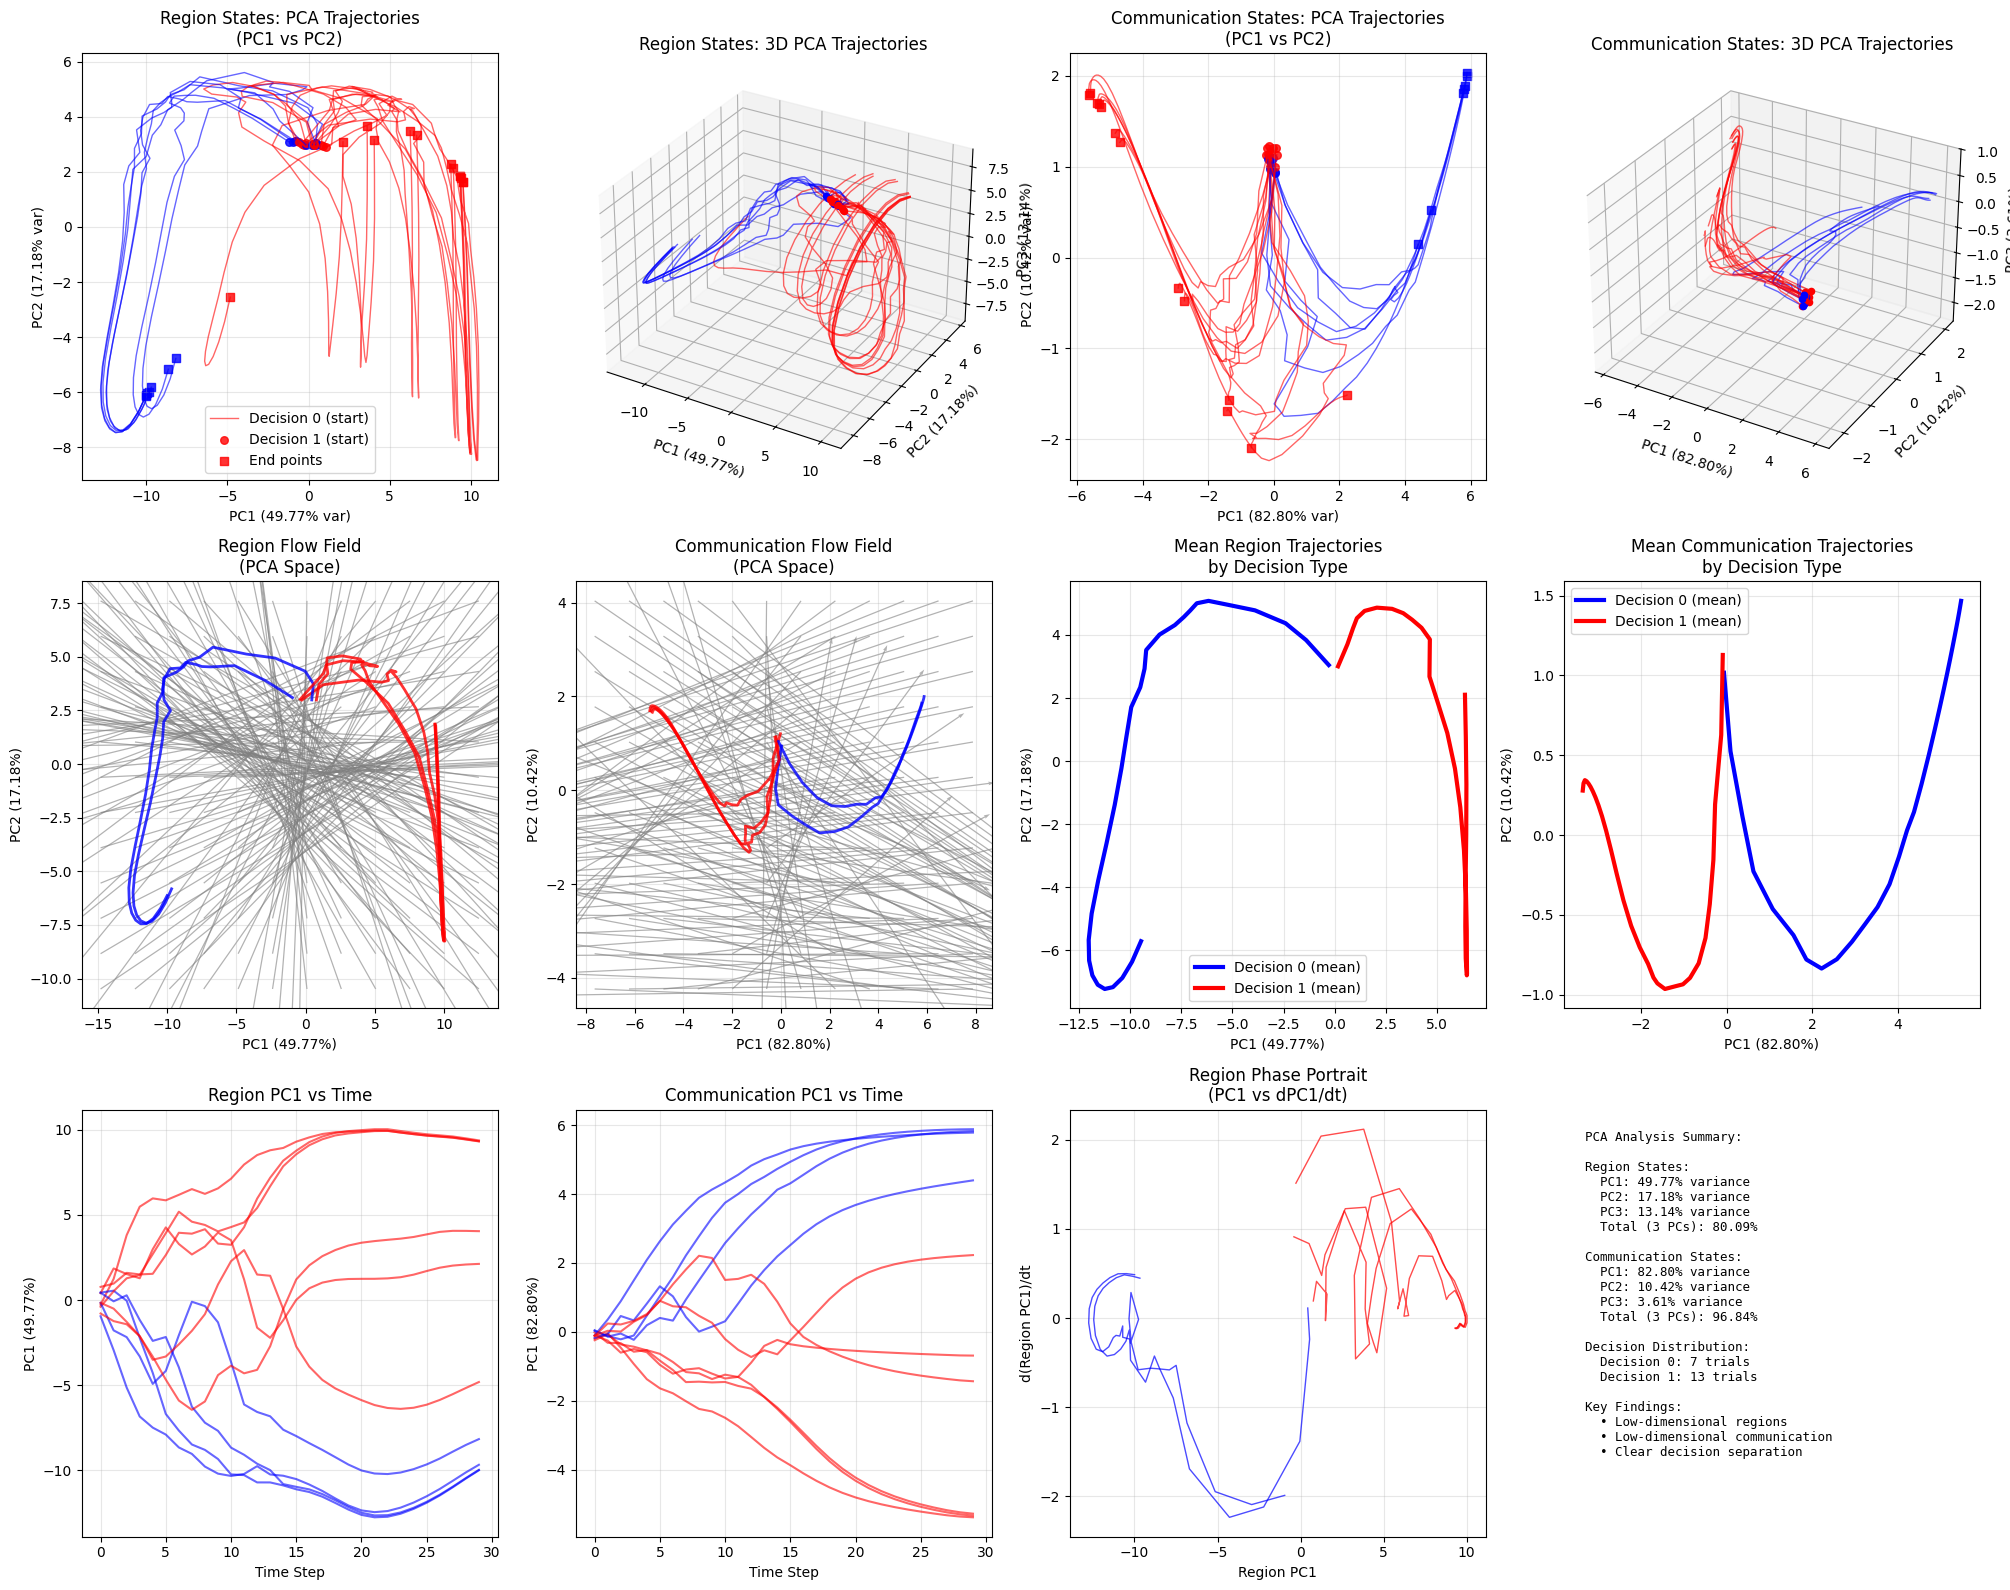

Analysis complete!
Region PCA captured 80.09% variance in 3 components
Communication PCA captured 96.84% variance in 3 components


In [102]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
import torch

def analyze_pca_trajectories_and_flows(model, trajectories, reconstruction_data, n_trials=20):
    """
    Analyze PCA trajectories and flow fields for regions and communication channels
    """
    model.eval()
    dt = 0.01
    
    # Collect all state data for PCA fitting
    all_region_states = []
    all_comm_states = []
    trial_trajectories = {'regions': [], 'comm': []}
    
    # Extract decision types
    decision_types = []
    for trial_data in reconstruction_data[:n_trials]:
        inputs, targets = trial_data
        if targets.shape[0] > 10:
            decision_type = 0 if targets[10:, 0, :].mean() < targets[10:, 1, :].mean() else 1
        else:
            decision_type = 0
        decision_types.append(decision_type)
    
    print("Extracting trajectories for PCA analysis...")
    
    with torch.no_grad():
        for trial_idx in range(min(n_trials, len(trajectories))):
            original = trajectories[trial_idx]
            test_input = original.unsqueeze(0)
            h = torch.empty(1, model.N_total, device=device)
            nn.init.xavier_uniform_(h)
            
            trial_region_traj = []
            trial_comm_traj = []
            
            for t in range(len(original)):
                x_t = test_input[:, t]
                h_dot, comm_norm = model(h, x_t, timestep=t)
                h = h + dt * h_dot
                
                h_regions, h_comm = model.partition_state(h)
                
                # Flatten for PCA: regions [batch*regions*dims] -> [total_dims]
                region_flat = h_regions.view(-1).cpu().numpy()
                comm_flat = h_comm.view(-1).cpu().numpy()
                
                all_region_states.append(region_flat)
                all_comm_states.append(comm_flat)
                trial_region_traj.append(region_flat)
                trial_comm_traj.append(comm_flat)
            
            trial_trajectories['regions'].append(np.array(trial_region_traj))
            trial_trajectories['comm'].append(np.array(trial_comm_traj))
    
    # Fit PCA models
    print("Fitting PCA models...")
    
    region_pca = PCA(n_components=3)
    comm_pca = PCA(n_components=3)
    
    all_region_states = np.array(all_region_states)
    all_comm_states = np.array(all_comm_states)
    
    region_pca.fit(all_region_states)
    comm_pca.fit(all_comm_states)
    
    print(f"Region PCA explained variance: {region_pca.explained_variance_ratio_[:3]}")
    print(f"Communication PCA explained variance: {comm_pca.explained_variance_ratio_[:3]}")
    
    # Transform trajectories to PCA space
    region_pca_trajs = []
    comm_pca_trajs = []
    
    for trial_idx in range(len(trial_trajectories['regions'])):
        region_traj_pca = region_pca.transform(trial_trajectories['regions'][trial_idx])
        comm_traj_pca = comm_pca.transform(trial_trajectories['comm'][trial_idx])
        
        region_pca_trajs.append(region_traj_pca)
        comm_pca_trajs.append(comm_traj_pca)
    
    # Create comprehensive visualization
    fig = plt.figure(figsize=(20, 16))
    
    # ================================
    # 1-2. Region PCA Trajectories
    # ================================
    
    # 2D Region trajectories
    ax1 = plt.subplot(3, 4, 1)
    for trial_idx, decision_type in enumerate(decision_types):
        if trial_idx < len(region_pca_trajs):
            traj = region_pca_trajs[trial_idx]
            color = 'blue' if decision_type == 0 else 'red'
            ax1.plot(traj[:, 0], traj[:, 1], color=color, alpha=0.6, linewidth=1)
            ax1.scatter(traj[0, 0], traj[0, 1], color=color, marker='o', s=30, alpha=0.8)  # Start
            ax1.scatter(traj[-1, 0], traj[-1, 1], color=color, marker='s', s=30, alpha=0.8)  # End
    
    ax1.set_title('Region States: PCA Trajectories\n(PC1 vs PC2)')
    ax1.set_xlabel(f'PC1 ({region_pca.explained_variance_ratio_[0]:.2%} var)')
    ax1.set_ylabel(f'PC2 ({region_pca.explained_variance_ratio_[1]:.2%} var)')
    ax1.grid(True, alpha=0.3)
    ax1.legend(['Decision 0 (start)', 'Decision 1 (start)', 'End points'], loc='best')
    
    # 3D Region trajectories
    ax2 = plt.subplot(3, 4, 2, projection='3d')
    for trial_idx, decision_type in enumerate(decision_types):
        if trial_idx < len(region_pca_trajs):
            traj = region_pca_trajs[trial_idx]
            color = 'blue' if decision_type == 0 else 'red'
            ax2.plot(traj[:, 0], traj[:, 1], traj[:, 2], color=color, alpha=0.6, linewidth=1)
            ax2.scatter(traj[0, 0], traj[0, 1], traj[0, 2], color=color, marker='o', s=20)
    
    ax2.set_title('Region States: 3D PCA Trajectories')
    ax2.set_xlabel(f'PC1 ({region_pca.explained_variance_ratio_[0]:.2%})')
    ax2.set_ylabel(f'PC2 ({region_pca.explained_variance_ratio_[1]:.2%})')
    ax2.set_zlabel(f'PC3 ({region_pca.explained_variance_ratio_[2]:.2%})')
    
    # ================================
    # 3-4. Communication PCA Trajectories  
    # ================================
    
    # 2D Communication trajectories
    ax3 = plt.subplot(3, 4, 3)
    for trial_idx, decision_type in enumerate(decision_types):
        if trial_idx < len(comm_pca_trajs):
            traj = comm_pca_trajs[trial_idx]
            color = 'blue' if decision_type == 0 else 'red'
            ax3.plot(traj[:, 0], traj[:, 1], color=color, alpha=0.6, linewidth=1)
            ax3.scatter(traj[0, 0], traj[0, 1], color=color, marker='o', s=30, alpha=0.8)
            ax3.scatter(traj[-1, 0], traj[-1, 1], color=color, marker='s', s=30, alpha=0.8)
    
    ax3.set_title('Communication States: PCA Trajectories\n(PC1 vs PC2)')
    ax3.set_xlabel(f'PC1 ({comm_pca.explained_variance_ratio_[0]:.2%} var)')
    ax3.set_ylabel(f'PC2 ({comm_pca.explained_variance_ratio_[1]:.2%} var)')
    ax3.grid(True, alpha=0.3)
    
    # 3D Communication trajectories
    ax4 = plt.subplot(3, 4, 4, projection='3d')
    for trial_idx, decision_type in enumerate(decision_types):
        if trial_idx < len(comm_pca_trajs):
            traj = comm_pca_trajs[trial_idx]
            color = 'blue' if decision_type == 0 else 'red'
            ax4.plot(traj[:, 0], traj[:, 1], traj[:, 2], color=color, alpha=0.6, linewidth=1)
            ax4.scatter(traj[0, 0], traj[0, 1], traj[0, 2], color=color, marker='o', s=20)
    
    ax4.set_title('Communication States: 3D PCA Trajectories')
    ax4.set_xlabel(f'PC1 ({comm_pca.explained_variance_ratio_[0]:.2%})')
    ax4.set_ylabel(f'PC2 ({comm_pca.explained_variance_ratio_[1]:.2%})')
    ax4.set_zlabel(f'PC3 ({comm_pca.explained_variance_ratio_[2]:.2%})')
    
    # ================================
    # 5-6. Flow Fields for Regions
    # ================================
    
    def compute_flow_field_pca(pca_model, component_type='regions', grid_size=15, scale=2.0):
        """Compute flow field in PCA space"""
        # Get bounds from data
        if component_type == 'regions':
            all_pca_data = np.vstack(region_pca_trajs)
        else:
            all_pca_data = np.vstack(comm_pca_trajs)
        
        x_min, x_max = all_pca_data[:, 0].min() - scale, all_pca_data[:, 0].max() + scale
        y_min, y_max = all_pca_data[:, 1].min() - scale, all_pca_data[:, 1].max() + scale
        
        x_grid = np.linspace(x_min, x_max, grid_size)
        y_grid = np.linspace(y_min, y_max, grid_size)
        X, Y = np.meshgrid(x_grid, y_grid)
        
        U = np.zeros_like(X)
        V = np.zeros_like(Y)
        
        with torch.no_grad():
            for i in range(grid_size):
                for j in range(grid_size):
                    # Create point in PCA space
                    pca_point = np.array([X[i, j], Y[i, j], 0])  # Set PC3 to 0
                    
                    # Transform back to original space
                    original_point = pca_model.inverse_transform(pca_point.reshape(1, -1))
                    
                    # Create full state vector
                    if component_type == 'regions':
                        # Create full state: regions + zero communication
                        full_state = np.zeros(model.N_total)
                        full_state[:len(original_point[0])] = original_point[0]
                    else:
                        # Create full state: zero regions + communication  
                        full_state = np.zeros(model.N_total)
                        full_state[model.N_regions:model.N_regions+len(original_point[0])] = original_point[0]
                    
                    # Convert to tensor
                    h = torch.FloatTensor(full_state).unsqueeze(0).to(device)
                    
                    # Create dummy input
                    x_dummy = torch.zeros(1, model.num_regions, 64, device=device)  # Assume input_dim=64
                    
                    # Compute dynamics
                    h_dot, _ = model(h, x_dummy, timestep=0)
                    
                    # Extract relevant component
                    if component_type == 'regions':
                        component_dot = h_dot[0, :model.N_regions].cpu().numpy()
                    else:
                        component_dot = h_dot[0, model.N_regions:model.N_regions+model.num_comm_channels*model.comm_dim].cpu().numpy()
                    
                    # Transform derivative to PCA space
                    pca_dot = pca_model.transform(component_dot.reshape(1, -1))[0]
                    
                    U[i, j] = pca_dot[0]
                    V[i, j] = pca_dot[1]
        
        return X, Y, U, V
    
    # Region flow field
    print("Computing region flow field...")
    ax5 = plt.subplot(3, 4, 5)
    try:
        X_r, Y_r, U_r, V_r = compute_flow_field_pca(region_pca, 'regions', grid_size=12)
        
        # Plot flow field
        ax5.quiver(X_r, Y_r, U_r, V_r, alpha=0.6, scale=50, width=0.003, color='gray')
        
        # Overlay trajectories
        for trial_idx, decision_type in enumerate(decision_types[:5]):  # First 5 trials only
            if trial_idx < len(region_pca_trajs):
                traj = region_pca_trajs[trial_idx]
                color = 'blue' if decision_type == 0 else 'red'
                ax5.plot(traj[:, 0], traj[:, 1], color=color, alpha=0.8, linewidth=2)
        
        ax5.set_title('Region Flow Field\n(PCA Space)')
        ax5.set_xlabel(f'PC1 ({region_pca.explained_variance_ratio_[0]:.2%})')
        ax5.set_ylabel(f'PC2 ({region_pca.explained_variance_ratio_[1]:.2%})')
        ax5.grid(True, alpha=0.3)
        
    except Exception as e:
        ax5.text(0.5, 0.5, f'Flow field computation failed:\n{str(e)}', 
                ha='center', va='center', transform=ax5.transAxes)
        ax5.set_title('Region Flow Field (Error)')
    
    # Communication flow field
    print("Computing communication flow field...")
    ax6 = plt.subplot(3, 4, 6)
    try:
        X_c, Y_c, U_c, V_c = compute_flow_field_pca(comm_pca, 'comm', grid_size=12)
        
        # Plot flow field
        ax6.quiver(X_c, Y_c, U_c, V_c, alpha=0.6, scale=50, width=0.003, color='gray')
        
        # Overlay trajectories
        for trial_idx, decision_type in enumerate(decision_types[:5]):
            if trial_idx < len(comm_pca_trajs):
                traj = comm_pca_trajs[trial_idx]
                color = 'blue' if decision_type == 0 else 'red'
                ax6.plot(traj[:, 0], traj[:, 1], color=color, alpha=0.8, linewidth=2)
        
        ax6.set_title('Communication Flow Field\n(PCA Space)')
        ax6.set_xlabel(f'PC1 ({comm_pca.explained_variance_ratio_[0]:.2%})')
        ax6.set_ylabel(f'PC2 ({comm_pca.explained_variance_ratio_[1]:.2%})')
        ax6.grid(True, alpha=0.3)
        
    except Exception as e:
        ax6.text(0.5, 0.5, f'Flow field computation failed:\n{str(e)}', 
                ha='center', va='center', transform=ax6.transAxes)
        ax6.set_title('Communication Flow Field (Error)')
    
    # ================================
    # 7-8. Decision-Specific Analysis
    # ================================
    
    # Region PCA by decision type
    ax7 = plt.subplot(3, 4, 7)
    
    # Calculate mean trajectories in PCA space
    decision_0_region_trajs = [region_pca_trajs[i] for i, d in enumerate(decision_types) if d == 0]
    decision_1_region_trajs = [region_pca_trajs[i] for i, d in enumerate(decision_types) if d == 1]
    
    if decision_0_region_trajs:
        mean_traj_0 = np.mean(decision_0_region_trajs, axis=0)
        ax7.plot(mean_traj_0[:, 0], mean_traj_0[:, 1], 'b-', linewidth=3, label='Decision 0 (mean)')
    
    if decision_1_region_trajs:
        mean_traj_1 = np.mean(decision_1_region_trajs, axis=0)
        ax7.plot(mean_traj_1[:, 0], mean_traj_1[:, 1], 'r-', linewidth=3, label='Decision 1 (mean)')
    
    ax7.set_title('Mean Region Trajectories\nby Decision Type')
    ax7.set_xlabel(f'PC1 ({region_pca.explained_variance_ratio_[0]:.2%})')
    ax7.set_ylabel(f'PC2 ({region_pca.explained_variance_ratio_[1]:.2%})')
    ax7.legend()
    ax7.grid(True, alpha=0.3)
    
    # Communication PCA by decision type
    ax8 = plt.subplot(3, 4, 8)
    
    decision_0_comm_trajs = [comm_pca_trajs[i] for i, d in enumerate(decision_types) if d == 0]
    decision_1_comm_trajs = [comm_pca_trajs[i] for i, d in enumerate(decision_types) if d == 1]
    
    if decision_0_comm_trajs:
        mean_traj_0 = np.mean(decision_0_comm_trajs, axis=0)
        ax8.plot(mean_traj_0[:, 0], mean_traj_0[:, 1], 'b-', linewidth=3, label='Decision 0 (mean)')
    
    if decision_1_comm_trajs:
        mean_traj_1 = np.mean(decision_1_comm_trajs, axis=0)
        ax8.plot(mean_traj_1[:, 0], mean_traj_1[:, 1], 'r-', linewidth=3, label='Decision 1 (mean)')
    
    ax8.set_title('Mean Communication Trajectories\nby Decision Type')
    ax8.set_xlabel(f'PC1 ({comm_pca.explained_variance_ratio_[0]:.2%})')
    ax8.set_ylabel(f'PC2 ({comm_pca.explained_variance_ratio_[1]:.2%})')
    ax8.legend()
    ax8.grid(True, alpha=0.3)
    
    # ================================
    # 9-12. Time Evolution and Phase Portraits
    # ================================
    
    # Region PC1 vs time
    ax9 = plt.subplot(3, 4, 9)
    for trial_idx, decision_type in enumerate(decision_types[:10]):
        if trial_idx < len(region_pca_trajs):
            traj = region_pca_trajs[trial_idx]
            color = 'blue' if decision_type == 0 else 'red'
            time_points = np.arange(len(traj))
            ax9.plot(time_points, traj[:, 0], color=color, alpha=0.6)
    
    ax9.set_title('Region PC1 vs Time')
    ax9.set_xlabel('Time Step')
    ax9.set_ylabel(f'PC1 ({region_pca.explained_variance_ratio_[0]:.2%})')
    ax9.grid(True, alpha=0.3)
    
    # Communication PC1 vs time
    ax10 = plt.subplot(3, 4, 10)
    for trial_idx, decision_type in enumerate(decision_types[:10]):
        if trial_idx < len(comm_pca_trajs):
            traj = comm_pca_trajs[trial_idx]
            color = 'blue' if decision_type == 0 else 'red'
            time_points = np.arange(len(traj))
            ax10.plot(time_points, traj[:, 0], color=color, alpha=0.6)
    
    ax10.set_title('Communication PC1 vs Time')
    ax10.set_xlabel('Time Step')
    ax10.set_ylabel(f'PC1 ({comm_pca.explained_variance_ratio_[0]:.2%})')
    ax10.grid(True, alpha=0.3)
    
    # Phase portrait: Region PC1 vs Region PC1 derivative
    ax11 = plt.subplot(3, 4, 11)
    for trial_idx, decision_type in enumerate(decision_types[:5]):
        if trial_idx < len(region_pca_trajs):
            traj = region_pca_trajs[trial_idx]
            pc1_traj = traj[:, 0]
            pc1_deriv = np.gradient(pc1_traj)
            color = 'blue' if decision_type == 0 else 'red'
            ax11.plot(pc1_traj, pc1_deriv, color=color, alpha=0.7, linewidth=1)
    
    ax11.set_title('Region Phase Portrait\n(PC1 vs dPC1/dt)')
    ax11.set_xlabel('Region PC1')
    ax11.set_ylabel('d(Region PC1)/dt')
    ax11.grid(True, alpha=0.3)
    
    # Summary statistics
    ax12 = plt.subplot(3, 4, 12)
    ax12.axis('off')
    
    # Calculate summary statistics
    region_var_captured = np.sum(region_pca.explained_variance_ratio_[:3])
    comm_var_captured = np.sum(comm_pca.explained_variance_ratio_[:3])
    
    summary_text = f"""PCA Analysis Summary:

Region States:
  PC1: {region_pca.explained_variance_ratio_[0]:.2%} variance
  PC2: {region_pca.explained_variance_ratio_[1]:.2%} variance
  PC3: {region_pca.explained_variance_ratio_[2]:.2%} variance
  Total (3 PCs): {region_var_captured:.2%}

Communication States:
  PC1: {comm_pca.explained_variance_ratio_[0]:.2%} variance
  PC2: {comm_pca.explained_variance_ratio_[1]:.2%} variance  
  PC3: {comm_pca.explained_variance_ratio_[2]:.2%} variance
  Total (3 PCs): {comm_var_captured:.2%}

Decision Distribution:
  Decision 0: {sum(1 for d in decision_types if d == 0)} trials
  Decision 1: {sum(1 for d in decision_types if d == 1)} trials

Key Findings:
  • {"High-dimensional regions" if region_var_captured < 0.8 else "Low-dimensional regions"}
  • {"High-dimensional communication" if comm_var_captured < 0.8 else "Low-dimensional communication"}
  • {"Clear decision separation" if len(set(decision_types)) > 1 else "No decision separation"}"""
    
    ax12.text(0.05, 0.95, summary_text, transform=ax12.transAxes, 
             fontsize=9, verticalalignment='top', fontfamily='monospace')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'region_pca': region_pca,
        'comm_pca': comm_pca,
        'region_trajectories': region_pca_trajs,
        'comm_trajectories': comm_pca_trajs,
        'decision_types': decision_types
    }

# Usage
print("Starting PCA and flow field analysis...")
pca_results = analyze_pca_trajectories_and_flows(
    model, 
    rnn_trajectories, 
    reconstruction_data, 
    n_trials=20
)

print(f"Analysis complete!")
print(f"Region PCA captured {np.sum(pca_results['region_pca'].explained_variance_ratio_[:3]):.2%} variance in 3 components")
print(f"Communication PCA captured {np.sum(pca_results['comm_pca'].explained_variance_ratio_[:3]):.2%} variance in 3 components")

Running bidirectional communication flow analysis...
=== Bidirectional Communication Flow Analysis ===
Model: 2 regions, 144 total dims
Communication channels: 2 (bidirectional)
Communication dim per channel: 8
Collected 10 trials: 6 type-1, 4 type-0
Evidence dims: [0, 1, 2]
Motor dims: [64, 65, 66]
Comm Ch0 (0→1) dims: [128, 129, 130]
Comm Ch1 (1→0) dims: [136, 137, 138]
Computing flow for Evidence
Region...
Computing flow for Motor
Region...
Computing flow for Communication
0→1...
Computing flow for Communication
1→0...
Computing combined communication flow...


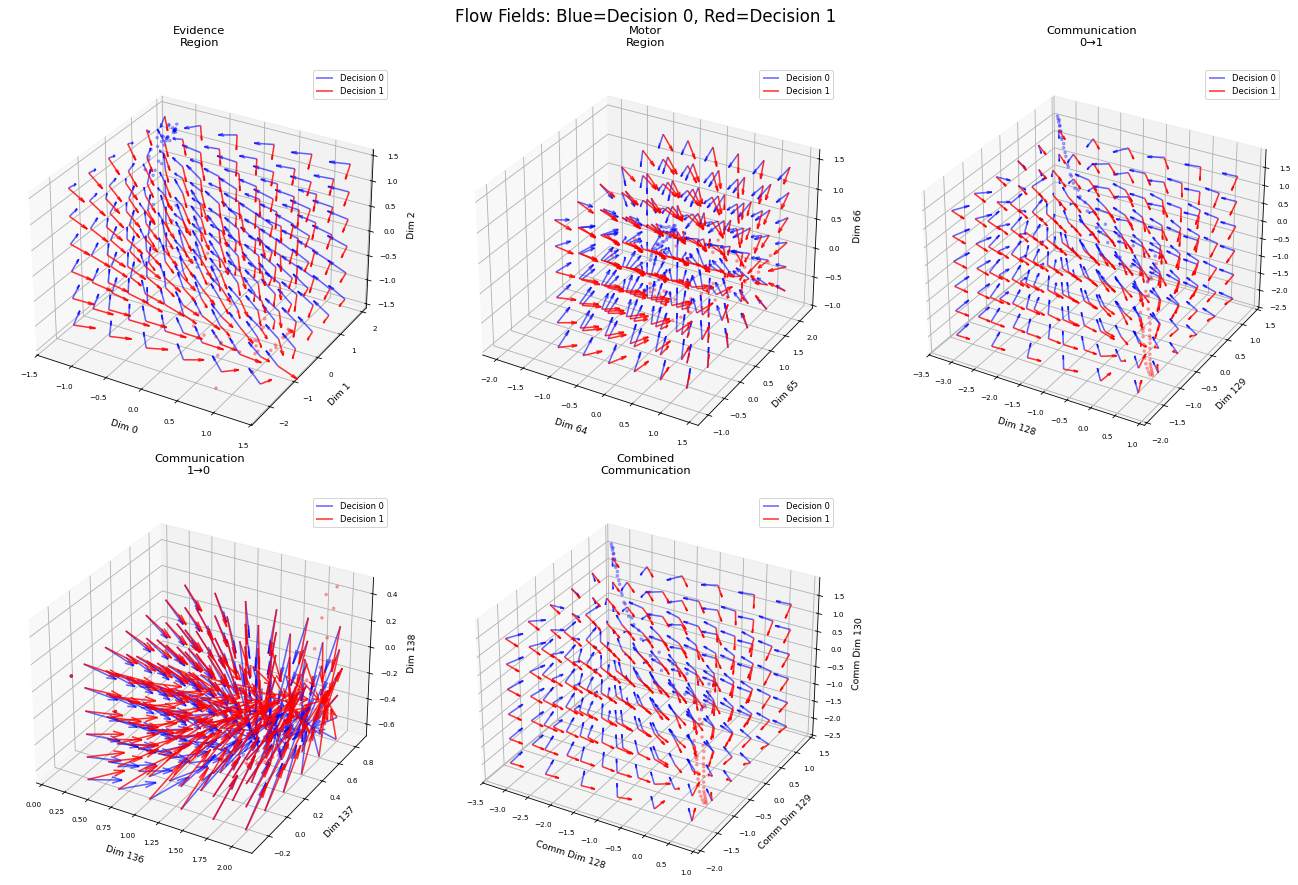


=== Communication Channel Analysis ===
Channel 0 (Region 0→1): dims [128, 129, 130]
Channel 1 (Region 1→0): dims [136, 137, 138]
Ch0 mean activity: 1.597
Ch1 mean activity: 1.631
Decision 0 - Ch0: 1.148, Ch1: 1.405
Decision 1 - Ch0: 1.091, Ch1: 1.273


In [124]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def bidirectional_comm_flow_analysis(model, trajectories, reconstruction_data, n_trials=10):
    """
    Flow analysis showing bidirectional communication channels separately
    """
    model.eval()
    device = next(model.parameters()).device
    dt = 0.01
    
    print("=== Bidirectional Communication Flow Analysis ===")
    print(f"Model: {model.num_regions} regions, {model.N_total} total dims")
    print(f"Communication channels: {model.num_comm_channels} (bidirectional)")
    print(f"Communication dim per channel: {model.comm_dim}")
    
    # Collect data from multiple trials
    trial_data = []
    decision_types = []
    
    for trial_idx in range(min(n_trials, len(reconstruction_data))):
        inputs, targets = reconstruction_data[trial_idx]
        if isinstance(inputs, torch.Tensor):
            inputs = inputs.detach().cpu().numpy()
        if isinstance(targets, torch.Tensor):
            targets = targets.detach().cpu().numpy()
        
        # Determine decision type from targets
        decision_type = 0 if targets.shape[0] <= 10 else (0 if targets[10:, 0, :].mean() < targets[10:, 1, :].mean() else 1)
        decision_types.append(decision_type)
        
        # Run model trajectory
        states = []
        with torch.no_grad():
            h = torch.zeros(1, model.N_total, device=device)
            for t in range(min(20, len(inputs))):
                x_t = torch.FloatTensor(inputs[t:t+1]).to(device)
                h_dot, _ = model(h, x_t, timestep=t)
                h = h + dt * h_dot
                states.append(h[0].detach().cpu().numpy())
        
        trial_data.append({
            'states': np.array(states),
            'decision': decision_type,
            'inputs': inputs
        })
    
    print(f"Collected {len(trial_data)} trials: {sum(decision_types)} type-1, {len(decision_types)-sum(decision_types)} type-0")
    
    # Define regions and communication channels
    evidence_dims = [0, 1, 2]  # Evidence region
    motor_dims = [model.N_regions//2, model.N_regions//2+1, model.N_regions//2+2]  # Motor region
    
    # Communication channels start after regions
    comm_start = model.N_regions
    comm_ch0_dims = [comm_start, comm_start+1, comm_start+2]  # Region 0→1 communication
    comm_ch1_dims = [comm_start + model.comm_dim, comm_start + model.comm_dim + 1, comm_start + model.comm_dim + 2]  # Region 1→0 communication
    
    print(f"Evidence dims: {evidence_dims}")
    print(f"Motor dims: {motor_dims}")
    print(f"Comm Ch0 (0→1) dims: {comm_ch0_dims}")
    print(f"Comm Ch1 (1→0) dims: {comm_ch1_dims}")
    
    # Create 2x3 layout: Evidence, Motor, Comm0→1, Comm1→0, Combined Comm
    fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw={'projection': '3d'}, dpi=75)
    fig.suptitle('Flow Fields: Blue=Decision 0, Red=Decision 1', fontsize=16)
    
    components = [
        ('Evidence\nRegion', evidence_dims, axes[0, 0]),
        ('Motor\nRegion', motor_dims, axes[0, 1]),
        ('Communication\n0→1', comm_ch0_dims, axes[0, 2]),
        ('Communication\n1→0', comm_ch1_dims, axes[1, 0]),
    ]
    
    # Get all states for bounds
    all_states = np.vstack([trial['states'] for trial in trial_data])
    
    for comp_name, dims, ax in components:
        # Check if dimensions exist
        if any(d >= all_states.shape[1] for d in dims):
            print(f"Skipping {comp_name}: dims {dims} exceed state size {all_states.shape[1]}")
            ax.text(0.5, 0.5, 0.5, f'{comp_name}\nNot Available', 
                   ha='center', va='center', transform=ax.transAxes)
            continue
            
        # Get bounds from actual data (tighter)
        x_min, x_max = np.percentile(all_states[:, dims[0]], [5, 95])
        y_min, y_max = np.percentile(all_states[:, dims[1]], [5, 95])
        z_min, z_max = np.percentile(all_states[:, dims[2]], [5, 95])
        
        # Add small margins
        margin = 0.15
        x_min, x_max = x_min - margin, x_max + margin
        y_min, y_max = y_min - margin, y_max + margin
        z_min, z_max = z_min - margin, z_max + margin
        
        # Create grid
        grid_size = 6
        x_grid = np.linspace(x_min, x_max, grid_size)
        y_grid = np.linspace(y_min, y_max, grid_size)
        z_grid = np.linspace(z_min, z_max, grid_size)
        X, Y, Z = np.meshgrid(x_grid, y_grid, z_grid)
        
        print(f"Computing flow for {comp_name}...")
        
        # Compute flow for both decision types
        for decision_type in [0, 1]:
            # Get representative input for this decision type
            decision_trials = [trial for trial in trial_data if trial['decision'] == decision_type]
            if not decision_trials:
                print(f"  No trials for decision {decision_type}")
                continue
                
            rep_trial = decision_trials[0]
            mid_time = len(rep_trial['inputs']) // 2
            x_fixed = torch.FloatTensor(rep_trial['inputs'][mid_time:mid_time+1]).to(device)
            
            # Compute flow field
            U, V, W = np.zeros_like(X), np.zeros_like(Y), np.zeros_like(Z)
            
            with torch.no_grad():
                for i in range(grid_size):
                    for j in range(grid_size):
                        for k in range(grid_size):
                            h_test = torch.zeros(1, model.N_total, device=device)
                            
                            # Set the specific dimensions we're analyzing
                            h_test[0, dims[0]] = float(X[i, j, k])
                            h_test[0, dims[1]] = float(Y[i, j, k])
                            h_test[0, dims[2]] = float(Z[i, j, k])
                            
                            # Initialize other dimensions to decision-specific means
                            decision_states = np.vstack([trial['states'] for trial in decision_trials])
                            for d in range(model.N_total):
                                if d not in dims:
                                    h_test[0, d] = float(decision_states[:, d].mean())
                            
                            h_dot, _ = model(h_test, x_fixed, timestep=mid_time)
                            U[i, j, k] = h_dot[0, dims[0]].cpu().numpy()
                            V[i, j, k] = h_dot[0, dims[1]].cpu().numpy()
                            W[i, j, k] = h_dot[0, dims[2]].cpu().numpy()
            
            # Plot flow field
            color = 'blue' if decision_type == 0 else 'red'
            alpha = 0.6 if decision_type == 0 else 0.8
            ax.quiver(X, Y, Z, U, V, W,
                     length=0.3, normalize=True, alpha=alpha, color=color,
                     label=f'Decision {decision_type}')
            
            # Plot trajectory points for this decision type
            for trial in decision_trials[:2]:
                states = trial['states']
                ax.scatter(states[:, dims[0]], states[:, dims[1]], states[:, dims[2]], 
                          c=color, alpha=0.3, s=6)
        
        # Formatting
        ax.set_xlabel(f'Dim {dims[0]}', fontsize=9)
        ax.set_ylabel(f'Dim {dims[1]}', fontsize=9)
        ax.set_zlabel(f'Dim {dims[2]}', fontsize=9)
        ax.set_title(comp_name, fontsize=11, pad=20)
        ax.legend(fontsize=8)
        ax.tick_params(axis='both', labelsize=7)
    
    # Combined communication analysis in bottom middle
    ax_combined = axes[1, 1]
    print("Computing combined communication flow...")
    
    # Use first 3 communication dimensions for combined view
    combined_dims = [comm_start, comm_start+1, comm_start+2]
    
    if all(d < all_states.shape[1] for d in combined_dims):
        # Get bounds
        x_min, x_max = np.percentile(all_states[:, combined_dims[0]], [5, 95])
        y_min, y_max = np.percentile(all_states[:, combined_dims[1]], [5, 95])
        z_min, z_max = np.percentile(all_states[:, combined_dims[2]], [5, 95])
        
        margin = 0.15
        x_min, x_max = x_min - margin, x_max + margin
        y_min, y_max = y_min - margin, y_max + margin
        z_min, z_max = z_min - margin, z_max + margin
        
        # Create grid
        x_grid = np.linspace(x_min, x_max, 6)
        y_grid = np.linspace(y_min, y_max, 6)
        z_grid = np.linspace(z_min, z_max, 6)
        X, Y, Z = np.meshgrid(x_grid, y_grid, z_grid)
        
        # Show combined flow for both decisions
        for decision_type in [0, 1]:
            decision_trials = [trial for trial in trial_data if trial['decision'] == decision_type]
            if not decision_trials:
                continue
                
            rep_trial = decision_trials[0]
            mid_time = len(rep_trial['inputs']) // 2
            x_fixed = torch.FloatTensor(rep_trial['inputs'][mid_time:mid_time+1]).to(device)
            
            U, V, W = np.zeros_like(X), np.zeros_like(Y), np.zeros_like(Z)
            
            with torch.no_grad():
                for i in range(6):
                    for j in range(6):
                        for k in range(6):
                            h_test = torch.zeros(1, model.N_total, device=device)
                            h_test[0, combined_dims[0]] = float(X[i, j, k])
                            h_test[0, combined_dims[1]] = float(Y[i, j, k])
                            h_test[0, combined_dims[2]] = float(Z[i, j, k])
                            
                            # Initialize other dims
                            decision_states = np.vstack([trial['states'] for trial in decision_trials])
                            for d in range(model.N_total):
                                if d not in combined_dims:
                                    h_test[0, d] = float(decision_states[:, d].mean())
                            
                            h_dot, _ = model(h_test, x_fixed, timestep=mid_time)
                            U[i, j, k] = h_dot[0, combined_dims[0]].cpu().numpy()
                            V[i, j, k] = h_dot[0, combined_dims[1]].cpu().numpy()
                            W[i, j, k] = h_dot[0, combined_dims[2]].cpu().numpy()
            
            color = 'blue' if decision_type == 0 else 'red'
            alpha = 0.6 if decision_type == 0 else 0.8
            ax_combined.quiver(X, Y, Z, U, V, W,
                             length=0.3, normalize=True, alpha=alpha, color=color,
                             label=f'Decision {decision_type}')
            
            # Plot trajectory points
            for trial in decision_trials[:2]:
                states = trial['states']
                ax_combined.scatter(states[:, combined_dims[0]], states[:, combined_dims[1]], states[:, combined_dims[2]], 
                                  c=color, alpha=0.3, s=6)
        
        ax_combined.set_xlabel(f'Comm Dim {combined_dims[0]}', fontsize=9)
        ax_combined.set_ylabel(f'Comm Dim {combined_dims[1]}', fontsize=9)
        ax_combined.set_zlabel(f'Comm Dim {combined_dims[2]}', fontsize=9)
        ax_combined.set_title('Combined\nCommunication', fontsize=11, pad=20)
        ax_combined.legend(fontsize=8)
        ax_combined.tick_params(axis='both', labelsize=7)
    
    # Hide the last subplot
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print communication channel analysis
    print("\n=== Communication Channel Analysis ===")
    print(f"Channel 0 (Region 0→1): dims {comm_ch0_dims}")
    print(f"Channel 1 (Region 1→0): dims {comm_ch1_dims}")
    
    if all(d < all_states.shape[1] for d in comm_ch0_dims + comm_ch1_dims):
        ch0_states = all_states[:, comm_ch0_dims]
        ch1_states = all_states[:, comm_ch1_dims]
        
        print(f"Ch0 mean activity: {np.mean(np.linalg.norm(ch0_states, axis=1)):.3f}")
        print(f"Ch1 mean activity: {np.mean(np.linalg.norm(ch1_states, axis=1)):.3f}")
        
        # Compare by decision type
        for dec_type in [0, 1]:
            dec_indices = [i for i, trial in enumerate(trial_data) for _ in range(len(trial['states'])) if trial['decision'] == dec_type]
            if dec_indices:
                dec_ch0 = ch0_states[dec_indices]
                dec_ch1 = ch1_states[dec_indices]
                print(f"Decision {dec_type} - Ch0: {np.mean(np.linalg.norm(dec_ch0, axis=1)):.3f}, Ch1: {np.mean(np.linalg.norm(dec_ch1, axis=1)):.3f}")
    
    return {
        'trial_data': trial_data,
        'decision_distribution': decision_types,
        'communication_channels': {
            'ch0_dims': comm_ch0_dims,
            'ch1_dims': comm_ch1_dims,
            'total_comm_dims': model.num_comm_channels * model.comm_dim
        }
    }

# Run the bidirectional communication analysis
print("Running bidirectional communication flow analysis...")
bidir_results = bidirectional_comm_flow_analysis(model, rnn_trajectories, reconstruction_data, n_trials=10)